In [7]:
import pandas as pd
import numpy as np
from numpy import arange
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
#import researchpy as rp
import scipy.stats as stats
import httpcore
from sklearn import metrics
import eli5
from eli5.sklearn import PermutationImportance

from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import semopy
from semopy import Model, Optimizer, calc_stats
 
from sklearn.metrics import mutual_info_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import OLS

 
#setattr(httpcore, 'SyncHTTPTransport', 'AsyncHTTPProxy')

from googletrans import Translator


# Create an instance of the Translator
translator = Translator()
 

In [8]:
from translate import Translator

translator = Translator(to_lang="en", from_lang="vi")
translation_1 = translator.translate("nữ")
translation_0 = translator.translate("nam")

print(f"Translation of 'nữ': {translation_1}")
print(f"Translation of 'nam': {translation_0}")

Translation of 'nữ': female
Translation of 'nam': male


In [9]:
from googletrans import Translator

translator = Translator()

In [10]:
df_survey = pd.read_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\3. AR_fashion_Originaldata_23.11Vietnamese.csv')

In [11]:
df_survey.head(1)

,Timestamp,"Các bạn vui lòng chọn mức độ đồng ý của mình với mỗi câu nhận định sau đây (1 - rất không đồng ý, 5 - rất đồng ý): [Tôi biết rõ về AR]",I. Độ quen thuộc với công nghệ và ứng dụng AR [1. Tôi quen thuộc với những công nghệ này],I. Độ quen thuộc với công nghệ và ứng dụng AR [2. Tôi đang sử dụng những công nghệ này trong cuộc sống hàng ngày],II. Sử dụng trong các lĩnh vực của cuộc sống (có thể chọn nhiều đáp án),III. Mức độ quen thuộc với các ứng dụng AR và phương pháp mua sắm khi sử dụng AR (các ứng dụng của AR được sử dụng trong mua sắm) [1. Môi trường mua sắm ảo],III. Mức độ quen thuộc với các ứng dụng AR và phương pháp mua sắm khi sử dụng AR (các ứng dụng của AR được sử dụng trong mua sắm) [2. Chuyến tham quan ảo],"III. Mức độ quen thuộc với các ứng dụng AR và phương pháp mua sắm khi sử dụng AR (các ứng dụng của AR được sử dụng trong mua sắm) [3. Hình dung, mô hình]",III. Mức độ quen thuộc với các ứng dụng AR và phương pháp mua sắm khi sử dụng AR (các ứng dụng của AR được sử dụng trong mua sắm) [4. Giả lập],I. Sự thích thú [1. Tôi nhận thấy mua hàng thời trang thông qua các ứng dụng thực tế ảo tăng cường thú vị.],...,VIII. Sự vui vẻ [1. Sử dụng các ứng dụng thực tế ảo tăng cường trong mua sắm thời trang rất vui.],VIII. Sự vui vẻ [2. Sử dụng các ứng dụng thực tế ảo tăng cường trong mua sắm thời trang rất hứng thú .],VIII. Sự vui vẻ [3. Sử dụng các ứng dụng thực tế ảo tăng cường trong mua sắm thời trang rất giải trí.],IX. Ý định sử dụng [1. Tôi sẽ xem xét thực tế ảo tăng cường khi mua hàng thời trang.],IX. Ý định sử dụng [2. Tôi sẽ sử dụng thực tế ảo tăng cường thường xuyên trong mua hàng thời trang trong tương lai.],IX. Ý định sử dụng [3. Tôi nghĩ sẽ rất đáng để tôi sử dụng thực tế ảo tăng cường trong mua hàng thời trang.],IX. Ý định sử dụng [4. Tôi dự định chi nhiều tiền hơn khi mua hàng thời trang với thực tế ảo tăng cường.],Gender,Age,Location
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,...,4.0,4.0,4.0,3.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc


In [12]:
df_survey.shape



(523, 44)

In [13]:
### # Translate column names

In [14]:

# Create a list of new column names
new_cols = ['Timestamp', 'AR_Knowledgeable', 'familiar_with_technology', 'use_AR_everyday','use_in_all_aspects','Virtual_shopping_environment','Virtual_tour','Visualize_model','Emulation','PE1','PE2','PE3','PE4','SOI1','SOI2','SOI3','SOI4','SEI1','SEI2','SEI3','PEOU1','PEOU2','PEOU3','PU1','PU2','PU3','PU4','B1','AT1','AT2','AT3','PPV1','PPV2','PPV3','HM1','HM2','HM3','BI1','BI2','BI3','BI4','Gender','AGE','Location'] 

# Rename columns using the list
df_survey.columns = new_cols

In [15]:
df_survey.to_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\Archived_Survey_data.csv')

In [16]:
df_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     424 non-null    object 
 1   AR_Knowledgeable              424 non-null    float64
 2   familiar_with_technology      424 non-null    float64
 3   use_AR_everyday               424 non-null    float64
 4   use_in_all_aspects            424 non-null    object 
 5   Virtual_shopping_environment  424 non-null    float64
 6   Virtual_tour                  424 non-null    float64
 7   Visualize_model               424 non-null    float64
 8   Emulation                     424 non-null    float64
 9   PE1                           424 non-null    float64
 10  PE2                           424 non-null    float64
 11  PE3                           424 non-null    float64
 12  PE4                           424 non-null    float64
 13  SOI1 

In [17]:
df_survey.shape

(523, 44)

In [18]:
# check for missing values
df_survey.isna().sum().sum()

4356

In [19]:
df_survey_cleaned = df_survey.dropna()

In [20]:
df_survey_cleaned.isna().sum() 

Timestamp                       0
AR_Knowledgeable                0
familiar_with_technology        0
use_AR_everyday                 0
use_in_all_aspects              0
Virtual_shopping_environment    0
Virtual_tour                    0
Visualize_model                 0
Emulation                       0
PE1                             0
PE2                             0
PE3                             0
PE4                             0
SOI1                            0
SOI2                            0
SOI3                            0
SOI4                            0
SEI1                            0
SEI2                            0
SEI3                            0
PEOU1                           0
PEOU2                           0
PEOU3                           0
PU1                             0
PU2                             0
PU3                             0
PU4                             0
B1                              0
AT1                             0
AT2           

In [21]:
df_survey_cleaned.shape

(424, 44)

In [22]:
# get all numeric columns
df_numerics_only = df_survey_cleaned.select_dtypes(include='number').columns
 
# drop the 'use_type_cnts' column from this new DataFrame
#df_numerics_only = df_numerics_only.drop([['Gender_num']])
print(df_numerics_only)

Index(['AR_Knowledgeable', 'familiar_with_technology', 'use_AR_everyday',
       'Virtual_shopping_environment', 'Virtual_tour', 'Visualize_model',
       'Emulation', 'PE1', 'PE2', 'PE3', 'PE4', 'SOI1', 'SOI2', 'SOI3', 'SOI4',
       'SEI1', 'SEI2', 'SEI3', 'PEOU1', 'PEOU2', 'PEOU3', 'PU1', 'PU2', 'PU3',
       'PU4', 'B1', 'AT1', 'AT2', 'AT3', 'PPV1', 'PPV2', 'PPV3', 'HM1', 'HM2',
       'HM3', 'BI1', 'BI2', 'BI3', 'BI4'],
      dtype='object')


In [23]:
## validate survey response contain 1 thru 5
def check_columns(df):
    columns_to_check = df_numerics_only
    column_number = 0
    for column in columns_to_check:
        column_number = column_number + 1
        #print (f"Column contains valid 1 thru 5: {column_number}")
        if not df[column].isin(range(1, 6)).all():
            print (df[column])
            print(f"Column does not contain valid 1 thru 5: {column}")
            return False
    return True

# Call the function with df_survey
result = check_columns(df_survey_cleaned)
print(f"All specified columns contain only values 1 through 5: {result}")

All specified columns contain only values 1 through 5: True


In [24]:
# check the values in the gender column
df_survey_cleaned['Gender'].value_counts()

Gender
nữ     295
nam    129
Name: count, dtype: int64

In [25]:
# check the values in the AGE column
df_survey_cleaned['AGE'].value_counts()

AGE
Trên 40 tuổi      180
20 đến 29 tuổi    138
30 đến 39 tuổi     97
Dưới 19 tuổi        8
23 đến 30 tuổi      1
Name: count, dtype: int64

In [26]:
from googletrans import Translator
translator = Translator()
translation_1 = translator.translate('nữ', src='vi', dest='en')
translation_0 = translator.translate('nam', src='vi', dest='en')


In [27]:
print(translation_0.text)
print(translation_1.text)

male
female


In [28]:
# Translate Vietnames gender values to English Male and female values
df_survey_cleaned.loc[:, 'Gender_eng'] = df_survey_cleaned['Gender'].replace({'nam': 'male', 'nữ': 'female'})

C:\Users\cemcd\AppData\Local\Temp\ipykernel_4948\1949931747.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_survey_cleaned.loc[:, 'Gender_eng'] = df_survey_cleaned['Gender'].replace({'nam': 'male', 'nữ': 'female'})


In [29]:
df_survey_cleaned['Gender_eng']

0        male
1      female
2        male
3        male
4        male
        ...  
419    female
420    female
421    female
422    female
522      male
Name: Gender_eng, Length: 424, dtype: object

In [30]:
df_survey_cleaned['Gender_vietnamese'] = df_survey_cleaned['Gender']

C:\Users\cemcd\AppData\Local\Temp\ipykernel_4948\1447764479.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_survey_cleaned['Gender_vietnamese'] = df_survey_cleaned['Gender']


In [31]:
df_survey_cleaned[['Gender_vietnamese','Gender_eng']]

,Gender_vietnamese,Gender_eng
0,nam,male
1,nữ,female
2,nam,male
3,nam,male
4,nam,male
...,...,...
419,nữ,female
420,nữ,female
421,nữ,female
422,nữ,female


In [32]:
# Translate Vietnames gender values to English Male and female values
df_survey_cleaned.loc[:, 'Gender'] = df_survey_cleaned['Gender'].replace({'nam': 'male', 'nữ': 'female'})

In [33]:
# check the values in the gender column
df_survey_cleaned['Gender'].value_counts()

Gender
female    295
male      129
Name: count, dtype: int64

In [34]:
# change gender values to 0 and 1. 0 - male , 1 - female
df_survey_cleaned.loc[:, 'Gender_num'] = df_survey_cleaned['Gender'].replace({'male': 0, 'female': 1})

C:\Users\cemcd\AppData\Local\Temp\ipykernel_4948\2669716646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_survey_cleaned.loc[:, 'Gender_num'] = df_survey_cleaned['Gender'].replace({'male': 0, 'female': 1})


In [35]:
df_survey_cleaned['Gender_num'].value_counts()

Gender_num
1    295
0    129
Name: count, dtype: int64

In [36]:
## Translate Age

In [37]:
df_survey['AGE'].unique()

array(['Trên 40 tuổi', '20 đến 29 tuổi', '30 đến 39 tuổi', 'Dưới 19 tuổi',
       nan, '23 đến 30 tuổi'], dtype=object)

In [38]:
 
age_cohorts=[]
age_cohorts = df_survey[['AGE']].drop_duplicates()
age_cohorts



,AGE
0,Trên 40 tuổi
1,20 đến 29 tuổi
7,30 đến 39 tuổi
34,Dưới 19 tuổi
423,NaN
522,23 đến 30 tuổi


In [39]:
import googletrans
from googletrans import Translator

translator = Translator()

def translate_text(text, target_language):
    try:
        translation = translator.translate(text, dest=target_language)
        return translation.text
    except Exception as e:
        print(f"Error translating '{text}': {e}")
        return text

In [40]:
# Translate 'Age Column Values
age_cohorts['AGE_eng'] = age_cohorts['AGE'].apply(lambda x: translate_text(x, 'en') if pd.notnull(x) else x)

In [41]:
age_cohorts

,AGE,AGE_eng
0,Trên 40 tuổi,Over 40 years old
1,20 đến 29 tuổi,20 to 29 years old
7,30 đến 39 tuổi,30 to 39 years old
34,Dưới 19 tuổi,Under 19 years old
423,NaN,NaN
522,23 đến 30 tuổi,23 to 30 years old


In [42]:
 
age_cohorts_dict = []
# Convert DataFrame to dictionary
age_cohorts_dict = age_cohorts.set_index('AGE')['AGE_eng'].to_dict()



In [43]:
age_cohorts_dict

{'Trên 40 tuổi': 'Over 40 years old',
 '20 đến 29 tuổi': '20 to 29 years old',
 '30 đến 39 tuổi': '30 to 39 years old',
 'Dưới 19 tuổi': 'Under 19 years old',
 nan: nan,
 '23 đến 30 tuổi': '23 to 30 years old'}

In [44]:
# Now you can use the dictionary with the map function
df_survey_cleaned.loc[:, 'AGE_eng'] = df_survey_cleaned['AGE'].map(age_cohorts_dict)

C:\Users\cemcd\AppData\Local\Temp\ipykernel_4948\2601140014.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_survey_cleaned.loc[:, 'AGE_eng'] = df_survey_cleaned['AGE'].map(age_cohorts_dict)


In [45]:
df_survey_cleaned.head(1)

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,...,BI2,BI3,BI4,Gender,AGE,Location,Gender_eng,Gender_vietnamese,Gender_num,AGE_eng
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,...,4.0,4.0,4.0,male,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old


In [168]:
# change age values to 0 , 1 , 2,  3
df_survey_cleaned.loc[:, 'AGE_num'] = df_survey_cleaned['AGE_eng'].replace({'Under 19 years old': 0,'23 to 30 years old':1 ,'20 to 29 years old': 1, '30 to 39 years old':'2', 'Over 40 years old':'3'})

In [169]:
df_survey_cleaned.head(1)

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,...,AGEAT,PEAT,HMAT,HMPU,HMPEOU,HMSOI,HMSEI,HMPE,target_variable_num,target_variable_cat
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,...,11.0,14.666667,11.0,9.75,12.0,9.0,9.0,12.0,3.75,0


In [170]:
df_survey_cleaned['Age_vietnamese'] = df_survey_cleaned['AGE']

In [171]:
df_survey_cleaned[['Age_vietnamese','AGE_eng','Gender_vietnamese','Gender_eng']].head()

,Age_vietnamese,AGE_eng,Gender_vietnamese,Gender_eng
0,Trên 40 tuổi,Over 40 years old,nam,male
1,20 đến 29 tuổi,20 to 29 years old,nữ,female
2,Trên 40 tuổi,Over 40 years old,nam,male
3,20 đến 29 tuổi,20 to 29 years old,nam,male
4,20 đến 29 tuổi,20 to 29 years old,nam,male


In [172]:
df_survey_cleaned['AGE_num'].value_counts()

AGE_num
3    180
1    139
2     97
0      8
Name: count, dtype: int64

In [173]:
df_survey_cleaned.groupby('AGE_eng')['Gender'].value_counts()

AGE_eng             Gender
20 to 29 years old  female     75
                    male       63
23 to 30 years old  male        1
30 to 39 years old  male       51
                    female     46
Over 40 years old   female    169
                    male       11
Under 19 years old  female      5
                    male        3
Name: count, dtype: int64

In [174]:
#df_survey_cleaned['AGE','AGE_eng','Gender','']

In [175]:

# Function to column - use_in_all_aspects into separate columns - Usage_1, Usage_2, Usage_3, Usage_4, Usage_5, Usage_6, Usage_7
def split_values(value):
    values = []
    for val in value.split(','):
        values.extend(val.split('/'))
    return pd.Series(values)

# Split the 'Values' column and create new columns
split_df = df_survey_cleaned['use_in_all_aspects'].apply(split_values).apply(pd.Series, 1).fillna('')
new_columns = [f'Usage_{i+1}' for i in range(split_df.shape[1])]
split_df.columns = new_columns

# Concatenate the original DataFrame with the split columns
result = pd.concat([df_survey_cleaned, split_df], axis=1)
result.head()
 

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,...,HMPE,target_variable_num,target_variable_cat,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,...,12.000,3.75,0,Du lịch ảo,trải nghiệm,,,,,
1,13/10/2022 13:29:22,3.0,3.0,3.0,Mua sắm,3.0,3.0,3.0,3.0,3.0,...,6.750,3.00,0,Mua sắm,,,,,,
2,13/10/2022 21:37:46,5.0,5.0,5.0,"Học tập, giáo dục",4.0,4.0,4.0,4.0,4.0,...,12.000,4.00,0,Học tập,giáo dục,,,,,
3,14/10/2022 12:31:04,3.0,3.0,3.0,"Giải trí, Mua sắm thời trang",2.0,2.0,2.0,2.0,4.0,...,16.875,5.00,1,Giải trí,Mua sắm thời trang,,,,,
4,14/10/2022 12:37:35,4.0,1.0,1.0,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",1.0,2.0,4.0,4.0,3.0,...,9.000,4.00,0,Giải trí,Du lịch ảo,trải nghiệm,Học tập,giáo dục,Mua sắm thời trang,


In [176]:
 result['Usage_1'].head()

,Usage_1,Usage_1
0,Du lịch ảo,Du lịch ảo
1,Mua sắm,Mua sắm
2,Học tập,Học tập
3,Giải trí,Giải trí
4,Giải trí,Giải trí


In [177]:
ar_usage_types1 =[]
ar_usage_types1 = result[['Usage_1']].drop_duplicates().rename(columns={'Usage_1': 'usage_type'})
ar_usage_types1


,usage_type,usage_type
0,Du lịch ảo,Du lịch ảo
1,Mua sắm,Mua sắm
2,Học tập,Học tập
3,Giải trí,Giải trí
17,Khác,Khác
64,Mua sắm thời trang,Mua sắm thời trang


In [178]:
ar_usage_types2 =[]
ar_usage_types2 = result[['Usage_2']].drop_duplicates().rename(columns={'Usage_2': 'usage_type'})
ar_usage_types2


,usage_type,usage_type
0,trải nghiệm,trải nghiệm
1,,
2,giáo dục,giáo dục
3,Mua sắm thời trang,Mua sắm thời trang
4,Du lịch ảo,Du lịch ảo
18,Học tập,Học tập
72,Khác,Khác


In [179]:
ar_usage_types3 =[]
ar_usage_types3 = result[['Usage_3']].drop_duplicates().rename(columns={'Usage_3': 'usage_type'})
ar_usage_types3


,usage_type,usage_type
0,,
4,trải nghiệm,trải nghiệm
10,Mua sắm thời trang,Mua sắm thời trang
18,giáo dục,giáo dục
30,Học tập,Học tập
38,Khác,Khác


In [180]:
ar_usage_types4 =[]
ar_usage_types4 = result[['Usage_4']].drop_duplicates().rename(columns={'Usage_4': 'usage_type'})
ar_usage_types4


,usage_type,usage_type
0,,
4,Học tập,Học tập
12,Mua sắm thời trang,Mua sắm thời trang
30,giáo dục,giáo dục
56,Khác,Khác


In [181]:
ar_usage_types5 =[]
ar_usage_types5 = result[['Usage_5']].drop_duplicates().rename(columns={'Usage_5': 'usage_type'})
ar_usage_types5


,usage_type,usage_type
0,,
4,giáo dục,giáo dục
14,Khác,Khác
96,Mua sắm thời trang,Mua sắm thời trang


In [182]:
ar_usage_types6 =[]
ar_usage_types6 = result[['Usage_6']].drop_duplicates().rename(columns={'Usage_6': 'usage_type'})
ar_usage_types6


,usage_type,usage_type
0,,
4,Mua sắm thời trang,Mua sắm thời trang
326,Khác,Khác


In [183]:
ar_usage_types7 =[]
ar_usage_types7 = result[['Usage_7']].drop_duplicates().rename(columns={'Usage_7': 'usage_type'})
ar_usage_types7


,usage_type,usage_type
0,,
51,Khác,Khác


In [184]:
df_usage_types = pd.concat([ar_usage_types1,ar_usage_types2,ar_usage_types3,ar_usage_types4,ar_usage_types5,ar_usage_types6,ar_usage_types7], ignore_index=True)
 
df_usage_types.head(1)

,usage_type,usage_type
0,Du lịch ảo,Du lịch ảo


In [185]:
#df_usage_types.value_counts()

In [186]:
usage_types_dict = {
'Khác': 'Other',
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}

In [187]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 424 entries, 0 to 522
Columns: 107 entries, Timestamp to Usage_7
dtypes: float64(72), int32(1), int64(3), object(31)
memory usage: 372.3+ KB


In [66]:
# Use the dictionary with the map function to add English version of the usage type
result['Usage_1'] = result['Usage_1'].str.lstrip()

result.loc[:, 'Usage_1_en'] = result['Usage_1'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
})

In [67]:
result['Usage_1_en'].value_counts()

Usage_1_en
Entertainment       309
Du lịch ảo           51
Other                29
Study                23
Fashion shopping     11
Shopping              1
Name: count, dtype: int64

In [68]:
result['Usage_2'].value_counts()

Usage_2
 Du lịch ảo            175
                       127
 trải nghiệm            51
 Học tập                33
 giáo dục               23
 Mua sắm thời trang      8
 Khác                    7
Name: count, dtype: int64

In [69]:
# Use the dictionary with the map function to add English version of the usage type
result['Usage_2'] = result['Usage_2'].str.lstrip()


result.loc[:, 'Usage_2_en'] = result['Usage_2'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
})

In [70]:
result['Usage_2_en'].value_counts()

Usage_2_en
Du lịch ảo          175
                    127
experience           51
Study                33
education            23
Fashion shopping      8
Other                 7
Name: count, dtype: int64

In [71]:
result['Usage_3'].value_counts()

Usage_3
                       188
 trải nghiệm           175
 giáo dục               33
 Học tập                18
 Mua sắm thời trang      7
 Khác                    3
Name: count, dtype: int64

In [72]:
# Use the dictionary with the map function to add English version of the usage type
result['Usage_3'] = result['Usage_3'].str.lstrip()


result.loc[:, 'Usage_3_en'] = result['Usage_3'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [73]:
result['Usage_3_en'].value_counts()

Usage_3_en
                    188
experience          175
education            33
Study                18
Fashion shopping      7
Other                 3
Name: count, dtype: int64

In [74]:
result['Usage_4'].value_counts()

Usage_4
                       260
 Học tập               115
 Mua sắm thời trang     28
 giáo dục               18
 Khác                    3
Name: count, dtype: int64

In [75]:
result['Usage_4'] = result['Usage_4'].str.lstrip()


result.loc[:, 'Usage_4_en'] = result['Usage_4'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [76]:
result['Usage_4_en'].value_counts()

Usage_4_en
                    260
Study               115
Fashion shopping     28
education            18
Other                 3
Name: count, dtype: int64

In [77]:
result['Usage_5'].value_counts()

Usage_5
                       302
 giáo dục              115
 Mua sắm thời trang      5
 Khác                    2
Name: count, dtype: int64

In [78]:
result['Usage_5'] = result['Usage_5'].str.lstrip()


result.loc[:, 'Usage_5_en'] = result['Usage_5'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [79]:
result['Usage_5_en'].value_counts()

Usage_5_en
                    302
education           115
Fashion shopping      5
Other                 2
Name: count, dtype: int64

In [80]:
result['Usage_6'].value_counts()

Usage_6
                       349
 Mua sắm thời trang     67
 Khác                    8
Name: count, dtype: int64

In [81]:
result['Usage_6'] = result['Usage_6'].str.lstrip()


result.loc[:, 'Usage_6_en'] = result['Usage_6'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [82]:
result['Usage_6_en'].value_counts()

Usage_6_en
                    349
Fashion shopping     67
Other                 8
Name: count, dtype: int64

In [83]:
result['Usage_7'].value_counts()

Usage_7
         409
 Khác     15
Name: count, dtype: int64

In [84]:
result['Usage_7'] = result['Usage_7'].str.lstrip()

result.loc[:, 'Usage_7_en'] = result['Usage_7'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [85]:
result['Usage_7_en'].value_counts()

Usage_7_en
         409
Other     15
Name: count, dtype: int64

In [86]:
df_survey_cleaned = result

In [87]:
df_survey_cleaned[['use_in_all_aspects','Usage_1_en','Usage_2_en','Usage_3_en','Usage_4_en', 'Usage_5_en','Usage_6_en','Usage_7_en']]

,use_in_all_aspects,Usage_1_en,Usage_2_en,Usage_3_en,Usage_4_en,Usage_5_en,Usage_6_en,Usage_7_en
0,Du lịch ảo / trải nghiệm,Du lịch ảo,experience,,,,,
1,Mua sắm,Shopping,,,,,,
2,"Học tập, giáo dục",Study,education,,,,,
3,"Giải trí, Mua sắm thời trang",Entertainment,Fashion shopping,,,,,
4,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",Entertainment,Du lịch ảo,experience,Study,education,Fashion shopping,
...,...,...,...,...,...,...,...,...
419,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",Entertainment,Du lịch ảo,experience,Study,education,Fashion shopping,Other
420,"Giải trí, Du lịch ảo / trải nghiệm, Mua sắm th...",Entertainment,Du lịch ảo,experience,Fashion shopping,,,
421,Du lịch ảo / trải nghiệm,Du lịch ảo,experience,,,,,
422,Du lịch ảo / trải nghiệm,Du lịch ảo,experience,,,,,


### Tally up different usage types for each observation

In [88]:
import pandas as pd

# Create a list of columns to check
usage_cols = ['Usage_1', 'Usage_2', 'Usage_3', 'Usage_4', 'Usage_5', 'Usage_6', 'Usage_7']

# Initialize the 'use_type_cnts' column with 0


df_survey_cleaned['use_type_cnts'] = 0

# Iterate over each row in the DataFrame
for idx, row in df_survey_cleaned.iterrows():
    # Check if Usage_1 is not blank or null
    if pd.notnull(row['Usage_1']) and row['Usage_1'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] = 1
    
    # Check if Usage_2 is not blank or null
    if pd.notnull(row['Usage_2']) and row['Usage_2'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
        
    # Check if Usage_3 is not blank or null
    if pd.notnull(row['Usage_3']) and row['Usage_3'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
        
    # Check if Usage_4 is not blank or null
    if pd.notnull(row['Usage_4']) and row['Usage_4'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
    
    # Check if Usage_4 is not blank or null
    if pd.notnull(row['Usage_5']) and row['Usage_5'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
        
    # Check if Usage_4 is not blank or null
    if pd.notnull(row['Usage_6']) and row['Usage_6'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
        
    # Check if Usage_4 is not blank or null
    if pd.notnull(row['Usage_7']) and row['Usage_7'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
    

In [89]:
df_survey_cleaned['use_type_cnts'].value_counts()

use_type_cnts
1    127
3     72
2     61
6     60
5     47
4     42
7     15
Name: count, dtype: int64

In [90]:
df_survey_cleaned['use_type_cnts'].value_counts(normalize=True)

use_type_cnts
1    0.299528
3    0.169811
2    0.143868
6    0.141509
5    0.110849
4    0.099057
7    0.035377
Name: proportion, dtype: float64

In [91]:
df_survey_cleaned[['AGE_eng','use_type_cnts']].value_counts()

AGE_eng             use_type_cnts
Over 40 years old   1                55
30 to 39 years old  1                37
Over 40 years old   3                34
20 to 29 years old  1                32
Over 40 years old   2                32
20 to 29 years old  6                31
                    3                22
                    5                20
Over 40 years old   5                20
                    6                18
                    4                18
30 to 39 years old  3                15
20 to 29 years old  2                14
30 to 39 years old  2                13
20 to 29 years old  4                12
30 to 39 years old  6                11
                    4                10
                    5                 7
20 to 29 years old  7                 7
30 to 39 years old  7                 4
Over 40 years old   7                 3
Under 19 years old  1                 3
                    2                 2
23 to 30 years old  4                 1
Under 

In [92]:
df_survey_cleaned.groupby(['AGE_eng']).aggregate({'use_type_cnts':'sum'}) 

,use_type_cnts
AGE_eng,
20 to 29 years old,509
23 to 30 years old,4
30 to 39 years old,277
Over 40 years old,522
Under 19 years old,21


In [93]:
df_survey_cleaned.head()

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,...,Usage_6,Usage_7,Usage_1_en,Usage_2_en,Usage_3_en,Usage_4_en,Usage_5_en,Usage_6_en,Usage_7_en,use_type_cnts
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,...,,,Du lịch ảo,experience,,,,,,2
1,13/10/2022 13:29:22,3.0,3.0,3.0,Mua sắm,3.0,3.0,3.0,3.0,3.0,...,,,Shopping,,,,,,,1
2,13/10/2022 21:37:46,5.0,5.0,5.0,"Học tập, giáo dục",4.0,4.0,4.0,4.0,4.0,...,,,Study,education,,,,,,2
3,14/10/2022 12:31:04,3.0,3.0,3.0,"Giải trí, Mua sắm thời trang",2.0,2.0,2.0,2.0,4.0,...,,,Entertainment,Fashion shopping,,,,,,2
4,14/10/2022 12:37:35,4.0,1.0,1.0,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",1.0,2.0,4.0,4.0,3.0,...,Mua sắm thời trang,,Entertainment,Du lịch ảo,experience,Study,education,Fashion shopping,,6


In [94]:
df_survey_cleaned['Usage_1','Usage_2','Usage_3','Usage_4','Usage_5','Usage_6','Usage_7',''

SyntaxError: incomplete input (1492722728.py, line 1)

In [ ]:
## replace nulls with spaces

In [ ]:
### Make sure each survey response column contain 1 thru 5

using feature engineering, what new features what additional features can be created out of the following - perceived ease of use, perceived usefulness, attitude, behavioral intention, age, and gender for a machine learning algorithm on augmented reality virtual try-on?

in the context of feature engineering, these interactions are designed to explore how the relationship between Perceived Ease of Use (PEOU) or Perceived Usefulness (PU) and a target variable (like Behavioral Intention or Satisfaction) might differ across genders.

Gender * PEOU: This interaction feature multiplies a binary or categorical representation of gender (e.g., male = 0, female = 1) by the numerical score of Perceived Ease of Use. The purpose is to investigate if the impact of PEOU on the outcome variable changes based on gender. For instance, it could reveal if PEOU is a stronger predictor of Behavioral Intention for one gender compared to the other

Gender * PU: Similarly, this feature multiplies the gender representation by the Perceived Usefulness score. It aims to examine whether the influence of PU on the outcome variable varies by gender. This could indicate, for example, if one gender finds PU more critical in their decision to use AR virtual try-on technology.



In [129]:
df_survey_cleaned['BI'] = (df_survey_cleaned['BI1'] + df_survey_cleaned['BI2'] + df_survey_cleaned['BI3'] + df_survey_cleaned['BI4']) / 4

In [130]:
df_survey_cleaned['PE'] = (df_survey_cleaned['PE1'] + df_survey_cleaned['PE2'] + df_survey_cleaned['PE3'] + df_survey_cleaned['PE4']) / 4

In [131]:
df_survey_cleaned['SOI'] = (df_survey_cleaned['SOI1'] + df_survey_cleaned['SOI2'] + df_survey_cleaned['SOI3'] + df_survey_cleaned['SOI4']) / 4

In [132]:
df_survey_cleaned['SEI'] = (df_survey_cleaned['SEI1'] + df_survey_cleaned['SEI2'] + df_survey_cleaned['SEI3'] ) /3

In [133]:
df_survey_cleaned['HM'] = (df_survey_cleaned['HM1'] + df_survey_cleaned['HM2'] + df_survey_cleaned['HM3']) / 4

In [134]:
df_survey_cleaned['AT'] = (df_survey_cleaned['AT1'] + df_survey_cleaned['AT2'] + df_survey_cleaned['AT3']) / 3

In [135]:
df_survey_cleaned['PPV'] = (df_survey_cleaned['PPV1'] + df_survey_cleaned['PPV2'] + df_survey_cleaned['PPV3']) / 3

In [136]:
df_survey_cleaned['PU'] = (df_survey_cleaned['PU1'] + df_survey['PU2'] + df_survey_cleaned['PU3'] + df_survey_cleaned['PU4']) / 4

In [137]:
df_survey_cleaned['PEOU'] = (df_survey_cleaned['PEOU1'] + df_survey_cleaned['PEOU2'] + df_survey_cleaned['PEOU3']) / 3

In [138]:
df_survey_cleaned['AGE_num'] =df_survey_cleaned['AGE_num'].astype('int64')

### Create Interaction Features

In [139]:
df_survey_cleaned['AGEGender'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['Gender_num']

In [140]:
df_survey_cleaned['GenderPU'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['PU'] 

In [141]:
df_survey_cleaned['GenderPEOU'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['PEOU']

In [142]:
df_survey_cleaned['GenderAT'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['AT']

In [143]:
df_survey_cleaned['GenderPPV'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['PPV'] 

In [144]:
df_survey_cleaned['GenderPE'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['PE']

In [145]:
df_survey_cleaned['GenderHM'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['HM']

In [146]:
df_survey_cleaned['GenderSOI'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['SOI']

In [147]:
df_survey_cleaned['GenderSEI'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['SEI']

In [148]:
df_survey_cleaned['AGEPEOU'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['PEOU'] 

In [149]:
df_survey_cleaned['AGEPU'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['PU'] 

In [150]:
df_survey_cleaned['AGESOI'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['SOI']

In [151]:
df_survey_cleaned['AGESEI'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['SEI']

In [152]:
df_survey_cleaned['AGEPPV'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['PPV']

In [153]:
df_survey_cleaned['AGEHM'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['HM']

In [154]:
df_survey_cleaned['AGEPE'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['PE']

In [155]:
df_survey_cleaned['AGEAT'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['AT']

In [156]:
df_survey_cleaned['PEAT'] =  df_survey_cleaned['PE']* df_survey_cleaned['AT']

In [157]:
df_survey_cleaned['HMAT'] =  df_survey_cleaned['HM']* df_survey_cleaned['AT']

In [158]:
df_survey_cleaned['HMPU'] =  df_survey_cleaned['HM']* df_survey_cleaned['PU']

In [159]:
df_survey_cleaned['HMPEOU'] =  df_survey_cleaned['HM']* df_survey_cleaned['PEOU']

In [160]:
df_survey_cleaned['HMSOI'] =  df_survey_cleaned['HM']* df_survey_cleaned['SOI']

In [161]:
df_survey_cleaned['HMSEI'] =  df_survey_cleaned['HM']* df_survey_cleaned['SEI']

In [162]:
df_survey_cleaned['HMPE'] =  df_survey_cleaned['HM']* df_survey_cleaned['PE']

In [163]:
df_survey_cleaned.to_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\df_survey_cleamed.csv')

In [164]:
df_survey_cleaned['target_variable_num'] =  df_survey_cleaned['BI']

In [165]:
df_survey_cleaned['target_variable_cat'] =  np.where(df_survey_cleaned["BI"] >= 4.5 , 1, 0)

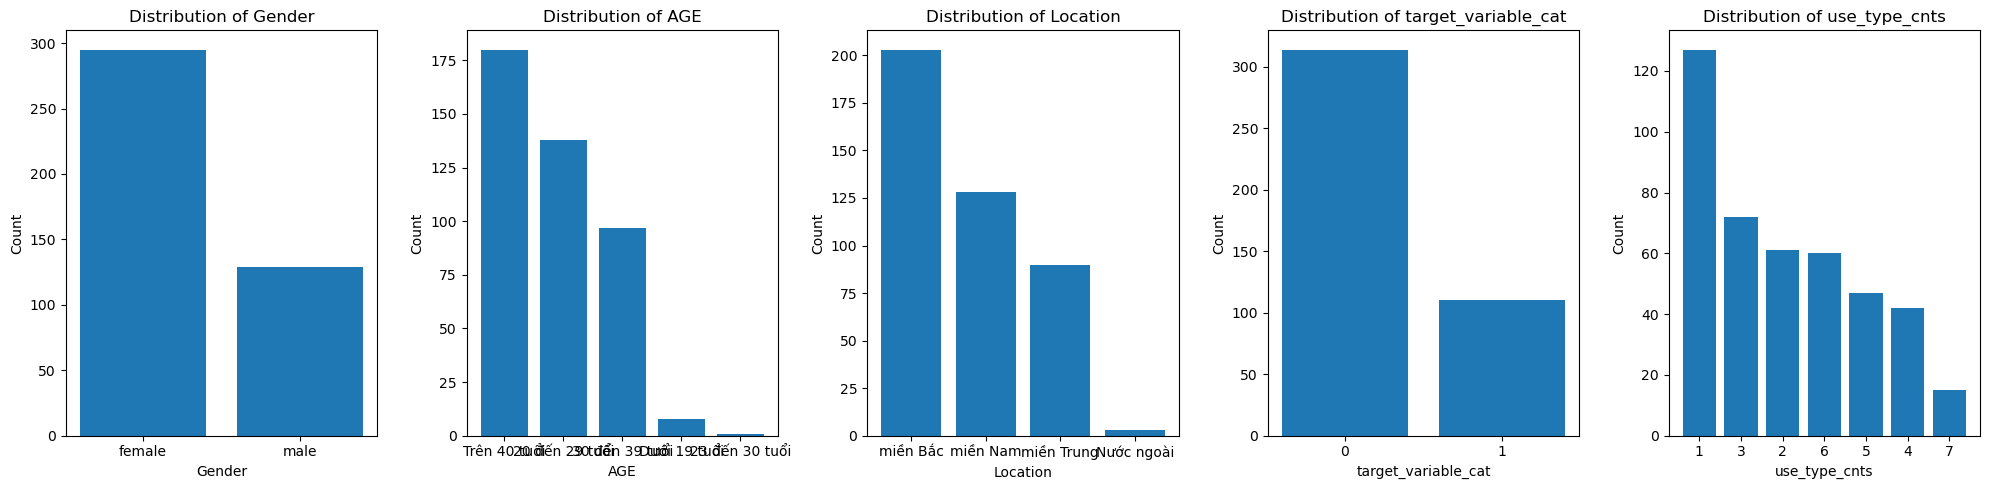

In [166]:
import matplotlib.pyplot as plt

# Categorical variables to plot
categorical_variables = ['Gender', 'AGE', 'Location', 'target_variable_cat','use_type_cnts']

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))

# Loop through the categorical variables and create a bar plot for each
for ax, variable in zip(axes, categorical_variables):
    # Calculate the counts of each category
    counts = df_survey_cleaned[variable].value_counts()
    # Plot the bar plot
    ax.bar(counts.index.astype(str), counts.values)
    # Set the title and labels
    ax.set_title(f'Distribution of {variable}')
    ax.set_xlabel(variable)
    ax.set_ylabel('Count')
    # Optionally, set the x-tick labels to be more descriptive based on your data
    # ax.set_xticklabels(['Label1', 'Label2'], rotation=45) # Customize as needed

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Categorical variables to plot
categorical_variables = ['Gender', 'AGE', 'Location', 'target_variable_cat']

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

# Loop through the categorical variables and create a bar plot for each
for ax, variable in zip(axes, categorical_variables):
    # Calculate the counts of each category
    counts = df_survey_cleaned[variable].value_counts()
    # Plot the bar plot
    ax.bar(counts.index.astype(str), counts.values)
    # Set the title and labels
    ax.set_title(f'Distribution of {variable}')
    ax.set_xlabel(variable)
    ax.set_ylabel('Count')
    # Optionally, set the x-tick labels to be more descriptive based on your data
    # ax.set_xticklabels(['Label1', 'Label2'], rotation=45) # Customize as needed

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
#sns.histplot(data=df_survey, x='target_variable_num')

In [ ]:
 
columns = ['PU', 'PE', 'PEOU', 'AT', 'BI', 'SOI', 'SEI', 'PPV', 'HM']

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))

# Flatten the array of axes for easy iteration
axes = axes.flatten()

# Loop through the columns and create a histogram for each
for i, column in enumerate(columns):
    axes[i].hist(df_survey_cleaned[column], bins=10, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# If there are any subplots without data (since we have 9 columns and 16 subplots), hide them
for j in range(len(columns), len(axes)):
    axes[j].axis('off')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:


# Define the numerical variables
numerical_variables = ['BI', 'PEOU', 'PU', 'PE', 'HM', 'SOI', 'SEI', 'PPV', 'AT']

# Create a 3x4 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through the numerical variables and create a histogram for each
for i, var in enumerate(numerical_variables):
    # Select the subplot
    ax = axes[i]
    
    # Create separate histograms for each gender within the same subplot
    df_survey_cleaned[df_survey_cleaned['Gender_num'] == 0][var].hist(ax=ax, alpha=0.5, label='Gender 0')
    df_survey_cleaned[df_survey_cleaned['Gender_num'] == 1][var].hist(ax=ax, alpha=0.5, label='Gender 1')
    
    # Set the title and labels
    ax.set_title(f'Histogram of {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')
    
    # Add a legend to distinguish between genders
    ax.legend()

# Remove any unused subplots (if the number of numerical variables is less than 12)
for i in range(len(numerical_variables), len(axes)):
    fig.delaxes(axes[i])

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot


In [ ]:
import matplotlib.pyplot as plt
 

columns = ['PE', 'SOI', 'SEI', 'HM', 'AT', 'PPV', 'PU', 'PEOU', 'BI']

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))

# Flatten the array of axes for easy iteration
axes_flat = axes.flatten()

# Loop through the specified columns and create a boxplot for each
for i, column in enumerate(columns):
    # Plot boxplot on ith subplot
    axes_flat[i].boxplot(df_survey_cleaned[column], patch_artist=True)
    axes_flat[i].set_title(f'Boxplot of {column}')
    axes_flat[i].set_xticklabels([column])

# If there are any subplots without data (since we have 12 columns and 16 subplots), hide them
for j in range(len(columns), len(axes_flat)):
    axes_flat[j].axis('off')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()
 

In [ ]:

# Specified numeric variables
numeric_variables = ['BI', 'PEOU', 'PU', 'AT', 'HM', 'PPV', 'SEI', 'SOI', 'PE','use_type_cnts']

 # Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))

# Flatten the array of axes for easy iteration
axes = axes.flatten()

# Define the font size for the axis labels
axis_label_font_size = 14 # You can adjust this value as needed

# Loop through the numeric variables and create a boxplot for each
for i, variable in enumerate(numeric_variables):
    # Prepare data for the boxplot
    data = [df_survey_cleaned[df_survey_cleaned['Gender_num'] == gender][variable].dropna() for gender in df_survey_cleaned['Gender_num'].unique()]
    # Plot the boxplot
    axes[i].boxplot(data, patch_artist=True)
    # Set the title and the x-tick labels to represent different genders
    axes[i].set_title(f'Boxplot of {variable} by Gender')
    axes[i].set_xticklabels(df_survey_cleaned['Gender_num'].unique(), rotation=45, fontsize=axis_label_font_size)  # Increase x-axis label font size
    axes[i].set_ylabel(variable, fontsize=axis_label_font_size)  # Increase y-axis label font size

# If there are any subplots without data (since we have 9 numeric variables and 12 subplots), hide them
for j in range(len(numeric_variables), len(axes)):
    axes[j].axis('off')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

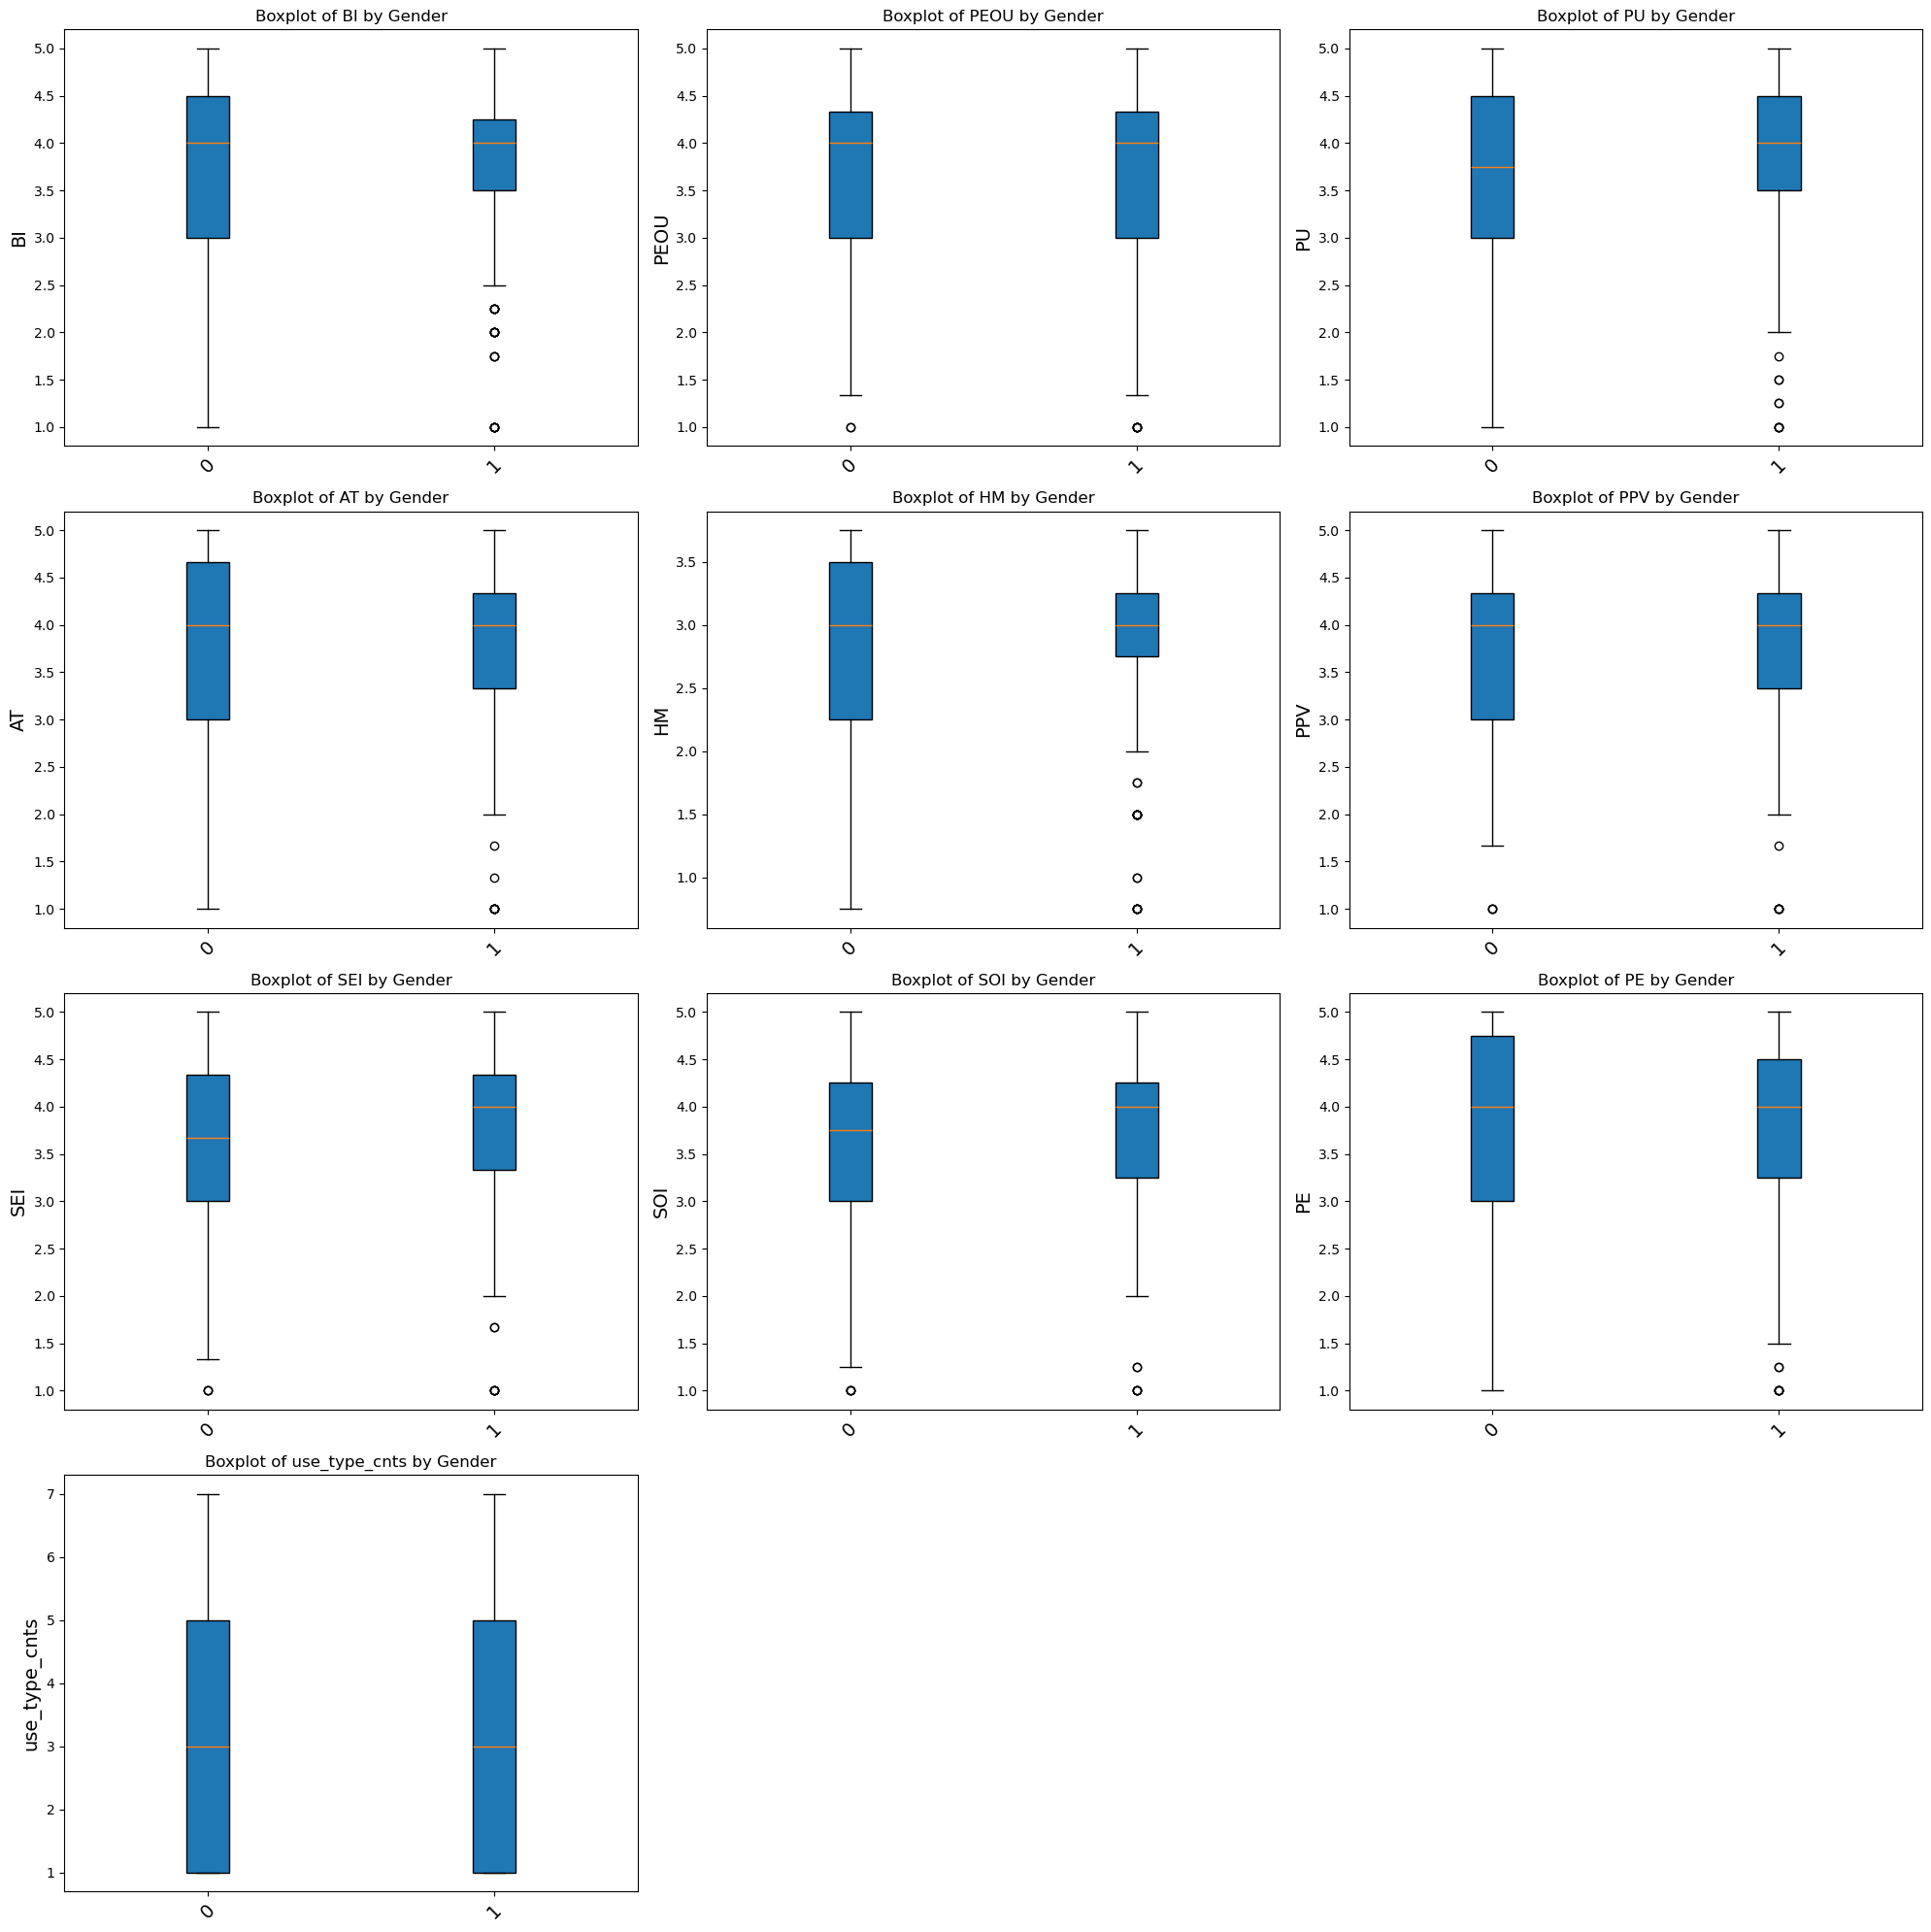

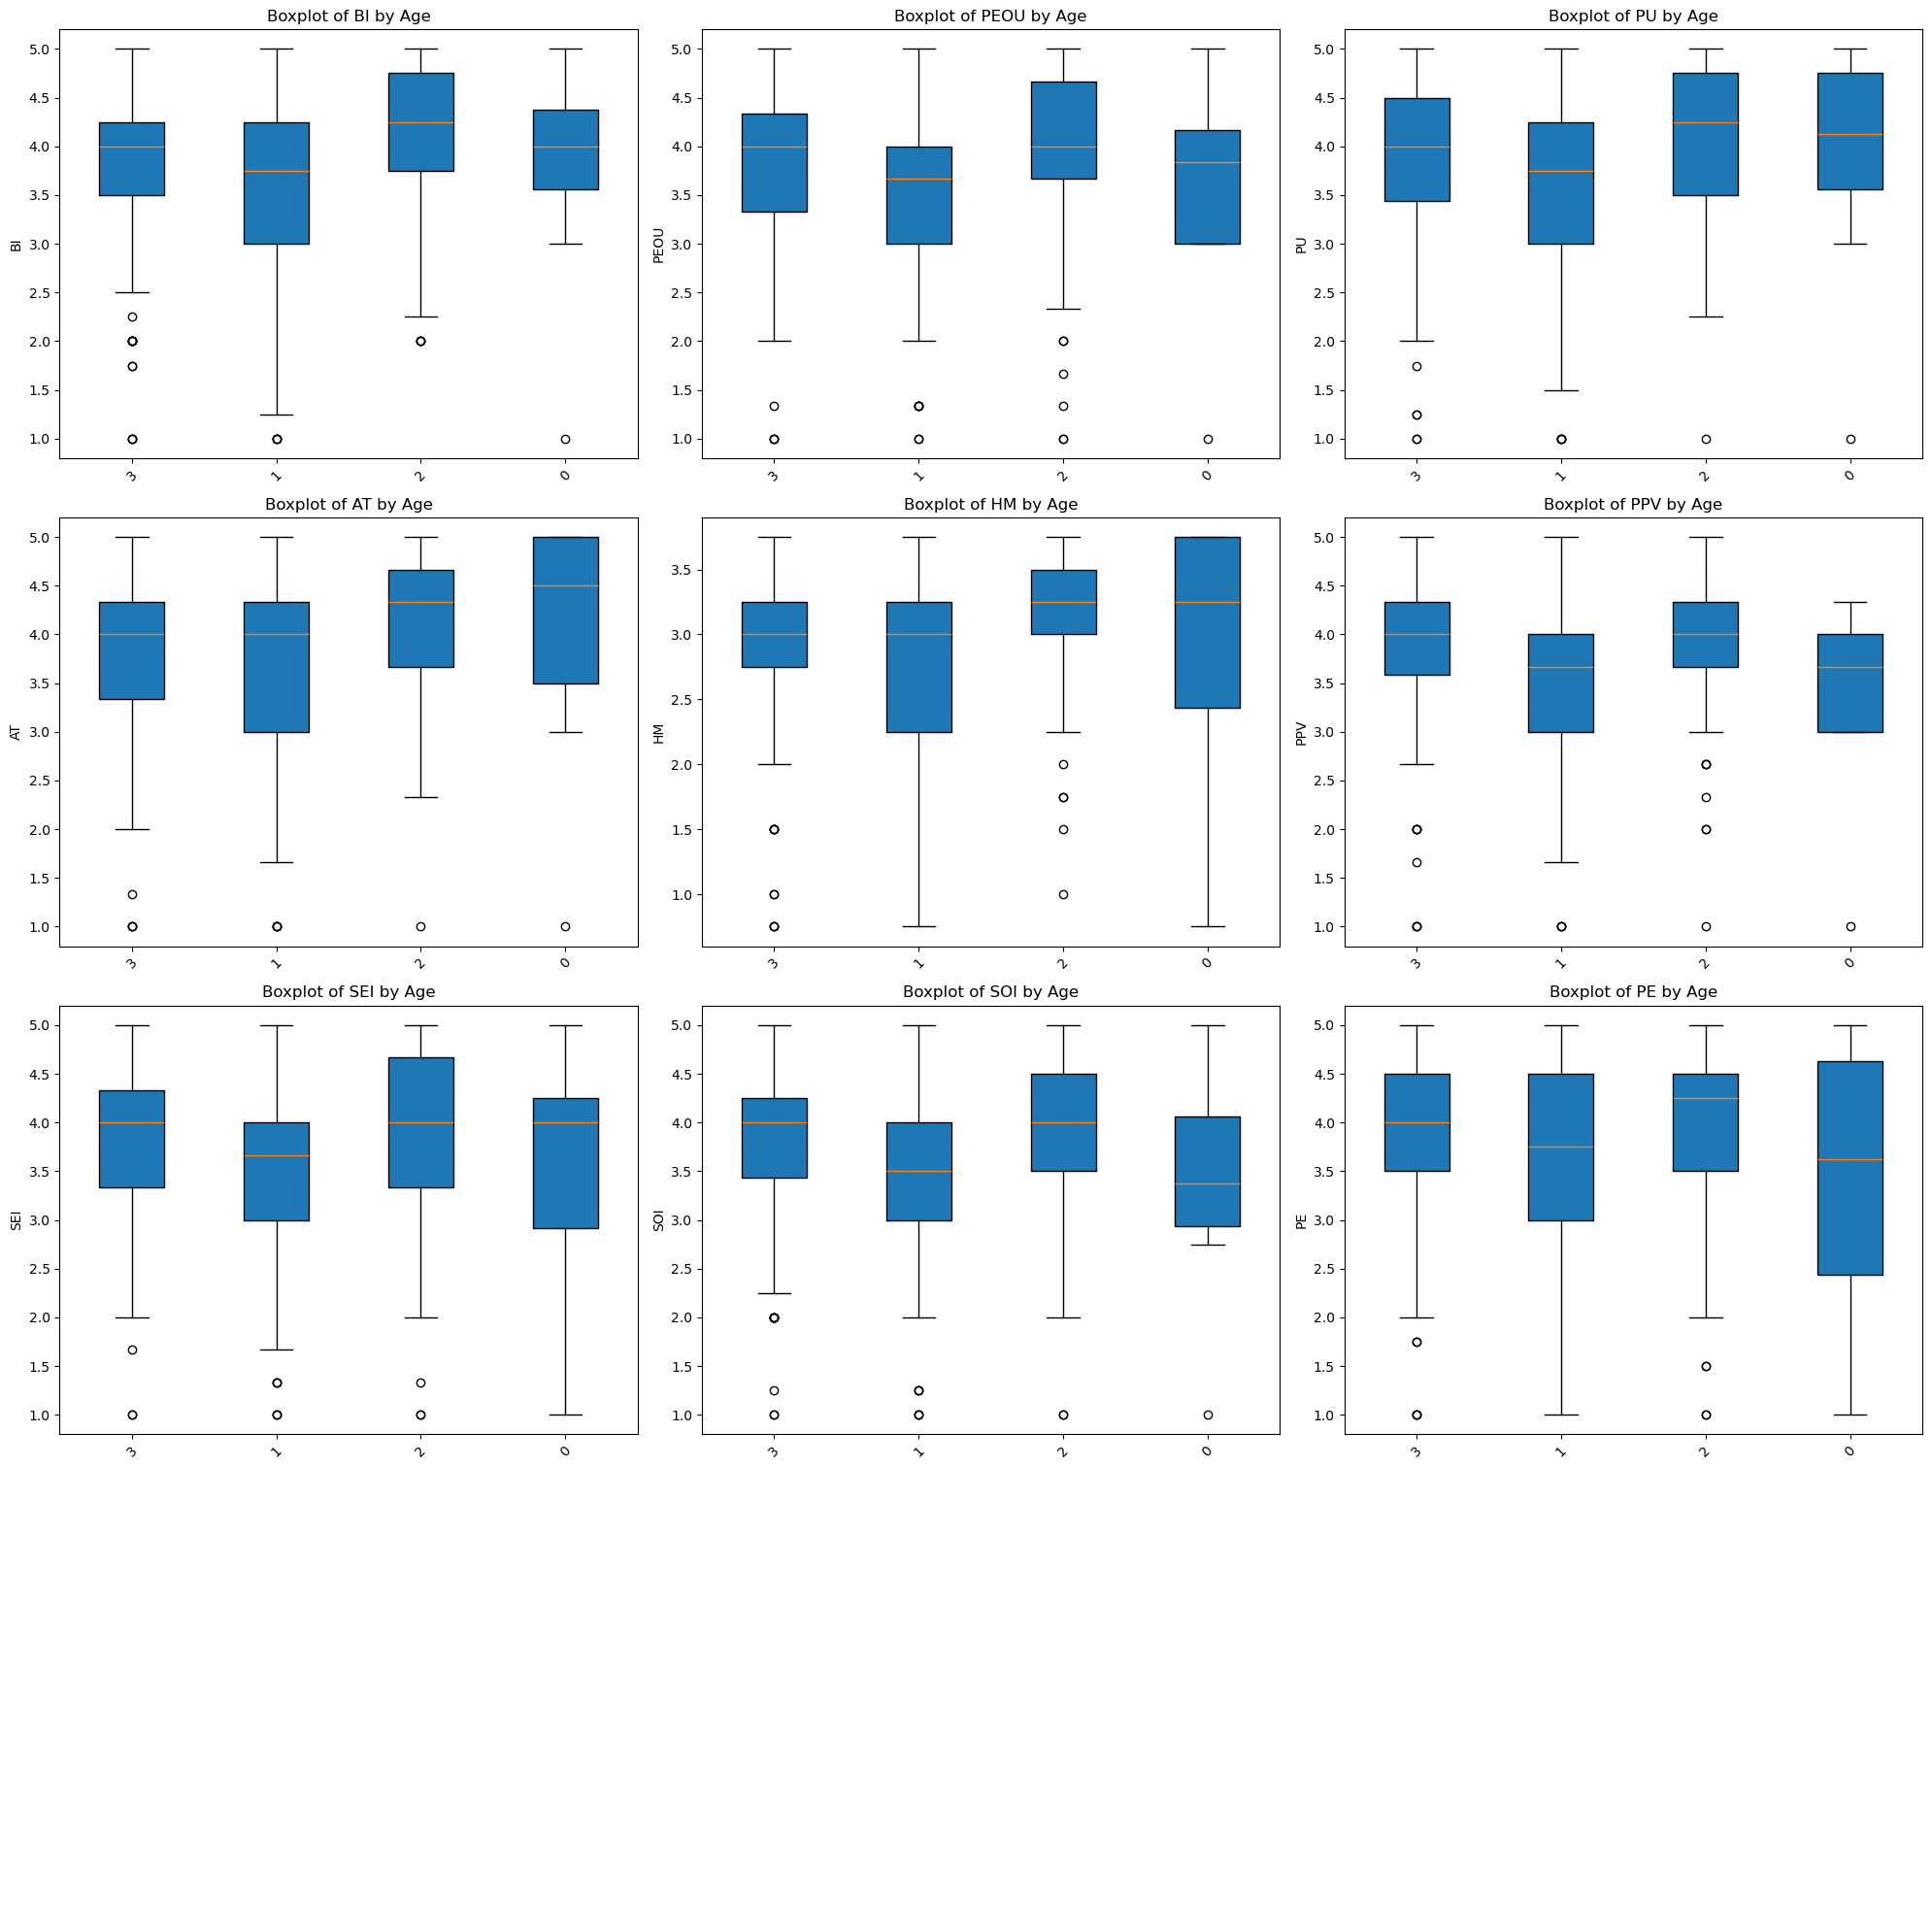

In [137]:
# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))

# Flatten the array of axes for easy iteration
axes = axes.flatten()

# Define the font size for the axis labels
axis_label_font_size = 14  # You can adjust this value as needed

# Loop through the numeric variables and create a boxplot for each
for i, variable in enumerate(numeric_variables):
    # Prepare data for the boxplot
    data = [df_survey_cleaned[df_survey_cleaned['Gender_num'] == gender][variable].dropna() for gender in df_survey_cleaned['Gender_num'].unique()]
    # Plot the boxplot
    axes[i].boxplot(data, patch_artist=True)
    # Set the title and the x-tick labels to represent different genders
    axes[i].set_title(f'Boxplot of {variable} by Gender')
    axes[i].set_xticklabels(df_survey_cleaned['Gender_num'].unique(), rotation=45, fontsize=axis_label_font_size)  # Increase x-axis label font size
    axes[i].set_ylabel(variable, fontsize=axis_label_font_size)  # Increase y-axis label font size

# If there are any subplots without data (since we have 9 numeric variables and 12 subplots), hide them
for j in range(len(numeric_variables), len(axes)):
    axes[j].axis('off')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show() 
# Specified numeric variables
numeric_variables = ['BI', 'PEOU', 'PU', 'AT', 'HM', 'PPV', 'SEI', 'SOI', 'PE']

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))

# Flatten the array of axes for easy iteration
axes = axes.flatten()

# Loop through the numeric variables and create a boxplot for each
for i, variable in enumerate(numeric_variables):
    # Prepare data for the boxplot
    data = [df_survey_cleaned[df_survey_cleaned['AGE_num'] == AGE][variable].dropna() for AGE in df_survey_cleaned['AGE_num'].unique()]
    # Plot the boxplot
    axes[i].boxplot(data, patch_artist=True)
    # Set the title and the x-tick labels to represent different genders
    axes[i].set_title(f'Boxplot of {variable} by Age')
    axes[i].set_xticklabels(df_survey_cleaned['AGE_num'].unique(), rotation=45)
    axes[i].set_ylabel(variable)

# If there are any subplots without data (since we have 9 numeric variables and 16 subplots), hide them
for j in range(len(numeric_variables), len(axes)):
    axes[j].axis('off')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

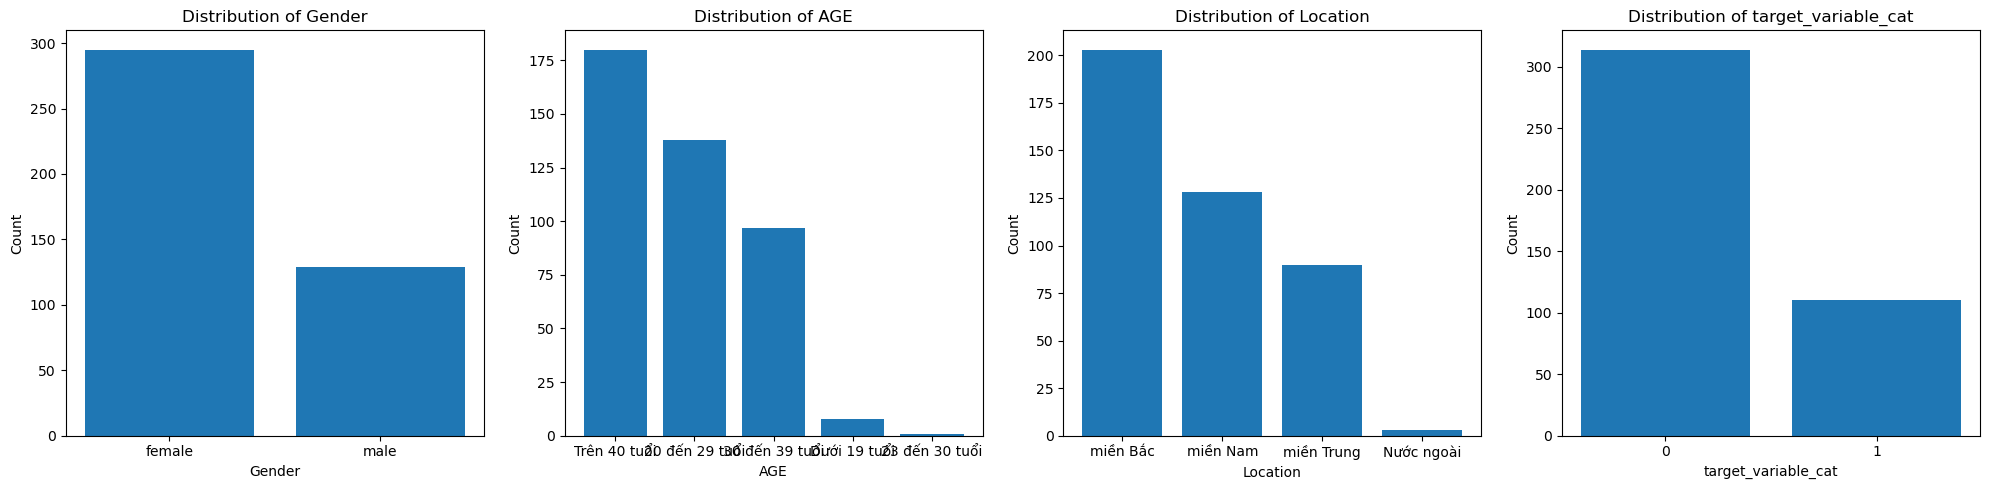

In [138]:
import matplotlib.pyplot as plt

# Categorical variables to plot
categorical_variables = ['Gender', 'AGE', 'Location', 'target_variable_cat']

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

# Loop through the categorical variables and create a bar plot for each
for ax, variable in zip(axes, categorical_variables):
    # Calculate the counts of each category
    counts = df_survey_cleaned[variable].value_counts()
    # Plot the bar plot
    ax.bar(counts.index.astype(str), counts.values)
    # Set the title and labels
    ax.set_title(f'Distribution of {variable}')
    ax.set_xlabel(variable)
    ax.set_ylabel('Count')
    # Optionally, set the x-tick labels to be more descriptive based on your data
    # ax.set_xticklabels(['Label1', 'Label2'], rotation=45) # Customize as needed

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

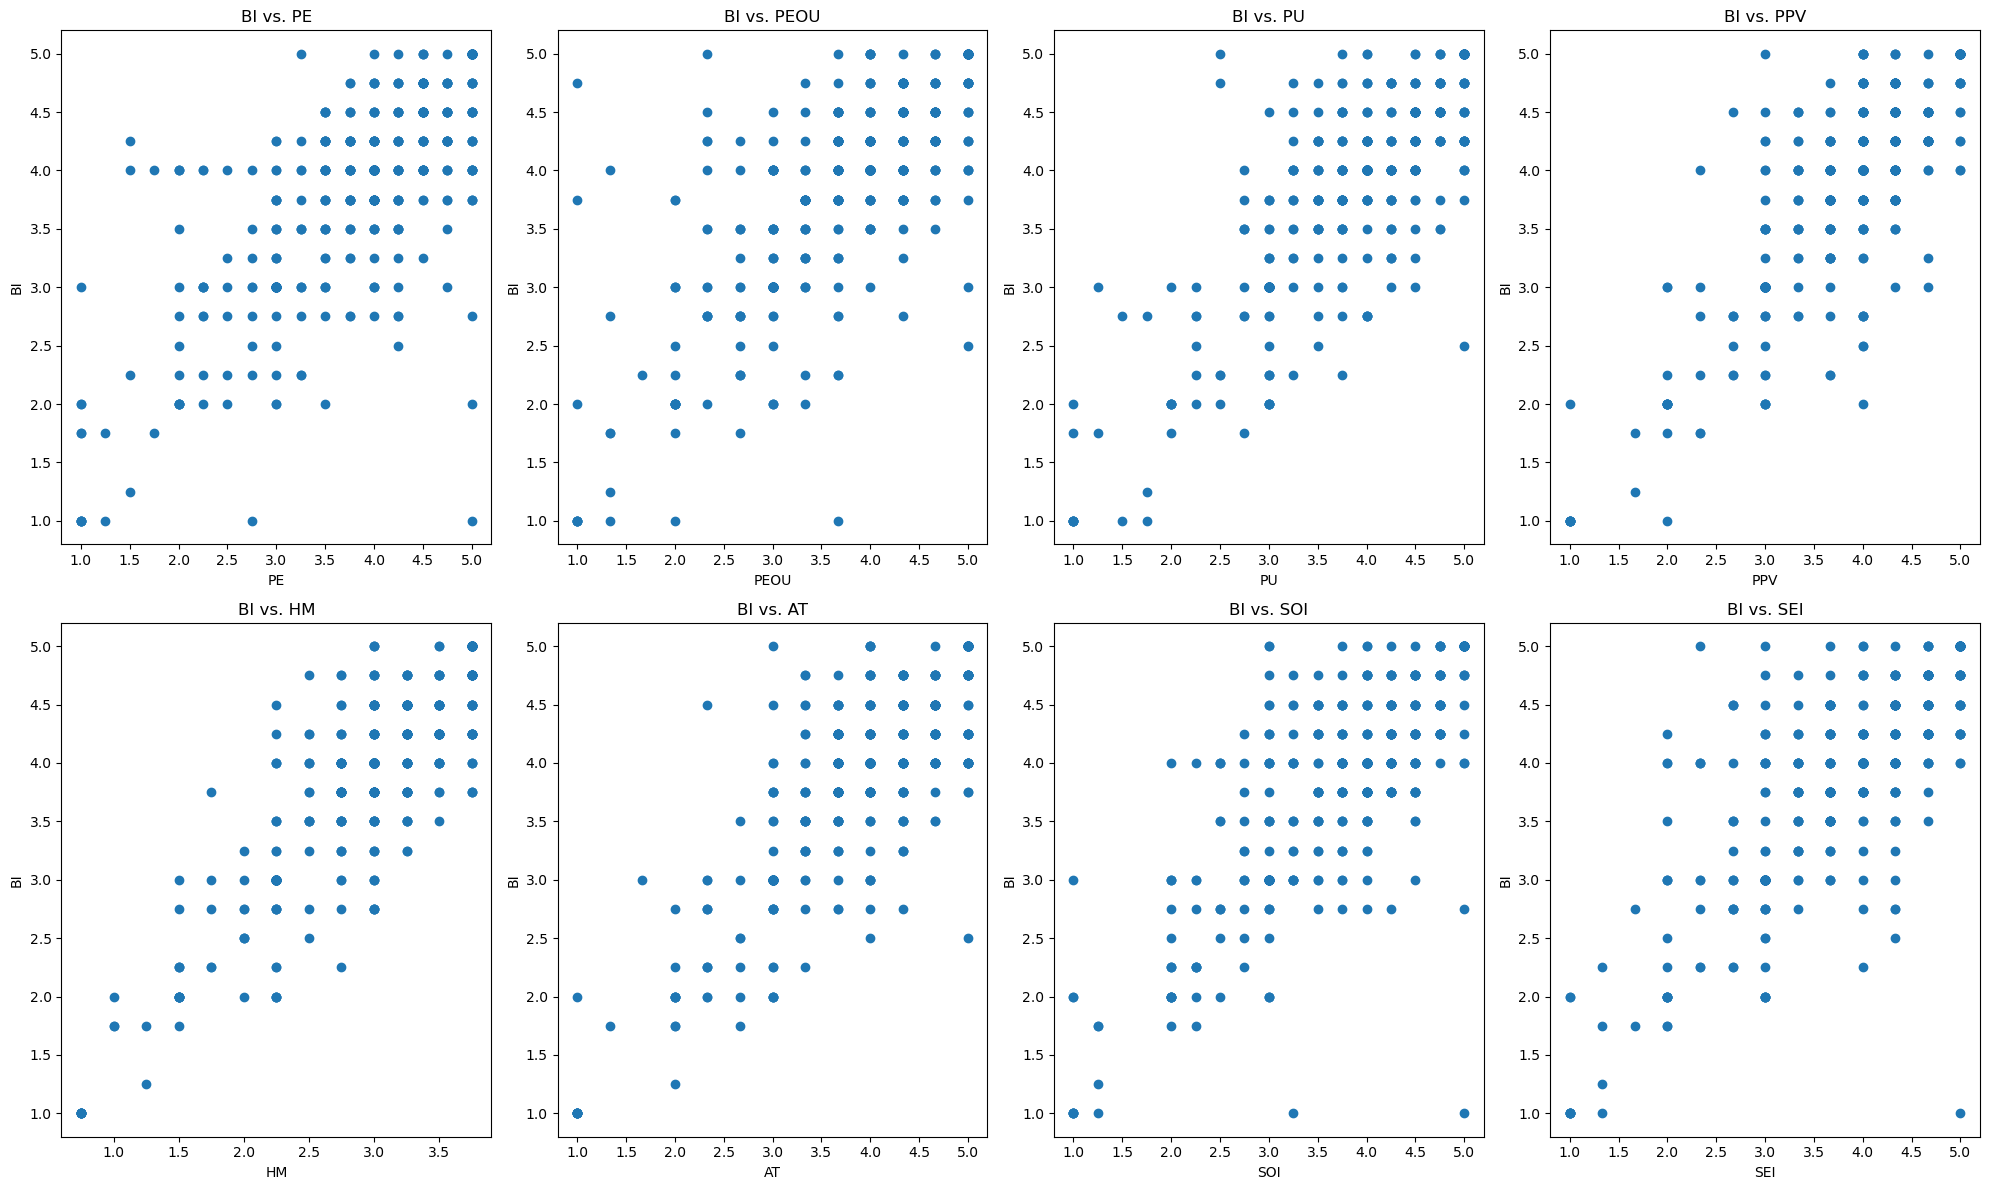

In [139]:
 
# Numerical variables to plot against BI
variables_to_plot = ['PE', 'PEOU', 'PU', 'PPV', 'HM', 'AT', 'SOI', 'SEI']

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 12))

# Flatten the array of axes for easy iteration
axes = axes.flatten()

# Loop through the variables and create a scatter plot for each
for i, variable in enumerate(variables_to_plot):
    # Select the subplot
    ax = axes[i]
    
    # Create the scatter plot
    ax.scatter(df_survey_cleaned[variable], df_survey_cleaned['BI'])
    
    # Set the title and labels
    ax.set_title(f'BI vs. {variable}')
    ax.set_xlabel(variable)
    ax.set_ylabel('BI')

# If there are any subplots without data (since we have 8 variables and 12 subplots), hide them
for j in range(len(variables_to_plot), len(axes)):
    axes[j].axis('off')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

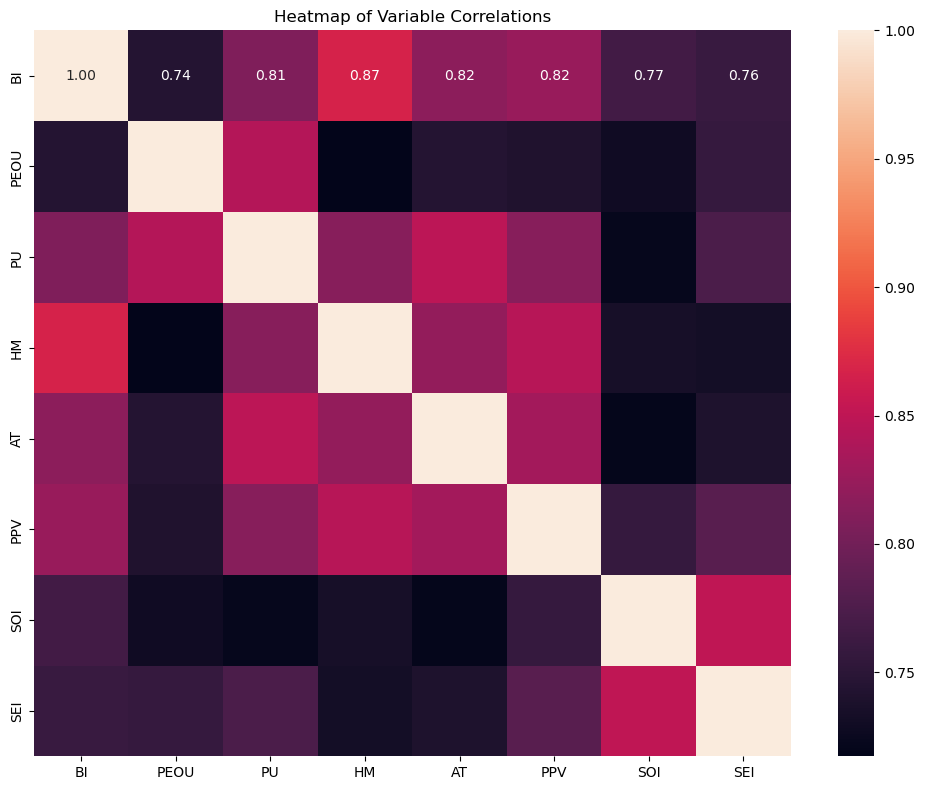

In [140]:
# List of variables for the heatmap
variables = ['BI', 'PEOU', 'PU', 'HM', 'AT', 'PPV', 'SOI', 'SEI']

# Compute the correlation matrix for the specified variables
corr_matrix = df_survey_cleaned[variables].corr()

# Create the heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cbar=True)

# Set the title and adjust the plot display
plt.title('Heatmap of Variable Correlations')
plt.tight_layout()

# Show the plot
plt.show()

In [141]:
df_survey_cleaned['BI'].describe()

count    424.000000
mean       3.797759
std        0.873460
min        1.000000
25%        3.250000
50%        4.000000
75%        4.500000
max        5.000000
Name: BI, dtype: float64

In [142]:
descriptive_stats = df_survey_cleaned.groupby(['AGE_num'])['BI'].describe()
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
AGE_num,,,,,,,,
0,8.0,3.718750,1.256679,1.0,3.5625,4.00,4.375,5.0
1,139.0,3.600719,0.967179,1.0,3.0000,3.75,4.250,5.0
2,97.0,4.056701,0.776029,2.0,3.7500,4.25,4.750,5.0
3,180.0,3.813889,0.793709,1.0,3.5000,4.00,4.250,5.0


In [143]:
descriptive_stats = df_survey_cleaned.groupby(['Gender_num'])['BI'].describe()
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Gender_num,,,,,,,,
0,129.0,3.744186,0.989429,1.0,3.0,4.0,4.50,5.0
1,295.0,3.821186,0.818328,1.0,3.5,4.0,4.25,5.0


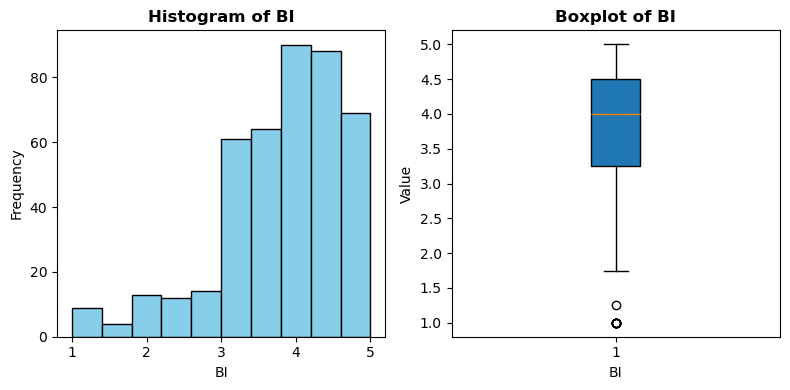

In [144]:
import matplotlib.pyplot as plt

# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

# Create a histogram on the first subplot
axes[0].hist(df_survey_cleaned['BI'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of BI', fontweight='bold')
axes[0].set_xlabel('BI')
axes[0].set_ylabel('Frequency')

# Create a boxplot on the second subplot
axes[1].boxplot(df_survey_cleaned['BI'], vert=True, patch_artist=True)
axes[1].set_title('Boxplot of BI', fontweight='bold')
axes[1].set_xlabel('BI')
axes[1].set_ylabel('Value')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [145]:
df_survey_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 424 entries, 0 to 522
Data columns (total 98 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     424 non-null    object 
 1   AR_Knowledgeable              424 non-null    float64
 2   familiar_with_technology      424 non-null    float64
 3   use_AR_everyday               424 non-null    float64
 4   use_in_all_aspects            424 non-null    object 
 5   Virtual_shopping_environment  424 non-null    float64
 6   Virtual_tour                  424 non-null    float64
 7   Visualize_model               424 non-null    float64
 8   Emulation                     424 non-null    float64
 9   PE1                           424 non-null    float64
 10  PE2                           424 non-null    float64
 11  PE3                           424 non-null    float64
 12  PE4                           424 non-null    float64
 13  SOI1      

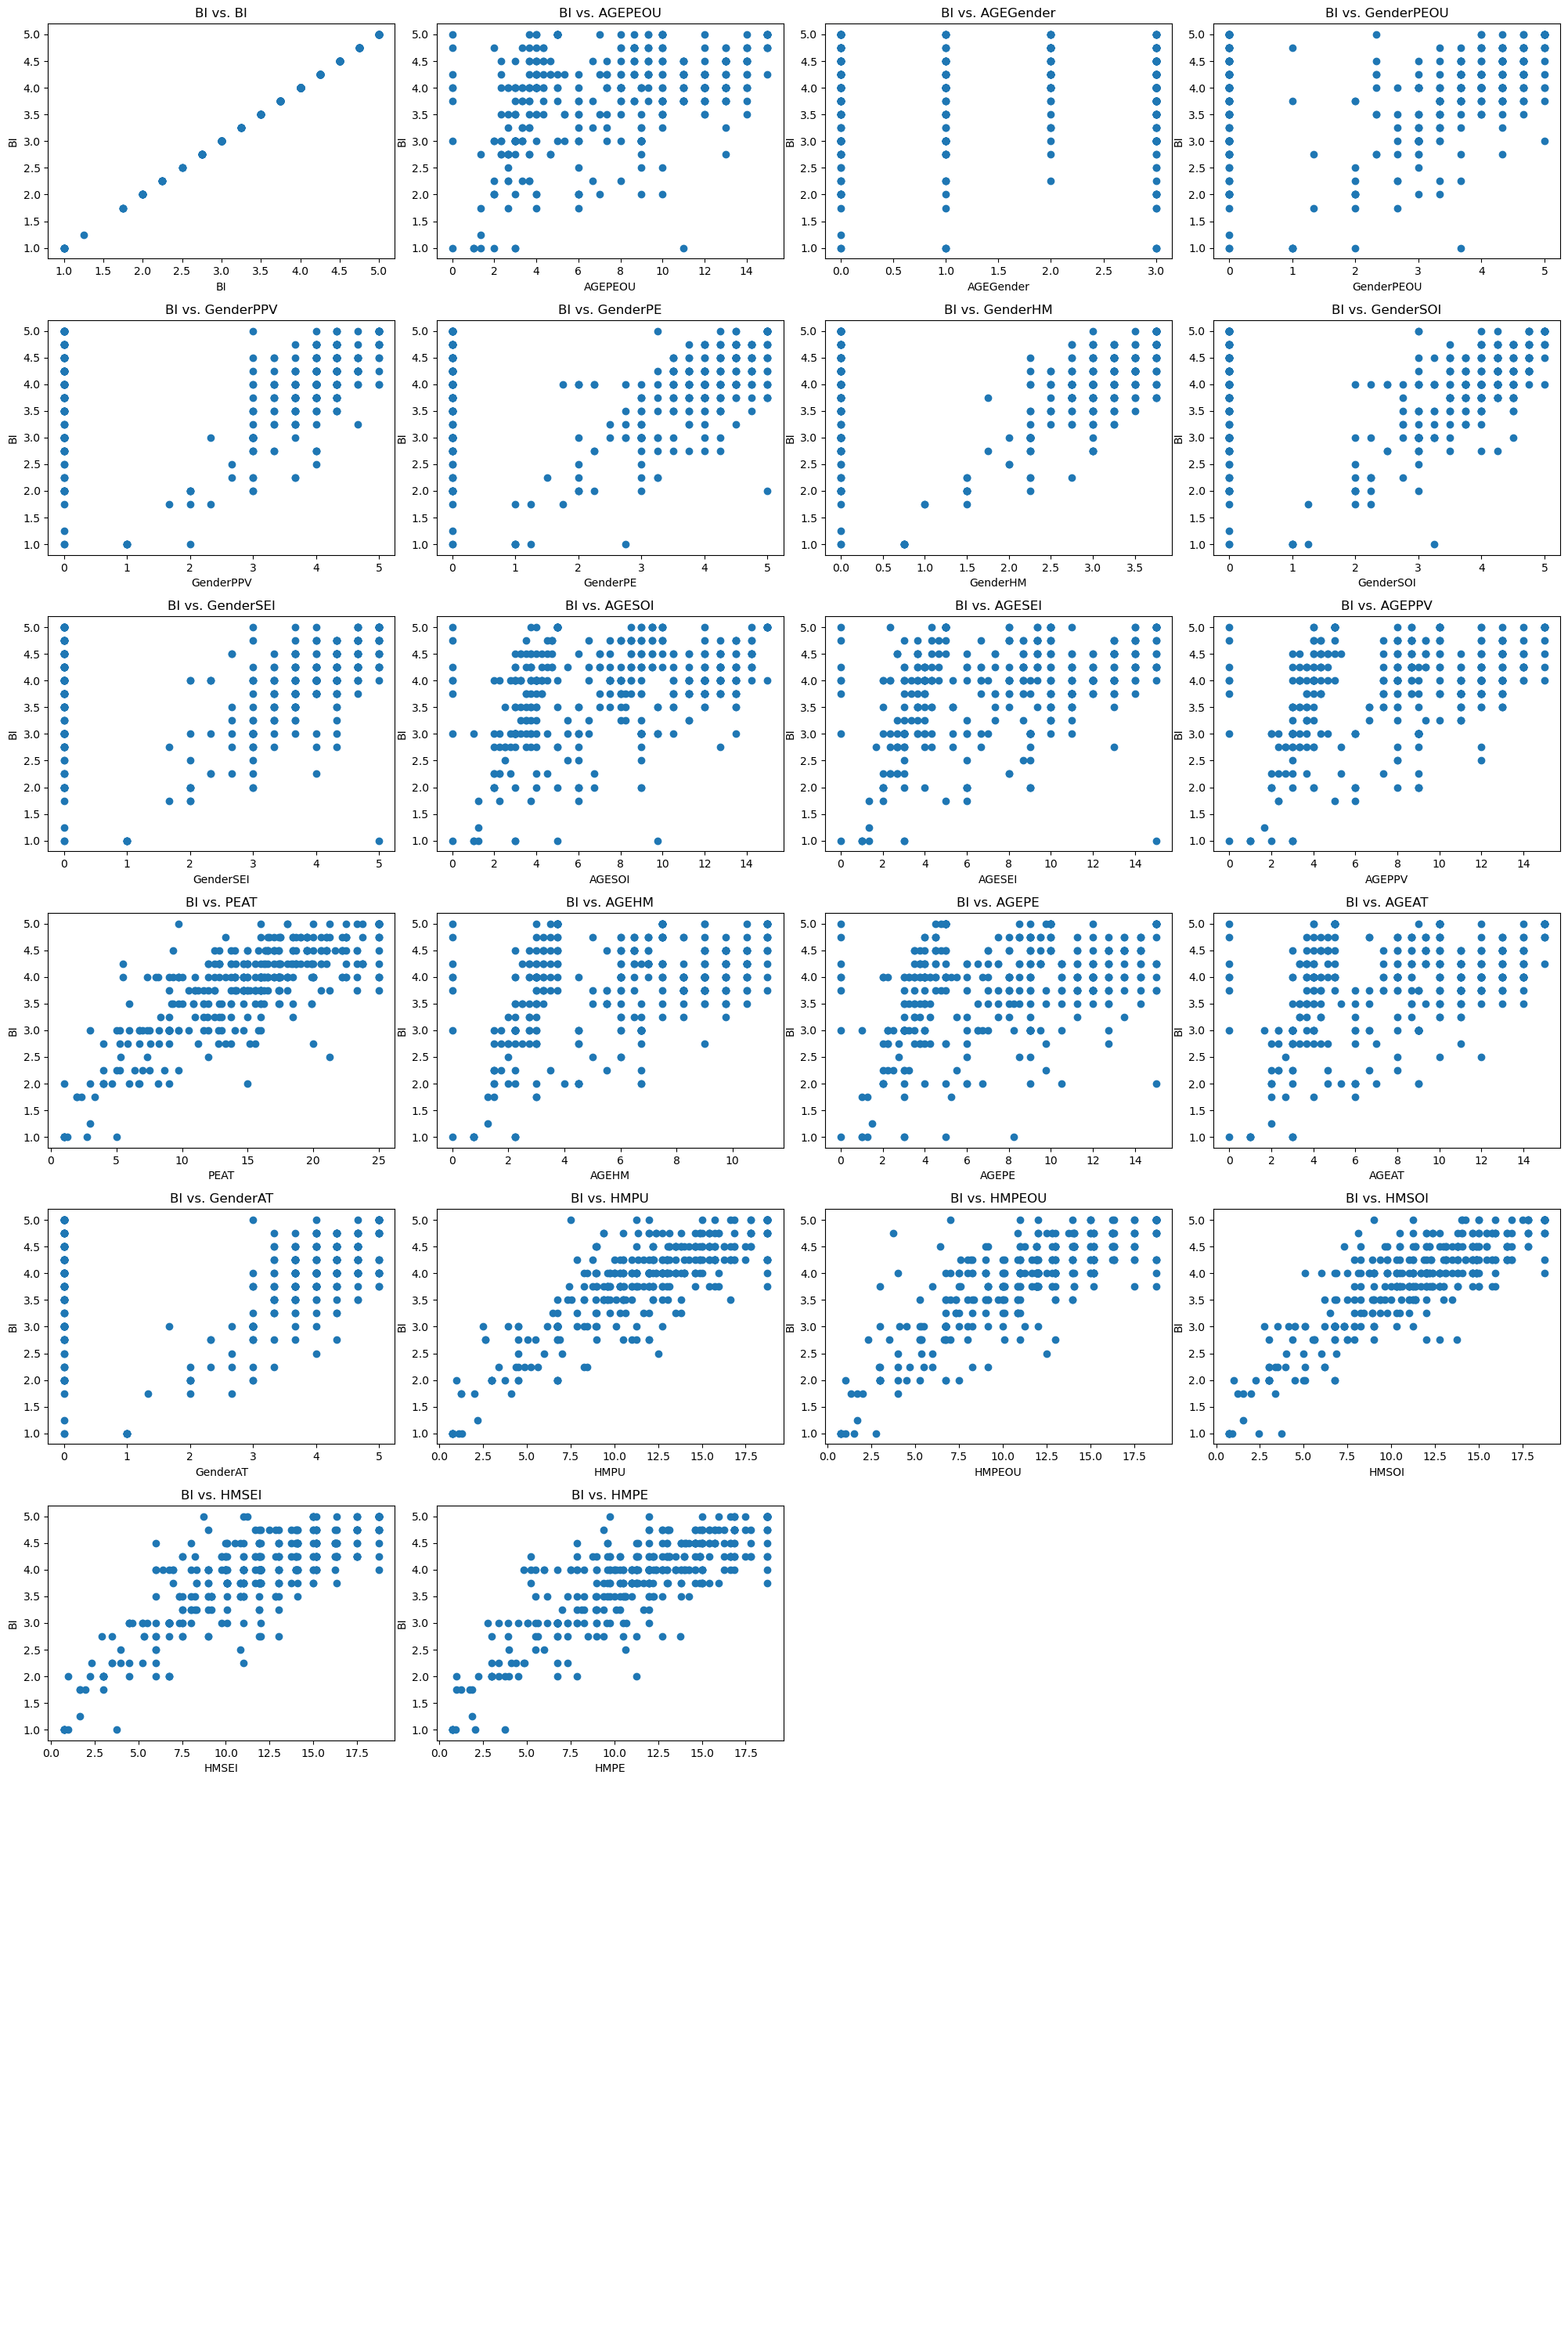

In [146]:
 
# Numerical variables to plot against BI
variables_to_plot =  ['BI', 'AGEPEOU','AGEGender','GenderPEOU','GenderPPV','GenderPE',
           'GenderHM','GenderSOI','GenderSEI','AGESOI','AGESEI','AGEPPV','PEAT','AGEHM','AGEPE','AGEAT','GenderAT','HMPU','HMPEOU','HMSOI','HMSEI','HMPE']

 

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=8, ncols=4, figsize=(20, 30))

# Flatten the array of axes for easy iteration
axes = axes.flatten()

# Loop through the variables and create a scatter plot for each
for i, variable in enumerate(variables_to_plot):
    # Select the subplot
    ax = axes[i]
    
    # Create the scatter plot
    ax.scatter(df_survey_cleaned[variable], df_survey_cleaned['BI'])
    
    # Set the title and labels
    ax.set_title(f'BI vs. {variable}')
    ax.set_xlabel(variable)
    ax.set_ylabel('BI')

# If there are any subplots without data (since we have 8 variables and 12 subplots), hide them
for j in range(len(variables_to_plot), len(axes)):
    axes[j].axis('off')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

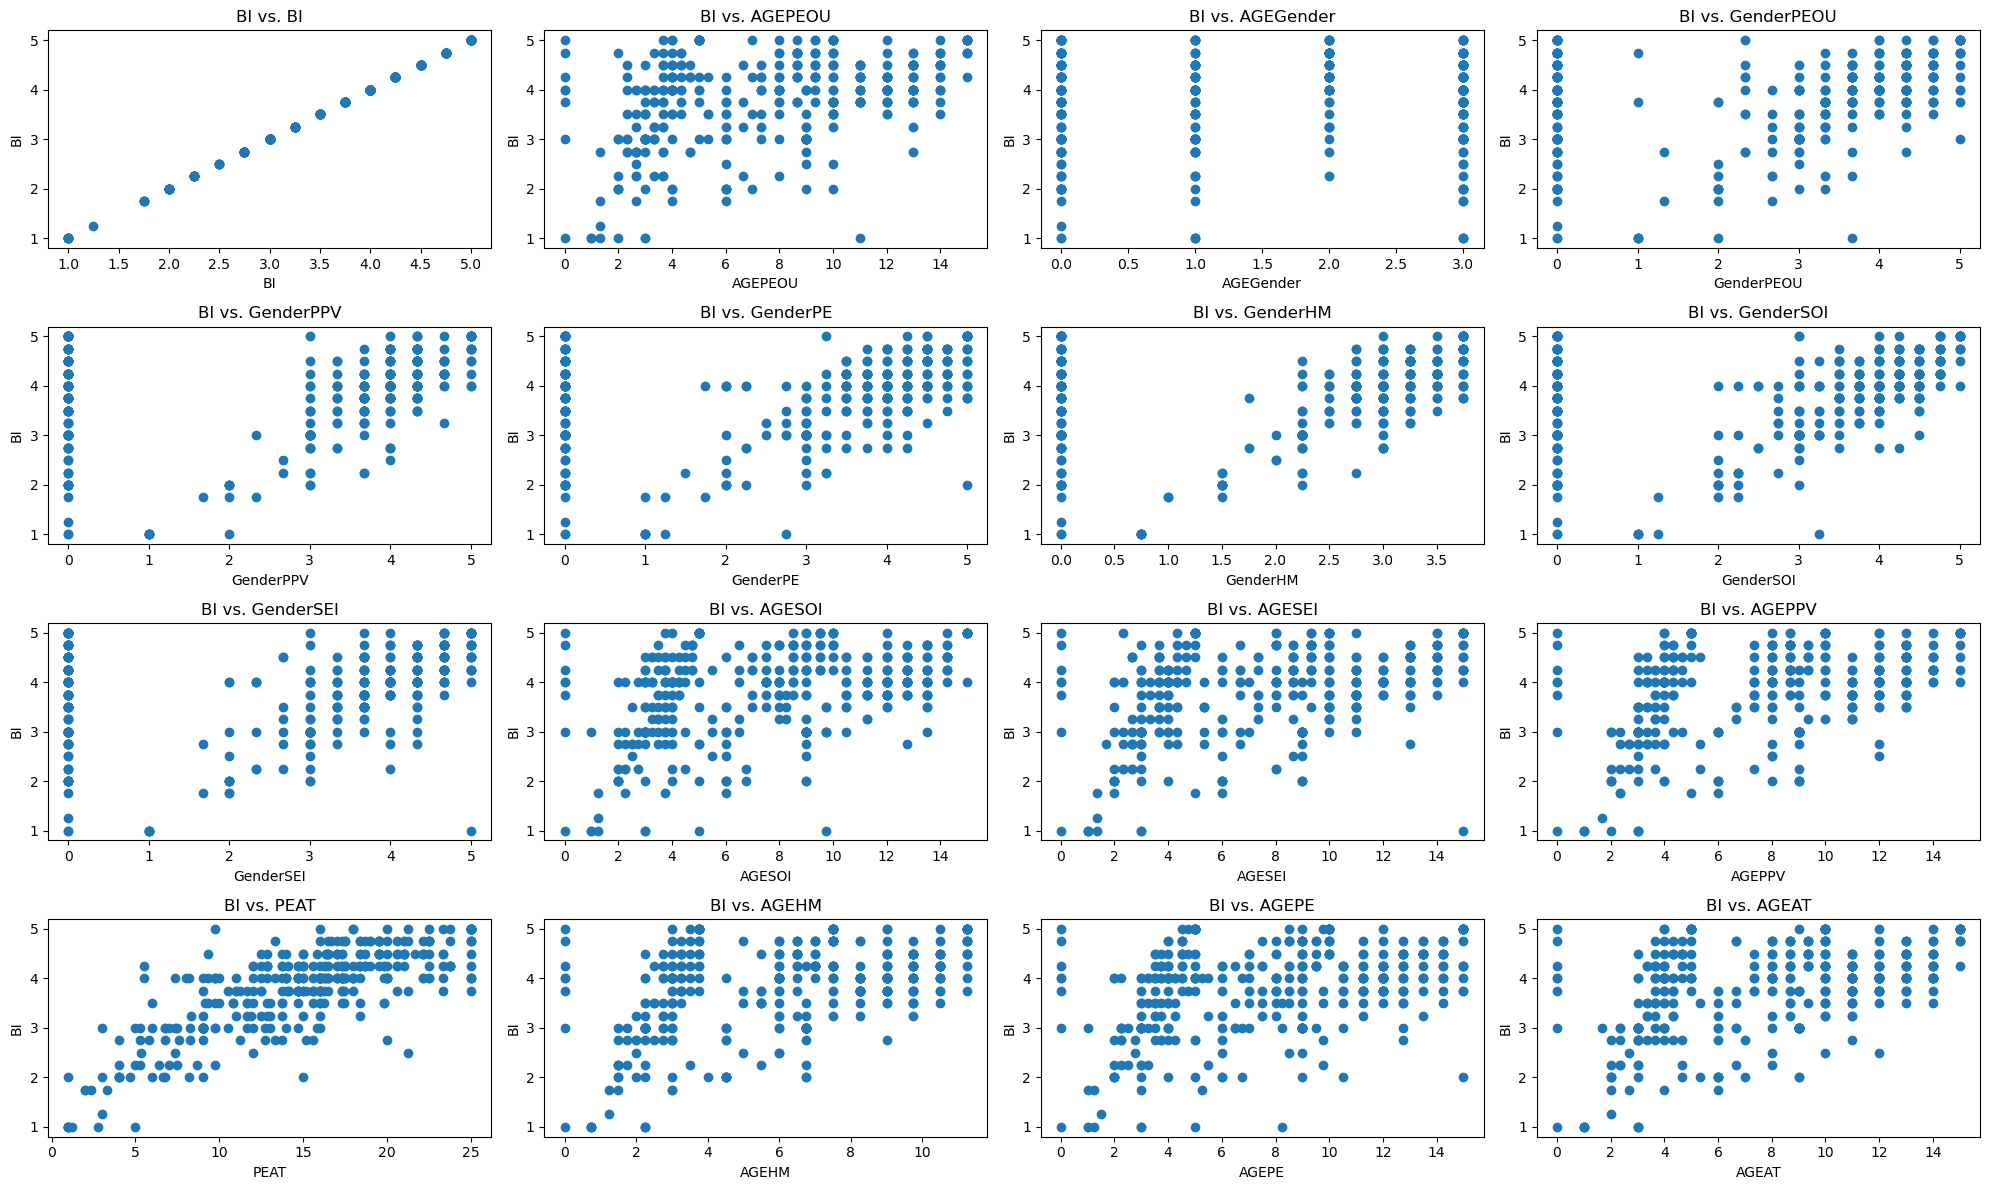

In [147]:
 
# Numerical variables to plot against BI
variables_to_plot =  ['BI', 'AGEPEOU','AGEGender','GenderPEOU','GenderPPV','GenderPE',
           'GenderHM','GenderSOI','GenderSEI','AGESOI','AGESEI','AGEPPV','PEAT','AGEHM','AGEPE','AGEAT'] 
# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 12))

# Flatten the array of axes for easy iteration
axes = axes.flatten()

# Loop through the variables and create a scatter plot for each
for i, variable in enumerate(variables_to_plot):
    # Select the subplot
    ax = axes[i]
    
    # Create the scatter plot
    ax.scatter(df_survey_cleaned[variable], df_survey_cleaned['BI'])
    
    # Set the title and labels
    ax.set_title(f'BI vs. {variable}')
    ax.set_xlabel(variable)
    ax.set_ylabel('BI')

# If there are any subplots without data (since we have 8 variables and 12 subplots), hide them
for j in range(len(variables_to_plot), len(axes)):
    axes[j].axis('off')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

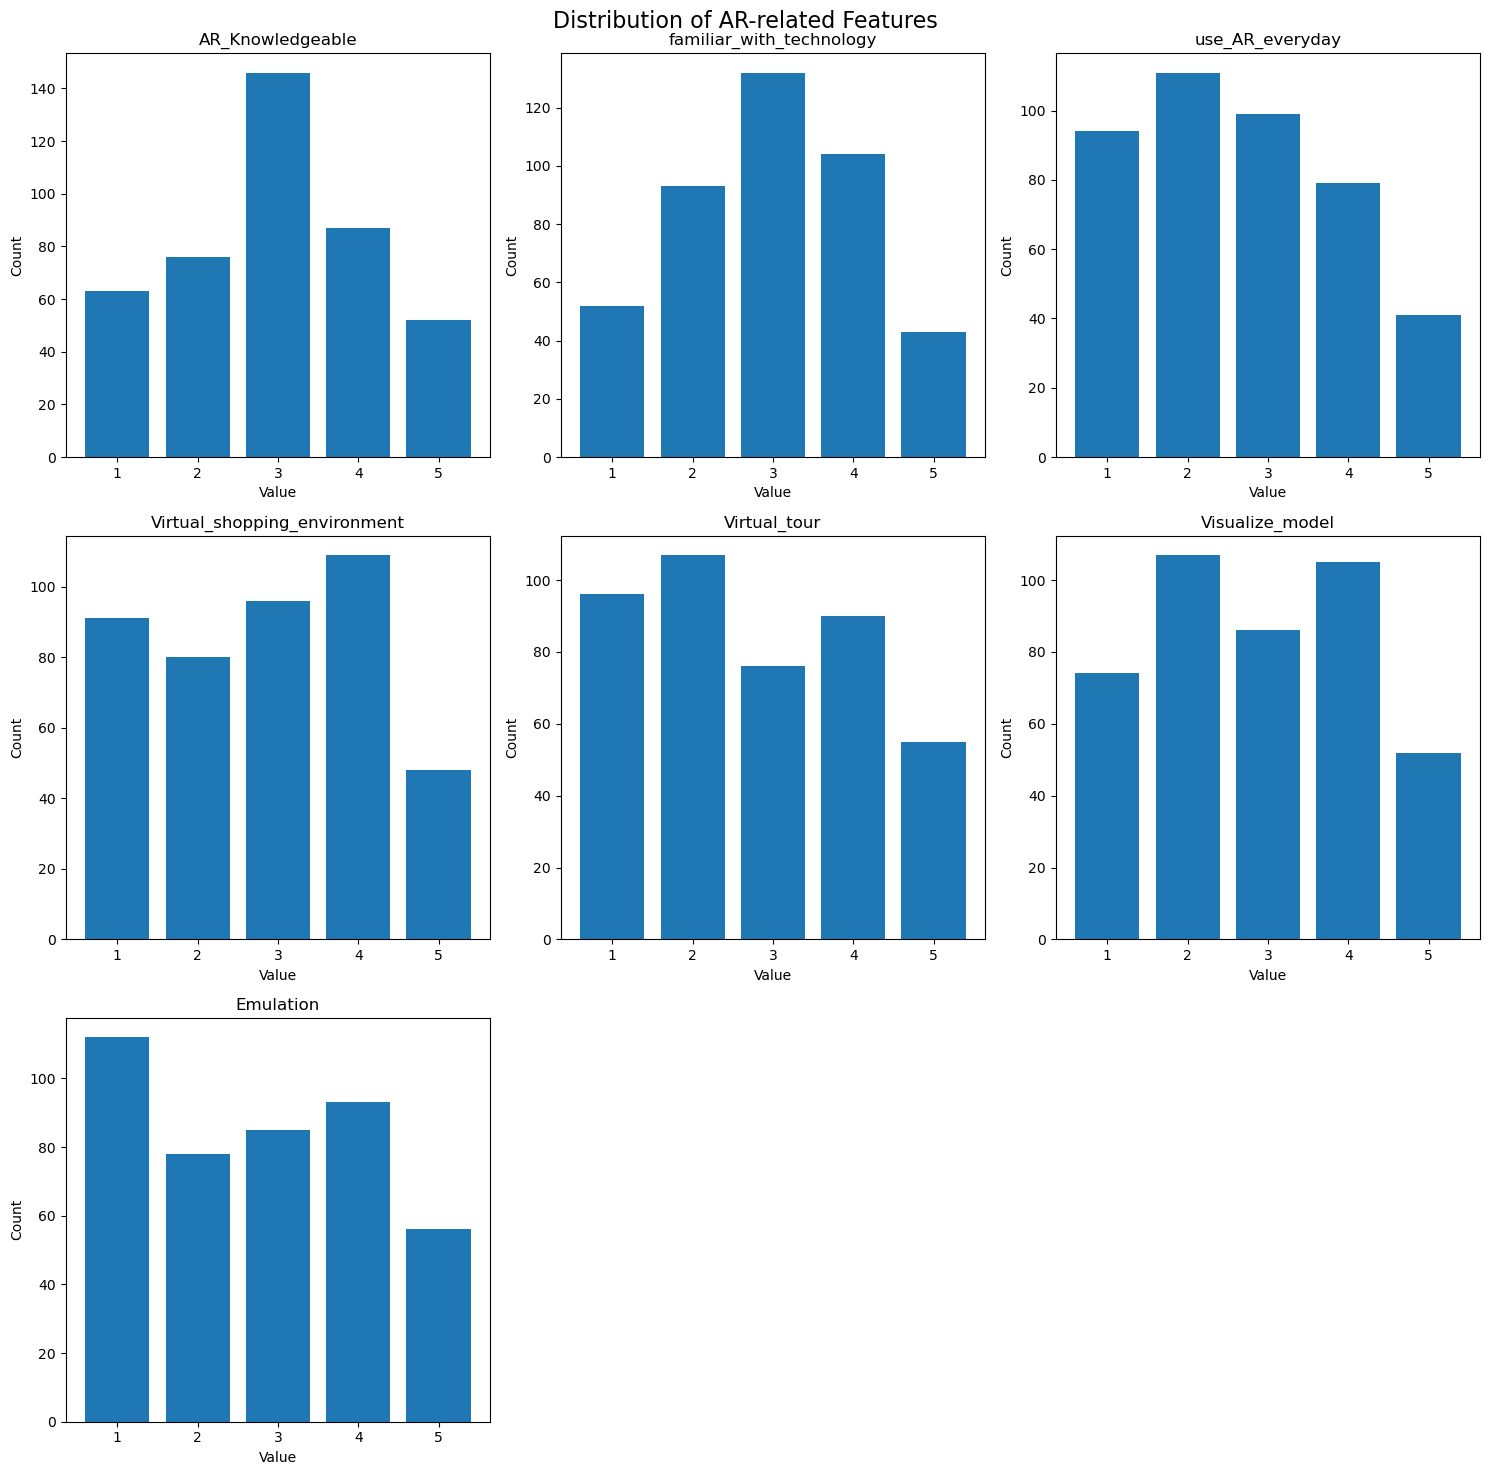

In [148]:
import matplotlib.pyplot as plt
import numpy as np

# List of features to plot
features = ['AR_Knowledgeable', 'familiar_with_technology', 'use_AR_everyday', 
            'Virtual_shopping_environment', 'Virtual_tour', 'Visualize_model', 'Emulation']

# Set up the plot
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Distribution of AR-related Features', fontsize=16)

# Flatten the axs array for easier iteration
axs = axs.flatten()

# Color for all bars
bar_color = '#1f77b4'  # A shade of blue

# Create a bar plot for each feature
for i, feature in enumerate(features):
    # Skip 'use_in_all_aspects' as it's an object type
    if feature == 'use_in_all_aspects':
        continue
    
    # Get value counts and sort index
    value_counts = df_survey_cleaned[feature].value_counts().sort_index()
    
    # Create the bar plot
    axs[i].bar(value_counts.index, value_counts.values, color=bar_color)
    
    # Set title and labels
    axs[i].set_title(feature)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Count')
    
    # Rotate x-axis labels if there are many categories
    if len(value_counts) > 5:
        axs[i].set_xticklabels(value_counts.index, rotation=45, ha='right')

# Remove any unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

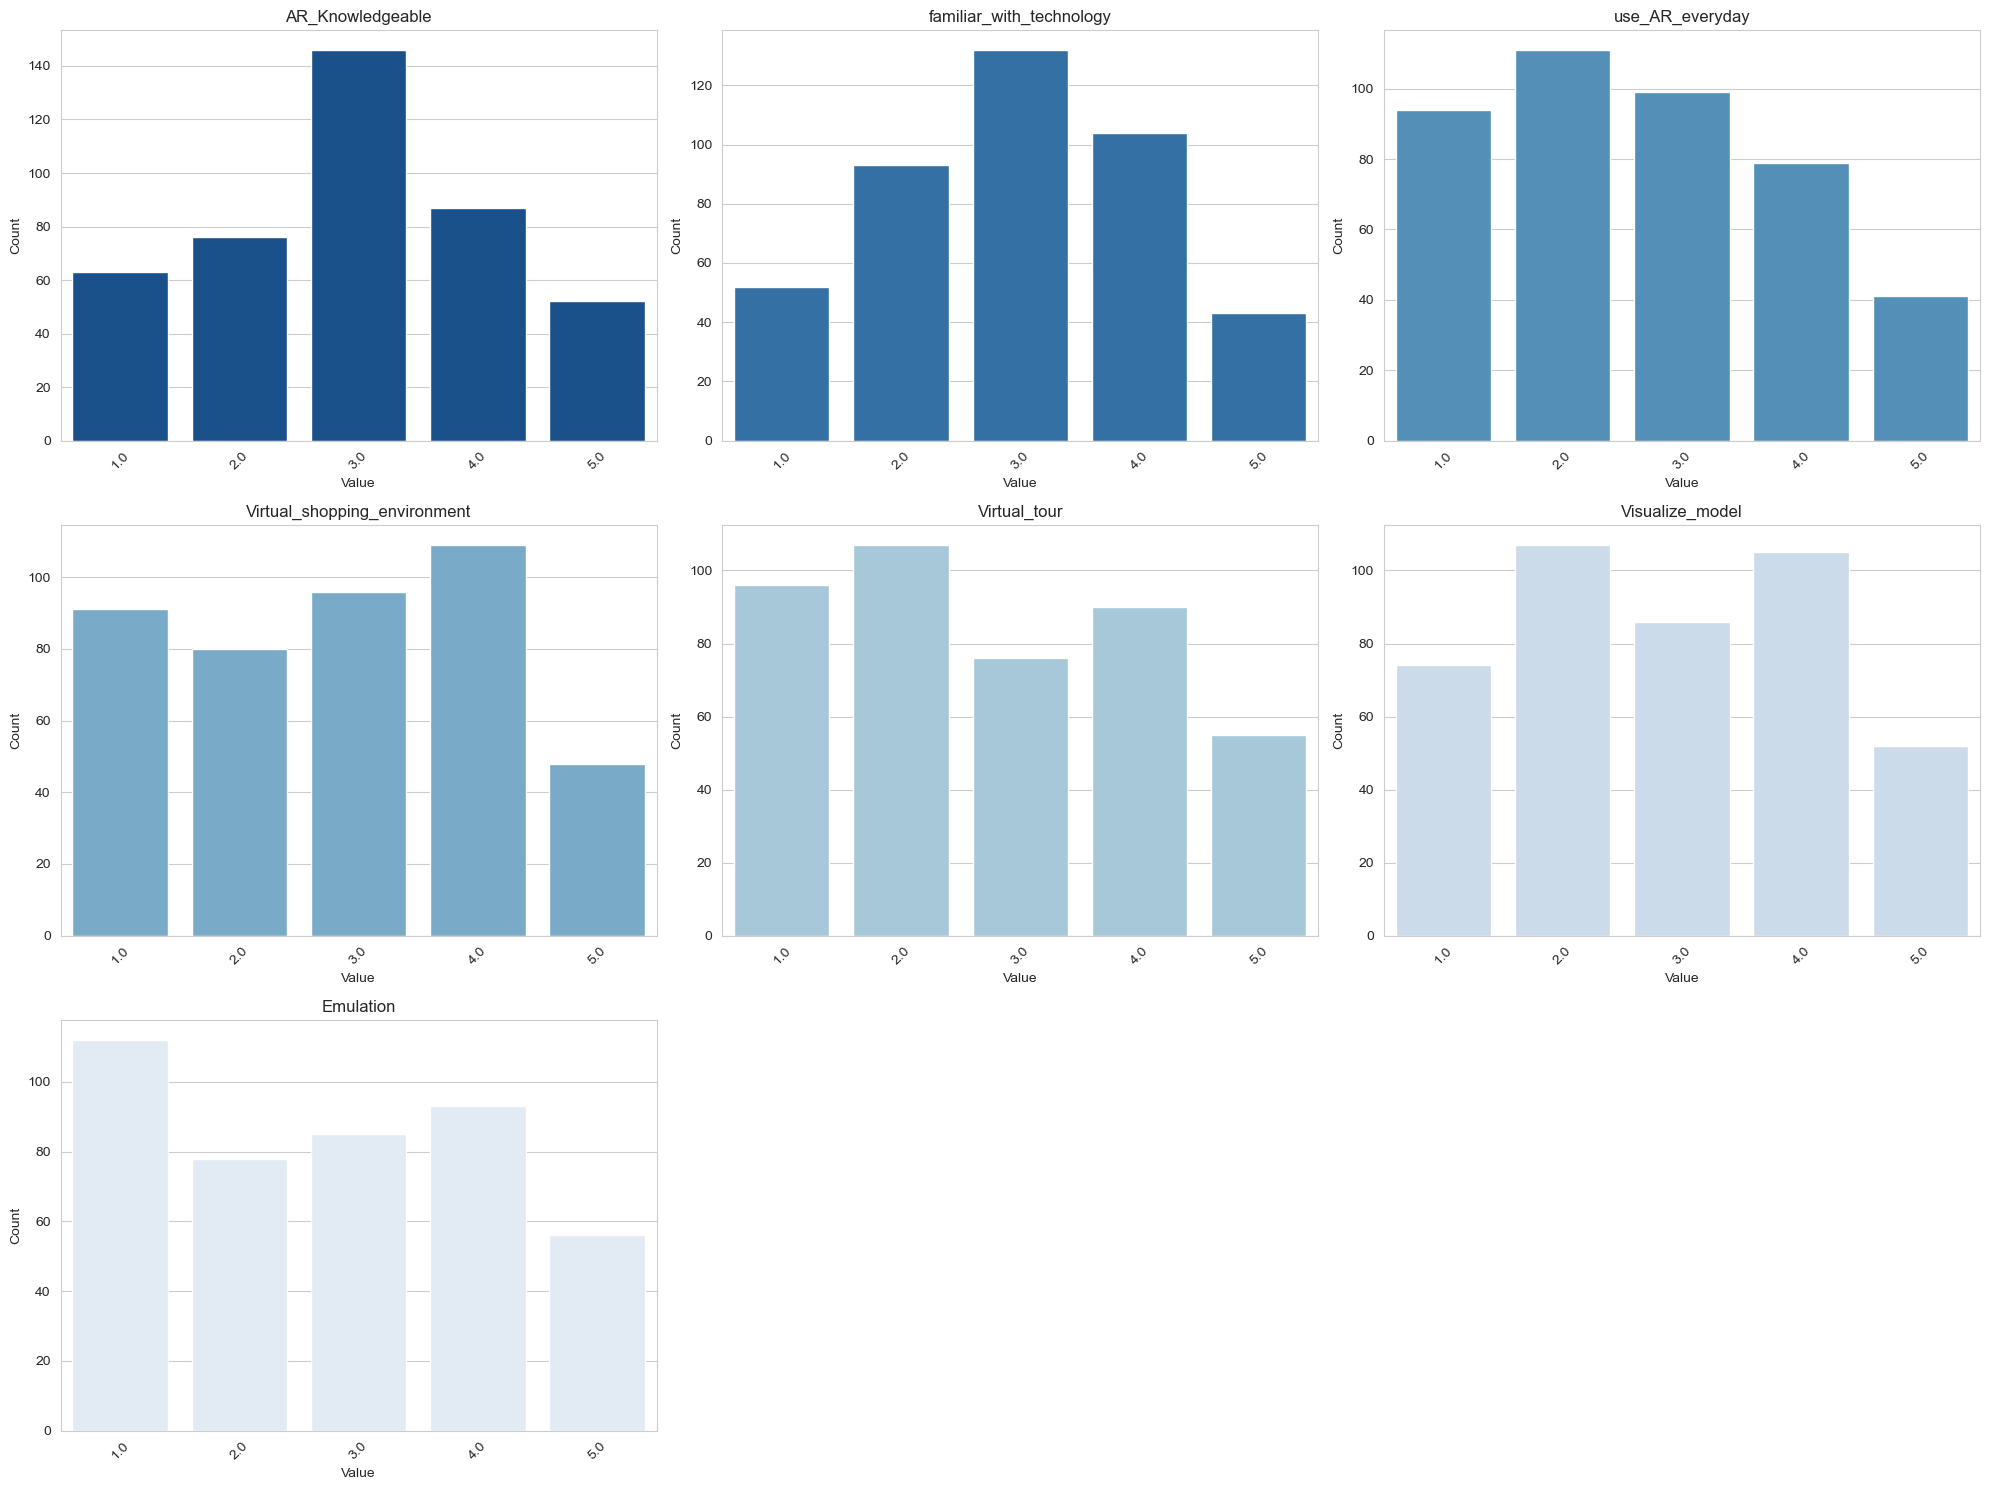

In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_cleaned is your dataframe
features = ['AR_Knowledgeable', 'familiar_with_technology', 'use_AR_everyday', 
            'Virtual_shopping_environment', 'Virtual_tour', 'Visualize_model', 'Emulation']

# Set up the plot style
sns.set_style("whitegrid")
plt.figure(figsize=(20, 15))

# Create a color palette with shades of blue
blue_palette = sns.color_palette("Blues_r", n_colors=len(features))

# Create subplots
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    
    # Create the bar plot
    sns.barplot(x=df_survey_cleaned[feature].value_counts().index, 
                y=df_survey_cleaned[feature].value_counts().values, 
                palette=[blue_palette[i-1]])
    
    # Set labels and title
    plt.title(feature)
    plt.xlabel('Value')
    plt.ylabel('Count')
    
    # Rotate x-axis labels if needed
    plt.xticks(rotation=45)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [150]:
import pandas as pd
from scipy.stats import spearmanr

 
features = ['BI', 'PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI','AT','AGEPEOU','AGEGender','GenderPEOU','GenderPPV','GenderPE',
           'GenderHM','GenderSOI','GenderSEI','AGESOI','AGESEI','AGEPPV','PEAT','AGEHM','AGEPE','AGEAT','GenderAT','HMPU','HMPEOU','HMSOI','HMSEI','HMPE']

 
# Create a correlation matrix
corr_matrix = df_survey_cleaned[features].corr(method='spearman')



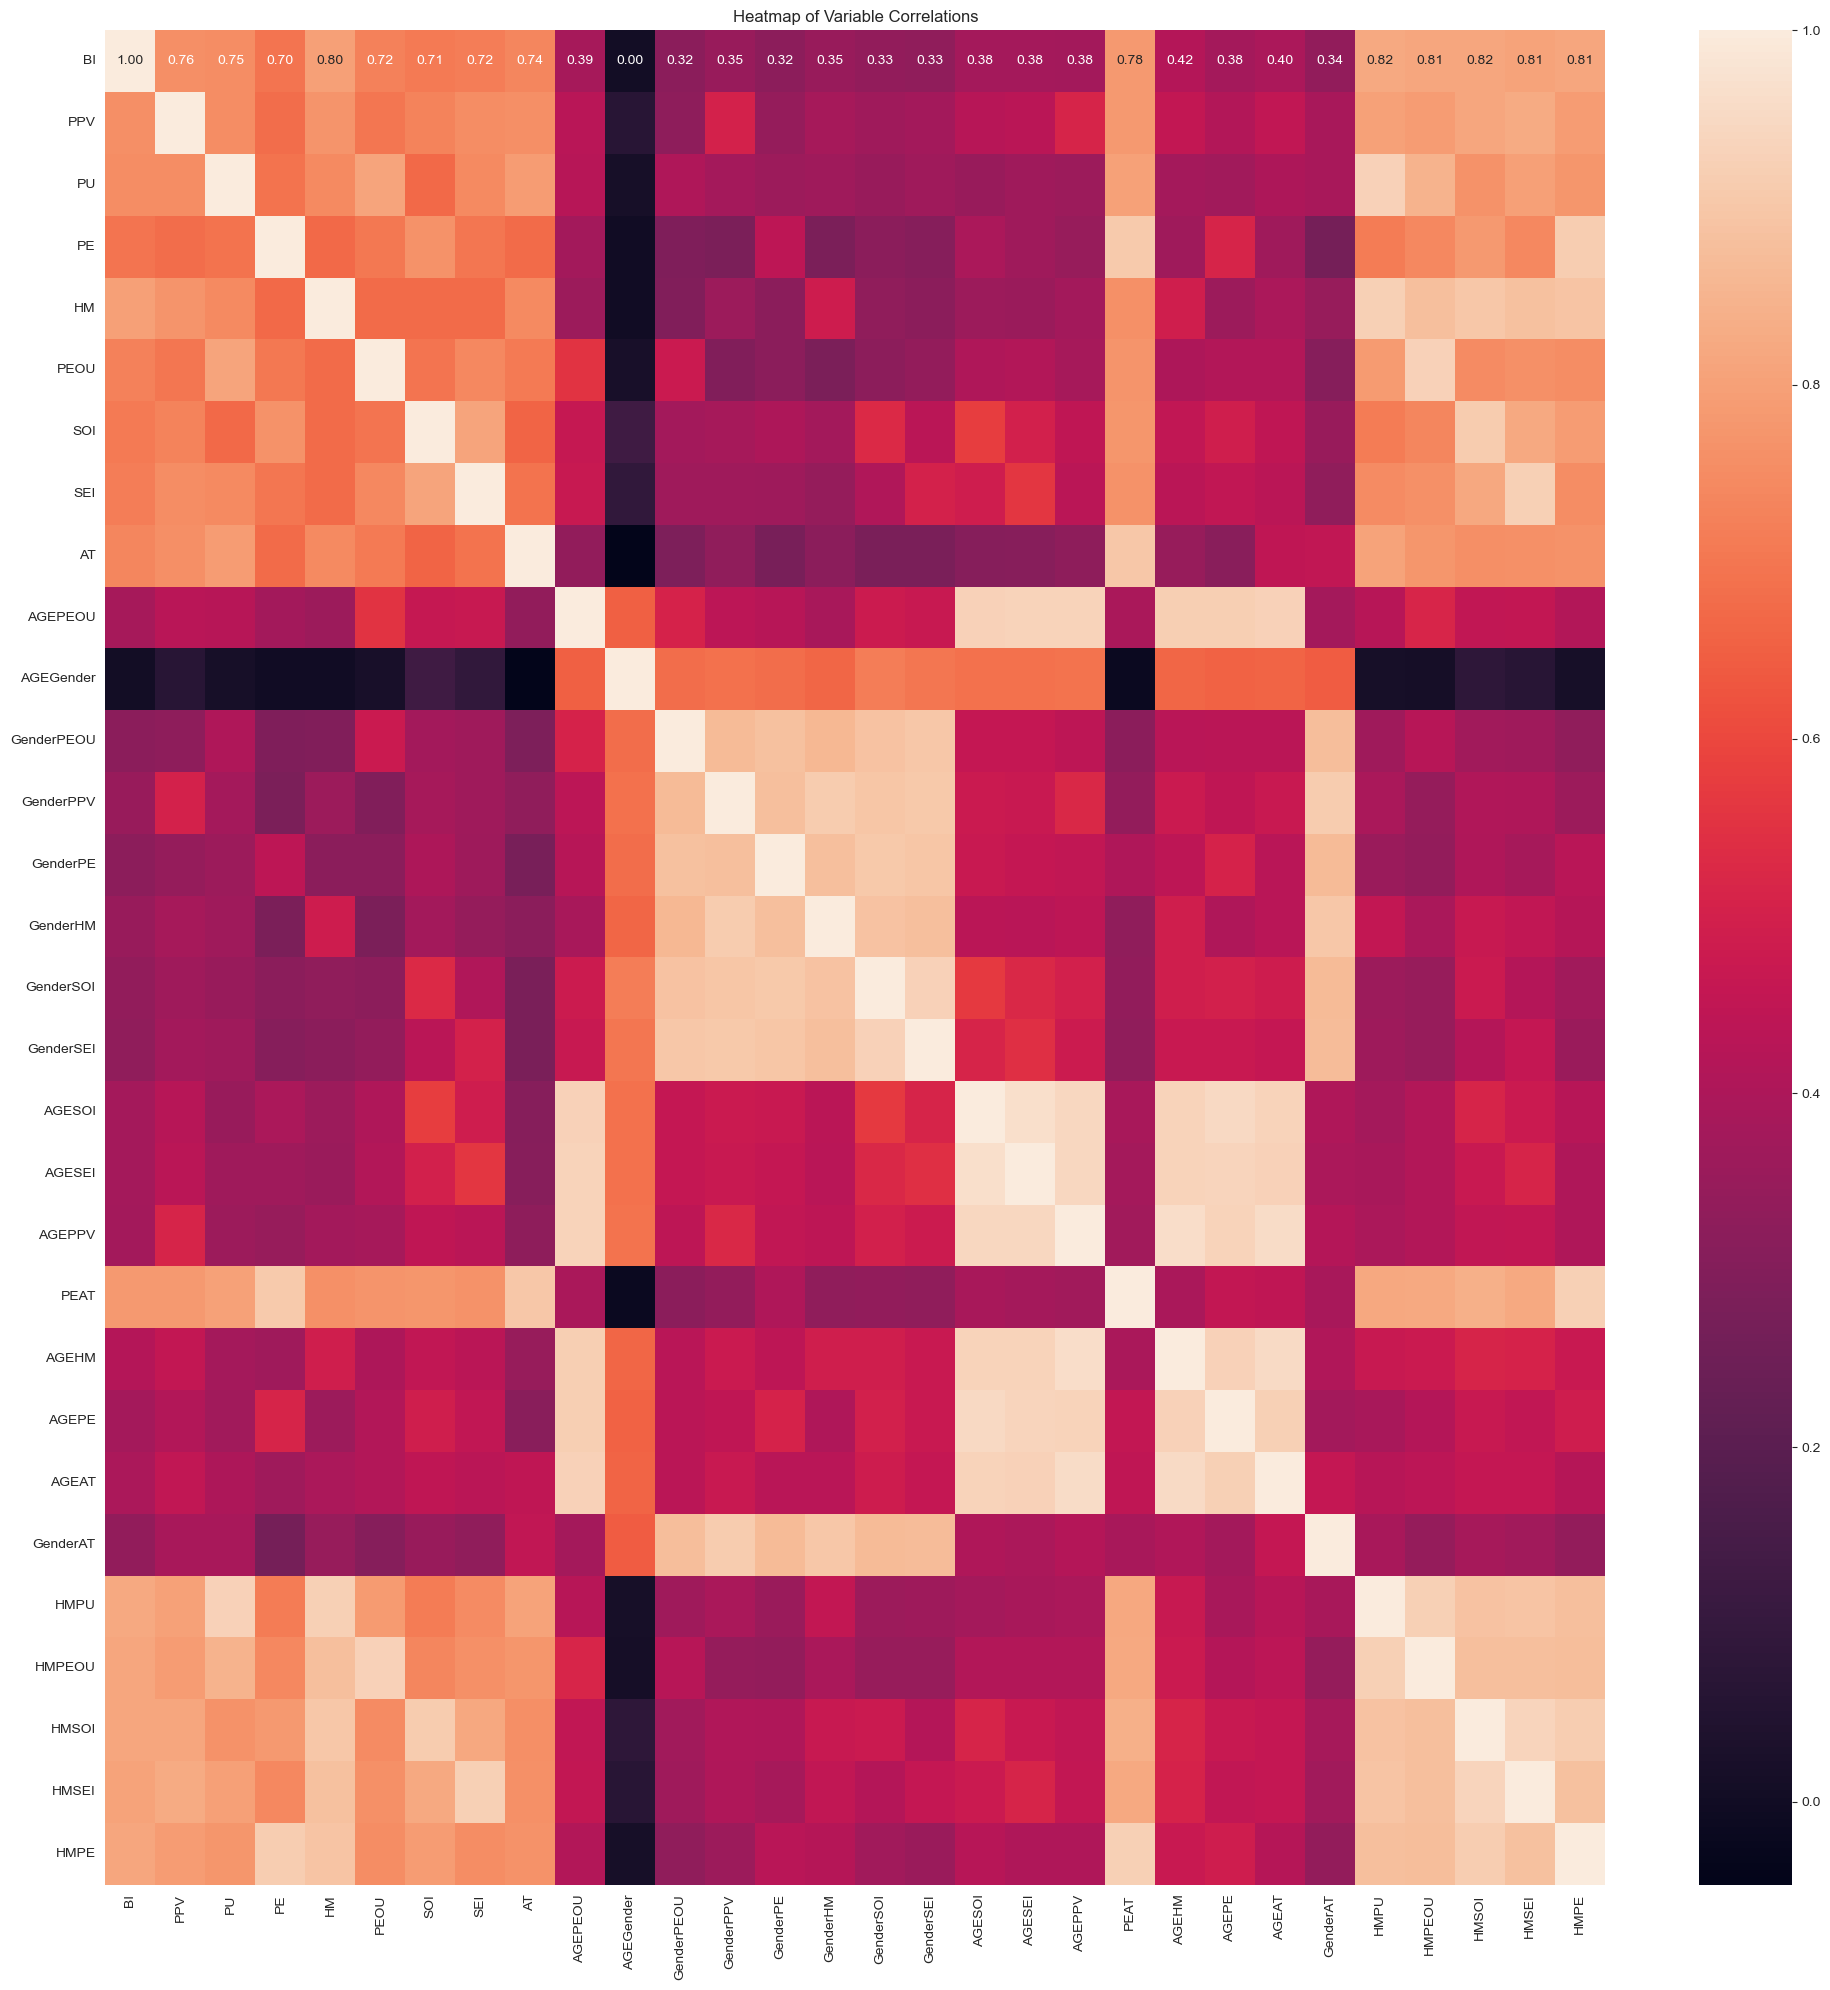

In [151]:
# Create the heatmap using seaborn
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cbar=True)

# Set the title and adjust the plot display
plt.title('Heatmap of Variable Correlations')
plt.tight_layout()

# Show the plot
plt.show()

## Data Mining

In [173]:
# Assuming you have a cleaned dataframe named 'df_survey_cleaned'
df = df_survey_cleaned

 

X = df[['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num','use_type_cnts']]
y = df['BI']

# Sample size check
print(f"Sample size: {len(X)}")
print(f"Number of features: {X.shape[1]}")
print(f"Observations per feature: {len(X) / X.shape[1]:.2f}")



Sample size: 424
Number of features: 11
Observations per feature: 38.55


C:\Users\cemcd\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


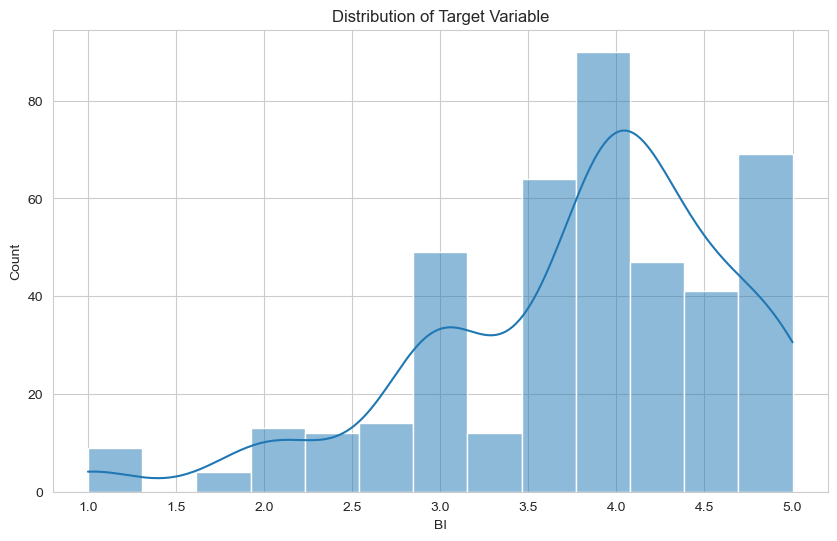

In [174]:
# Distribution of target variable
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True)
plt.title("Distribution of Target Variable")
plt.show()



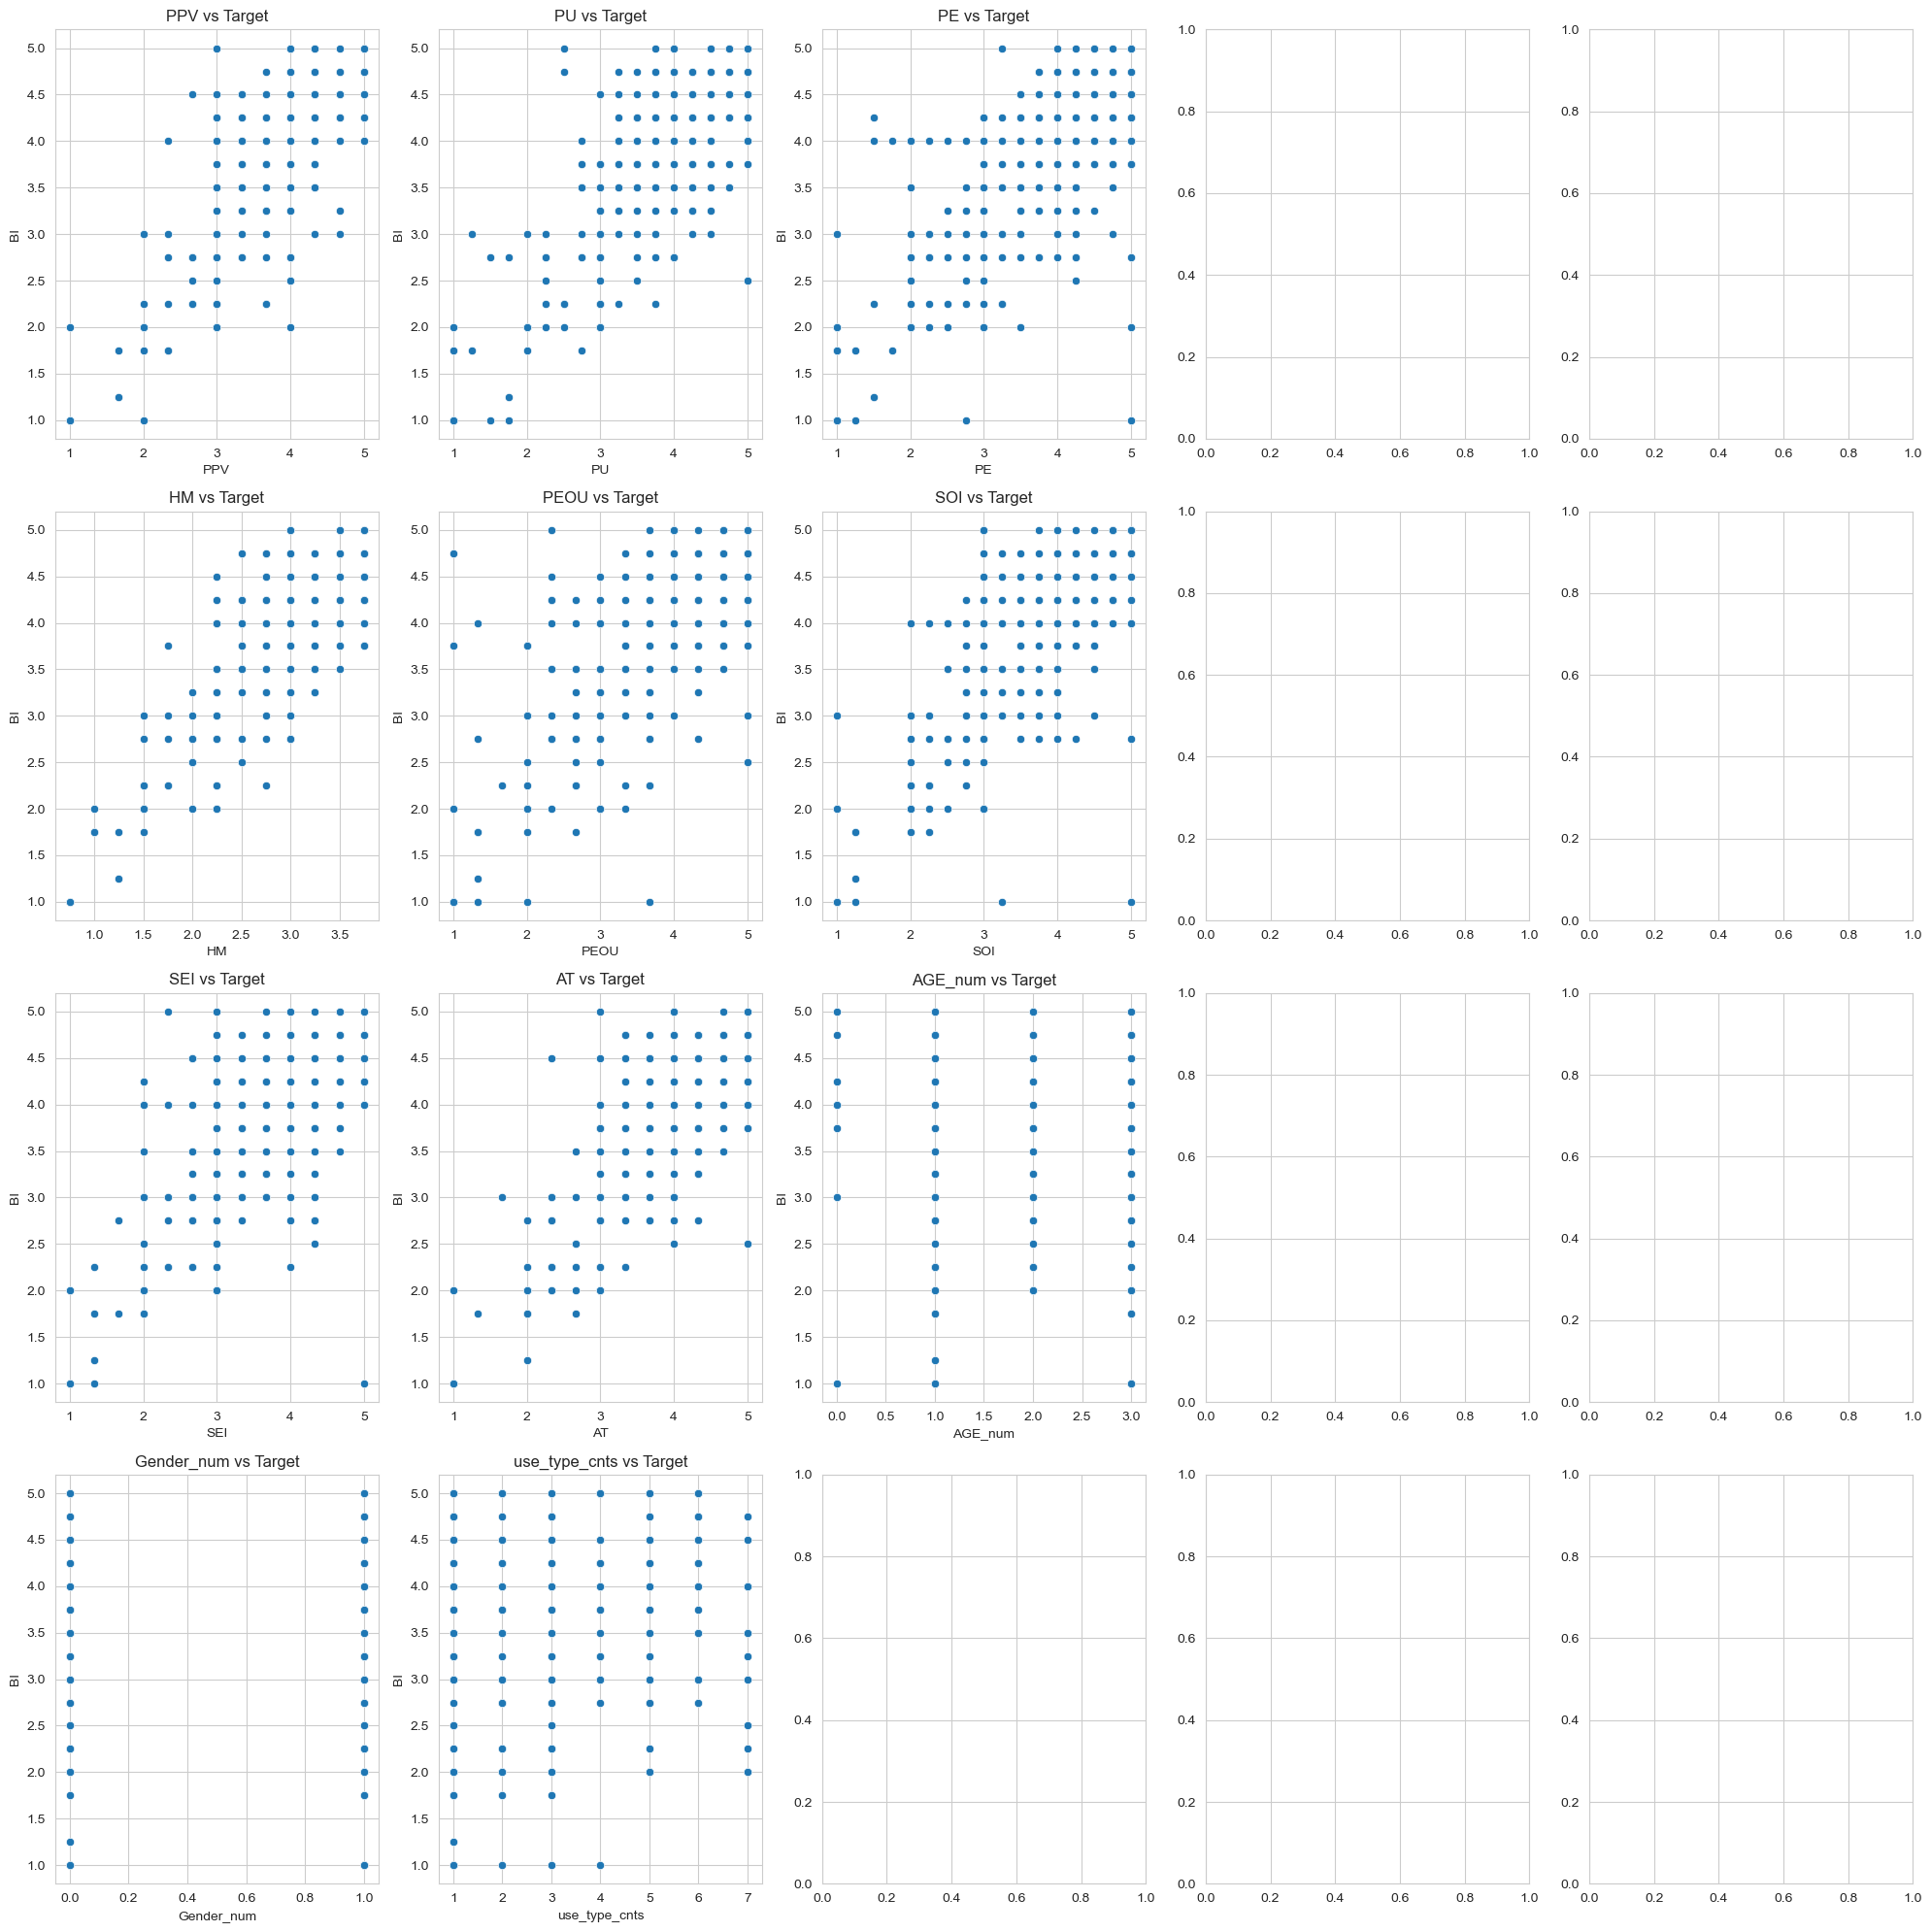

In [175]:
# Linearity check
fig, axes = plt.subplots(4, 5, figsize=(20, 20))
for i, col in enumerate(X.columns):
    sns.scatterplot(x=X[col], y=y, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f"{col} vs Target")
plt.tight_layout()
plt.show()



In [176]:
# Multicollinearity check
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

print(calculate_vif(X))



        variables         VIF
0             PPV  115.495769
1              PU  126.432194
2              PE   58.522370
3              HM   90.275783
4            PEOU   68.358493
5             SOI   95.611389
6             SEI   84.451477
7              AT   97.753888
8         AGE_num    7.035902
9      Gender_num    3.879315
10  use_type_cnts    3.570953


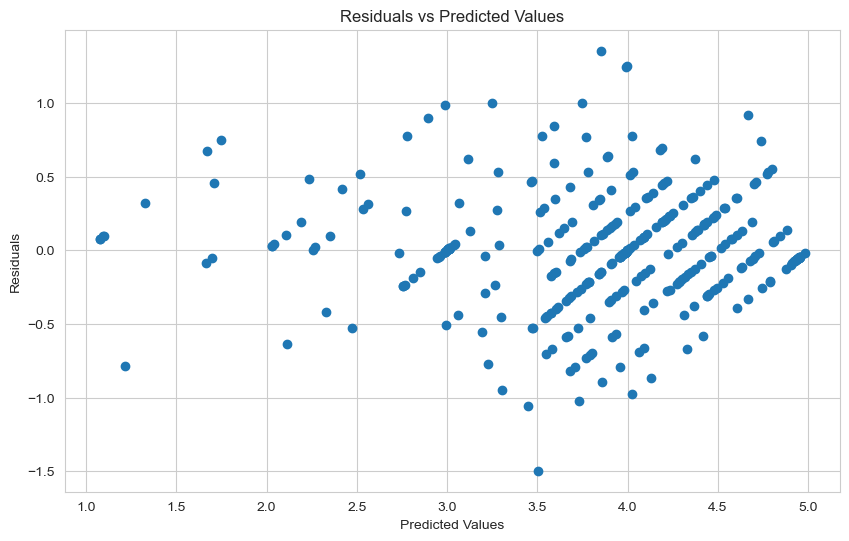

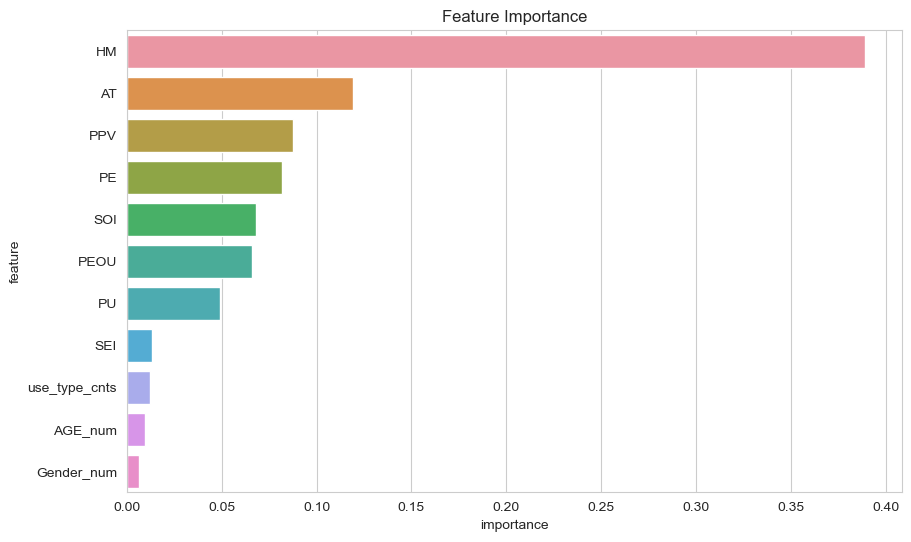

R-squared: 0.8413
RMSE: 0.3337


In [177]:
# Fit a linear regression model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Homoscedasticity check
y_pred = model.predict(X_train_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y_pred - y_train)
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# Feature importance
importance = pd.DataFrame({'feature': X.columns, 'importance': np.abs(model.coef_)})
importance = importance.sort_values('importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance)
plt.title("Feature Importance")
plt.show()

# Model performance
from sklearn.metrics import r2_score, mean_squared_error
print(f"R-squared: {r2_score(y_test, model.predict(X_test_scaled)):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled))):.4f}")

Processing MLR...


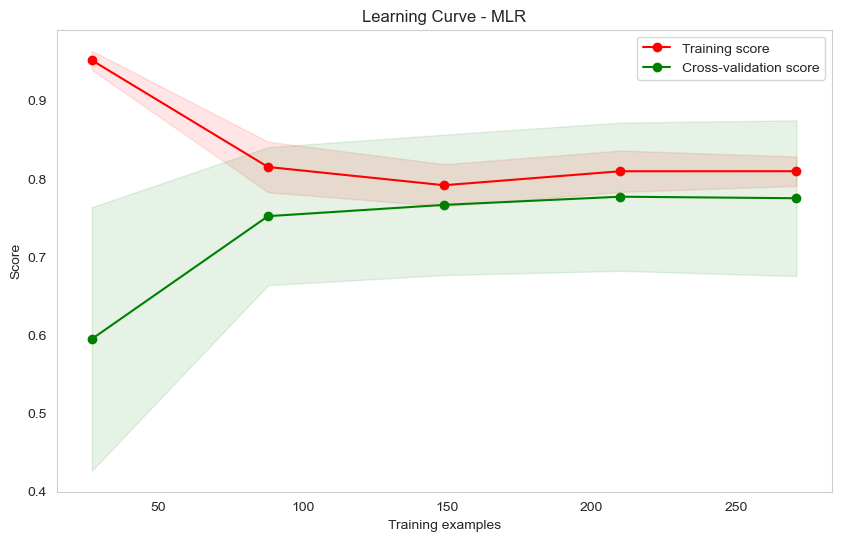

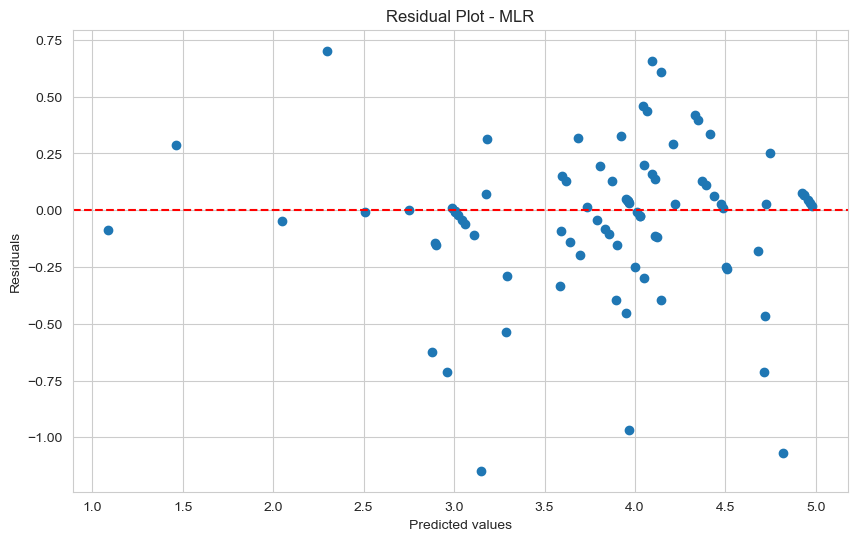

Processing KNN...


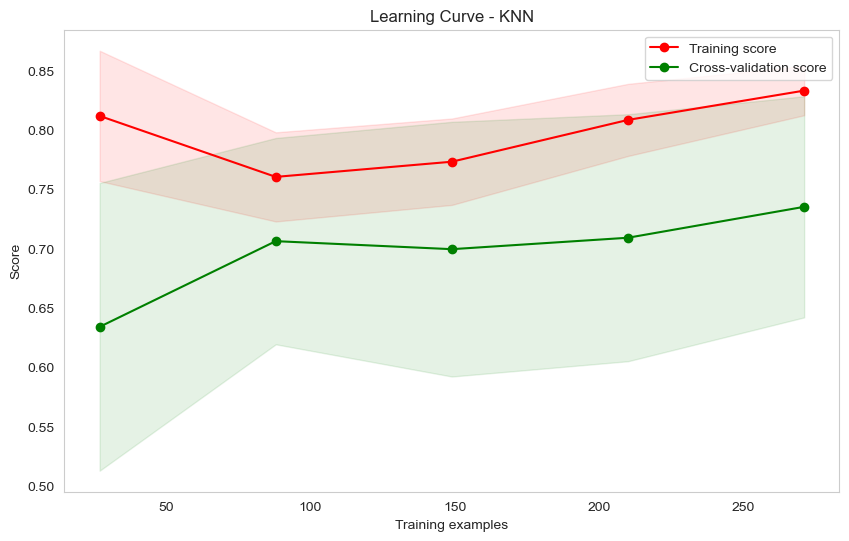

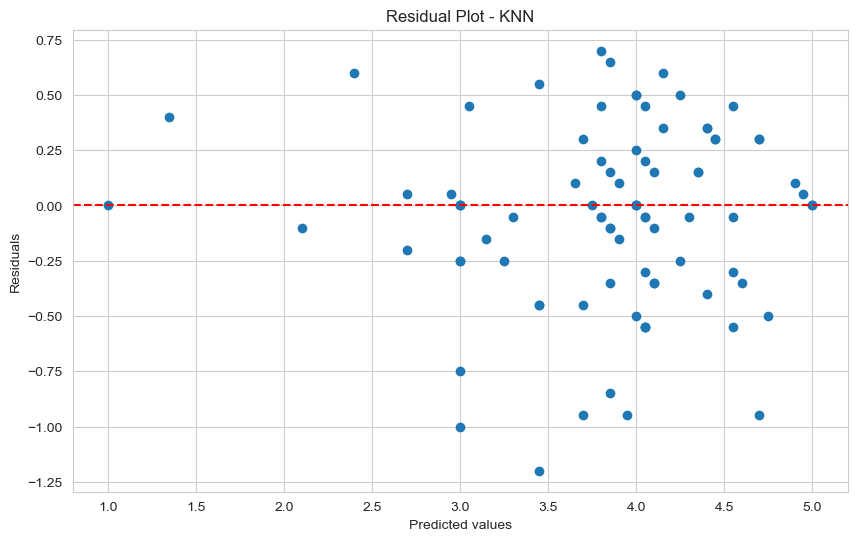

Processing Random Forest...


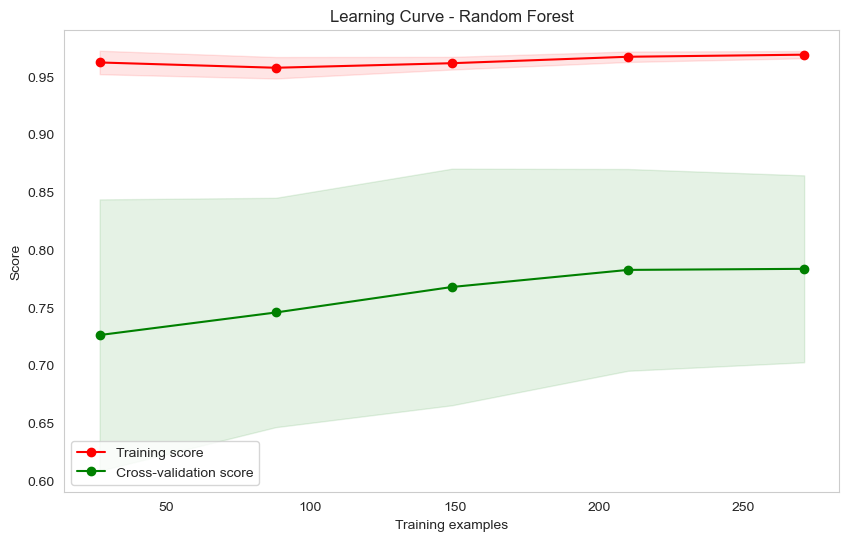

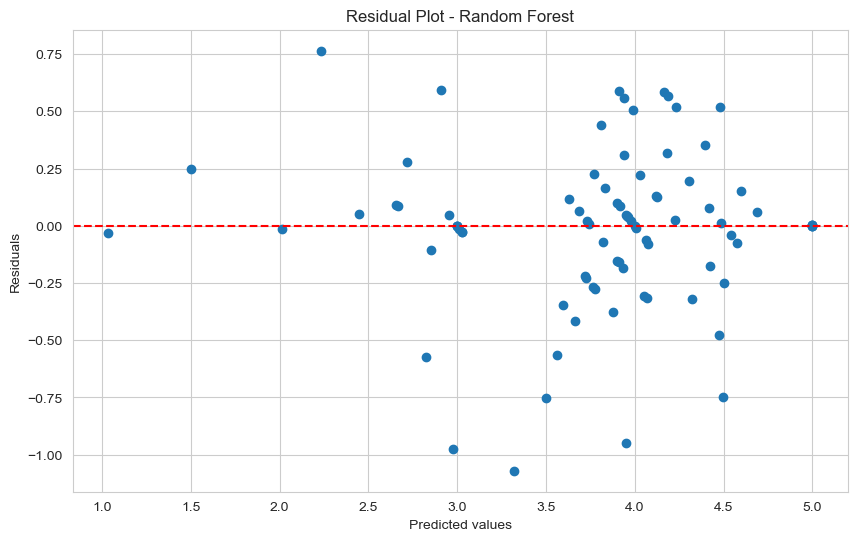

Processing SVR...


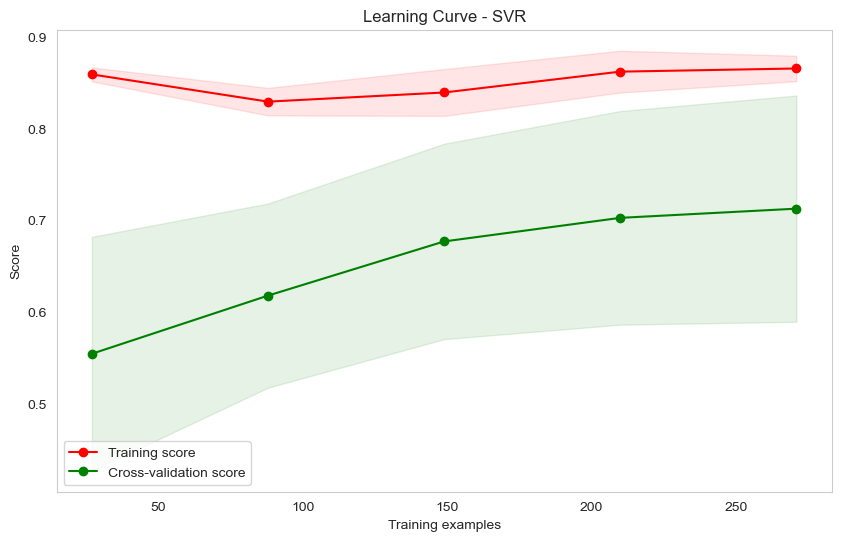

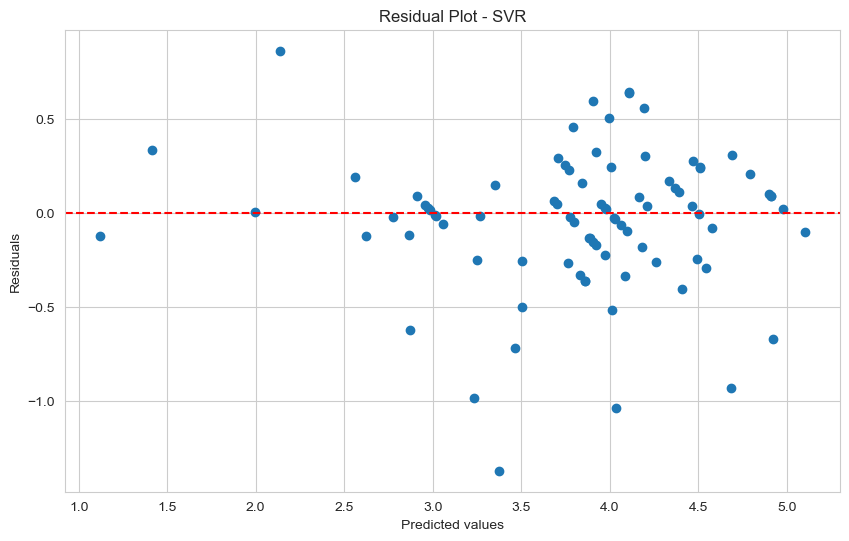

Processing MLP...


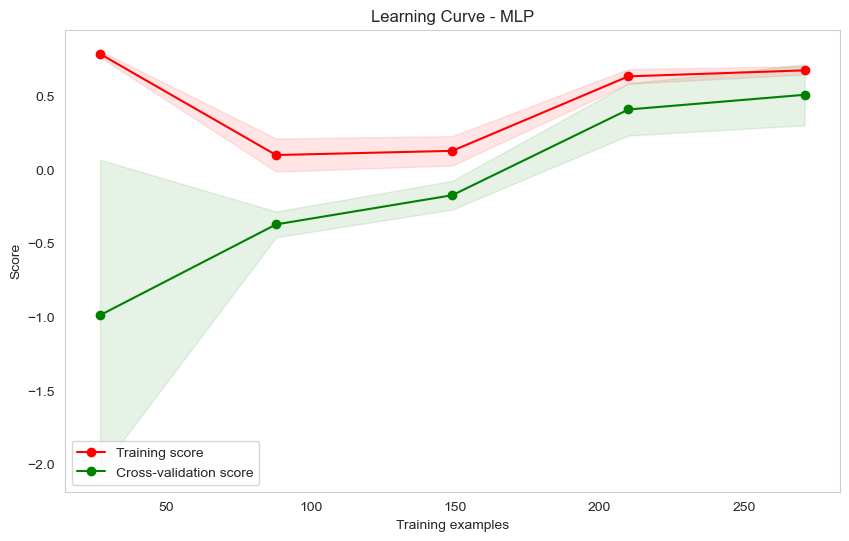

C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


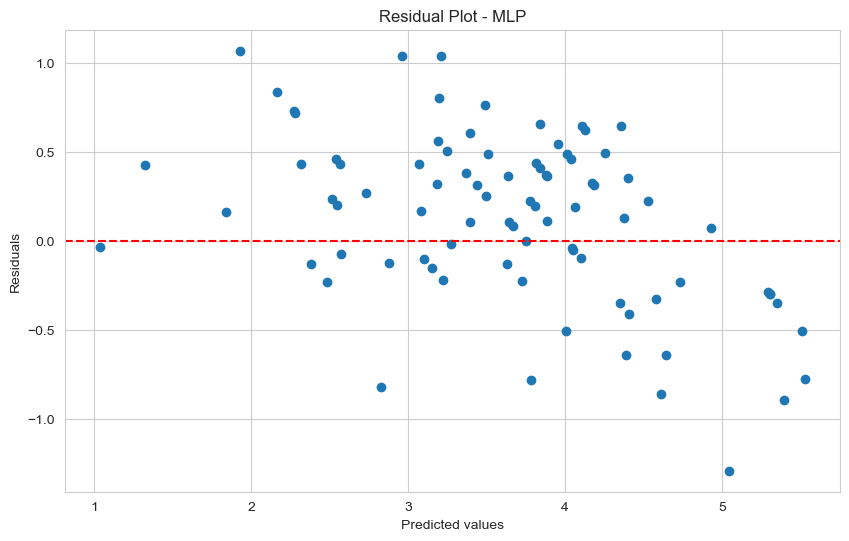

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming X and y are your features and target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'MLR': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'MLP': MLPRegressor(random_state=42)
}

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5))
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

def plot_residuals(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, y_true - y_pred)
    plt.title(title)
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")
    plt.axhline(y=0, color='r', linestyle='--')
    plt.show()

# Plot learning curves and residuals for each model
for name, model in models.items():
    print(f"Processing {name}...")
    
    # Learning curve
    plot_learning_curve(model, X_train_scaled, y_train, f"Learning Curve - {name}")
    
    # Fit model and make predictions
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Residual plot
    plot_residuals(y_test, y_pred, f"Residual Plot - {name}")

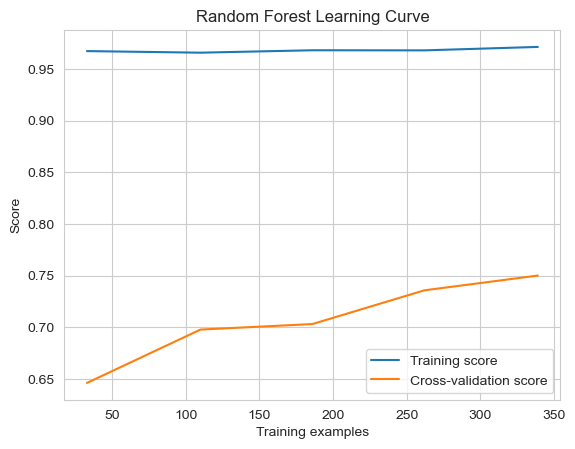

In [178]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=5)
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation score")
    plt.legend()
    plt.show()

plot_learning_curve(RandomForestRegressor(), X, y, "Random Forest Learning Curve")

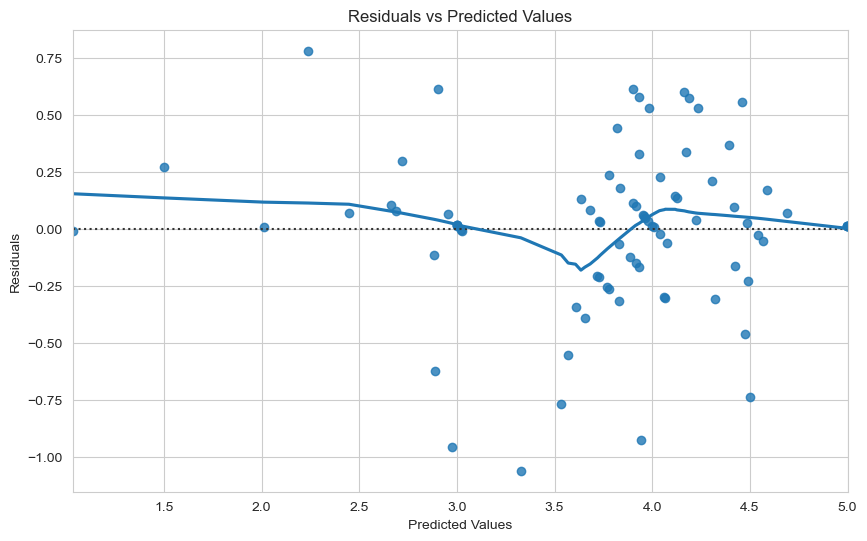

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fit model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True)
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

## end Data Mining

## Outlier Detection

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and 'column_name' is the column you want to check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['column_name'])
plt.title('Box Plot for column_name')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['feature1'], df['feature2'])
plt.title('Scatter Plot of feature1 vs feature2')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

In [ ]:
from scipy import stats
import numpy as np

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df['column_name']))

# Identify outliers
outliers = np.where(z_scores > 3)
print("Outliers detected at indices:", outliers)

In [ ]:
Q1 = df['column_name'].quantile(0.25)
Q3 = df['column_name'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df[(df['column_name'] < (Q1 - 1.5 * IQR)) | (df['column_name'] > (Q3 + 1.5 * IQR))]
print("Outliers detected:\n", outliers)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Fit the model
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['anomaly'] = lof.fit_predict(df[['column_name']])

# Identify outliers
outliers = df[df['anomaly'] == -1]
print("Outliers detected:\n", outliers)

In [ ]:
from sklearn.ensemble import IsolationForest

# Fit the model
iso_forest = IsolationForest(contamination=0.05)
df['anomaly'] = iso_forest.fit_predict(df[['column_name']])

# Identify outliers
outliers = df[df['anomaly'] == -1]
print("Outliers detected:\n", outliers)

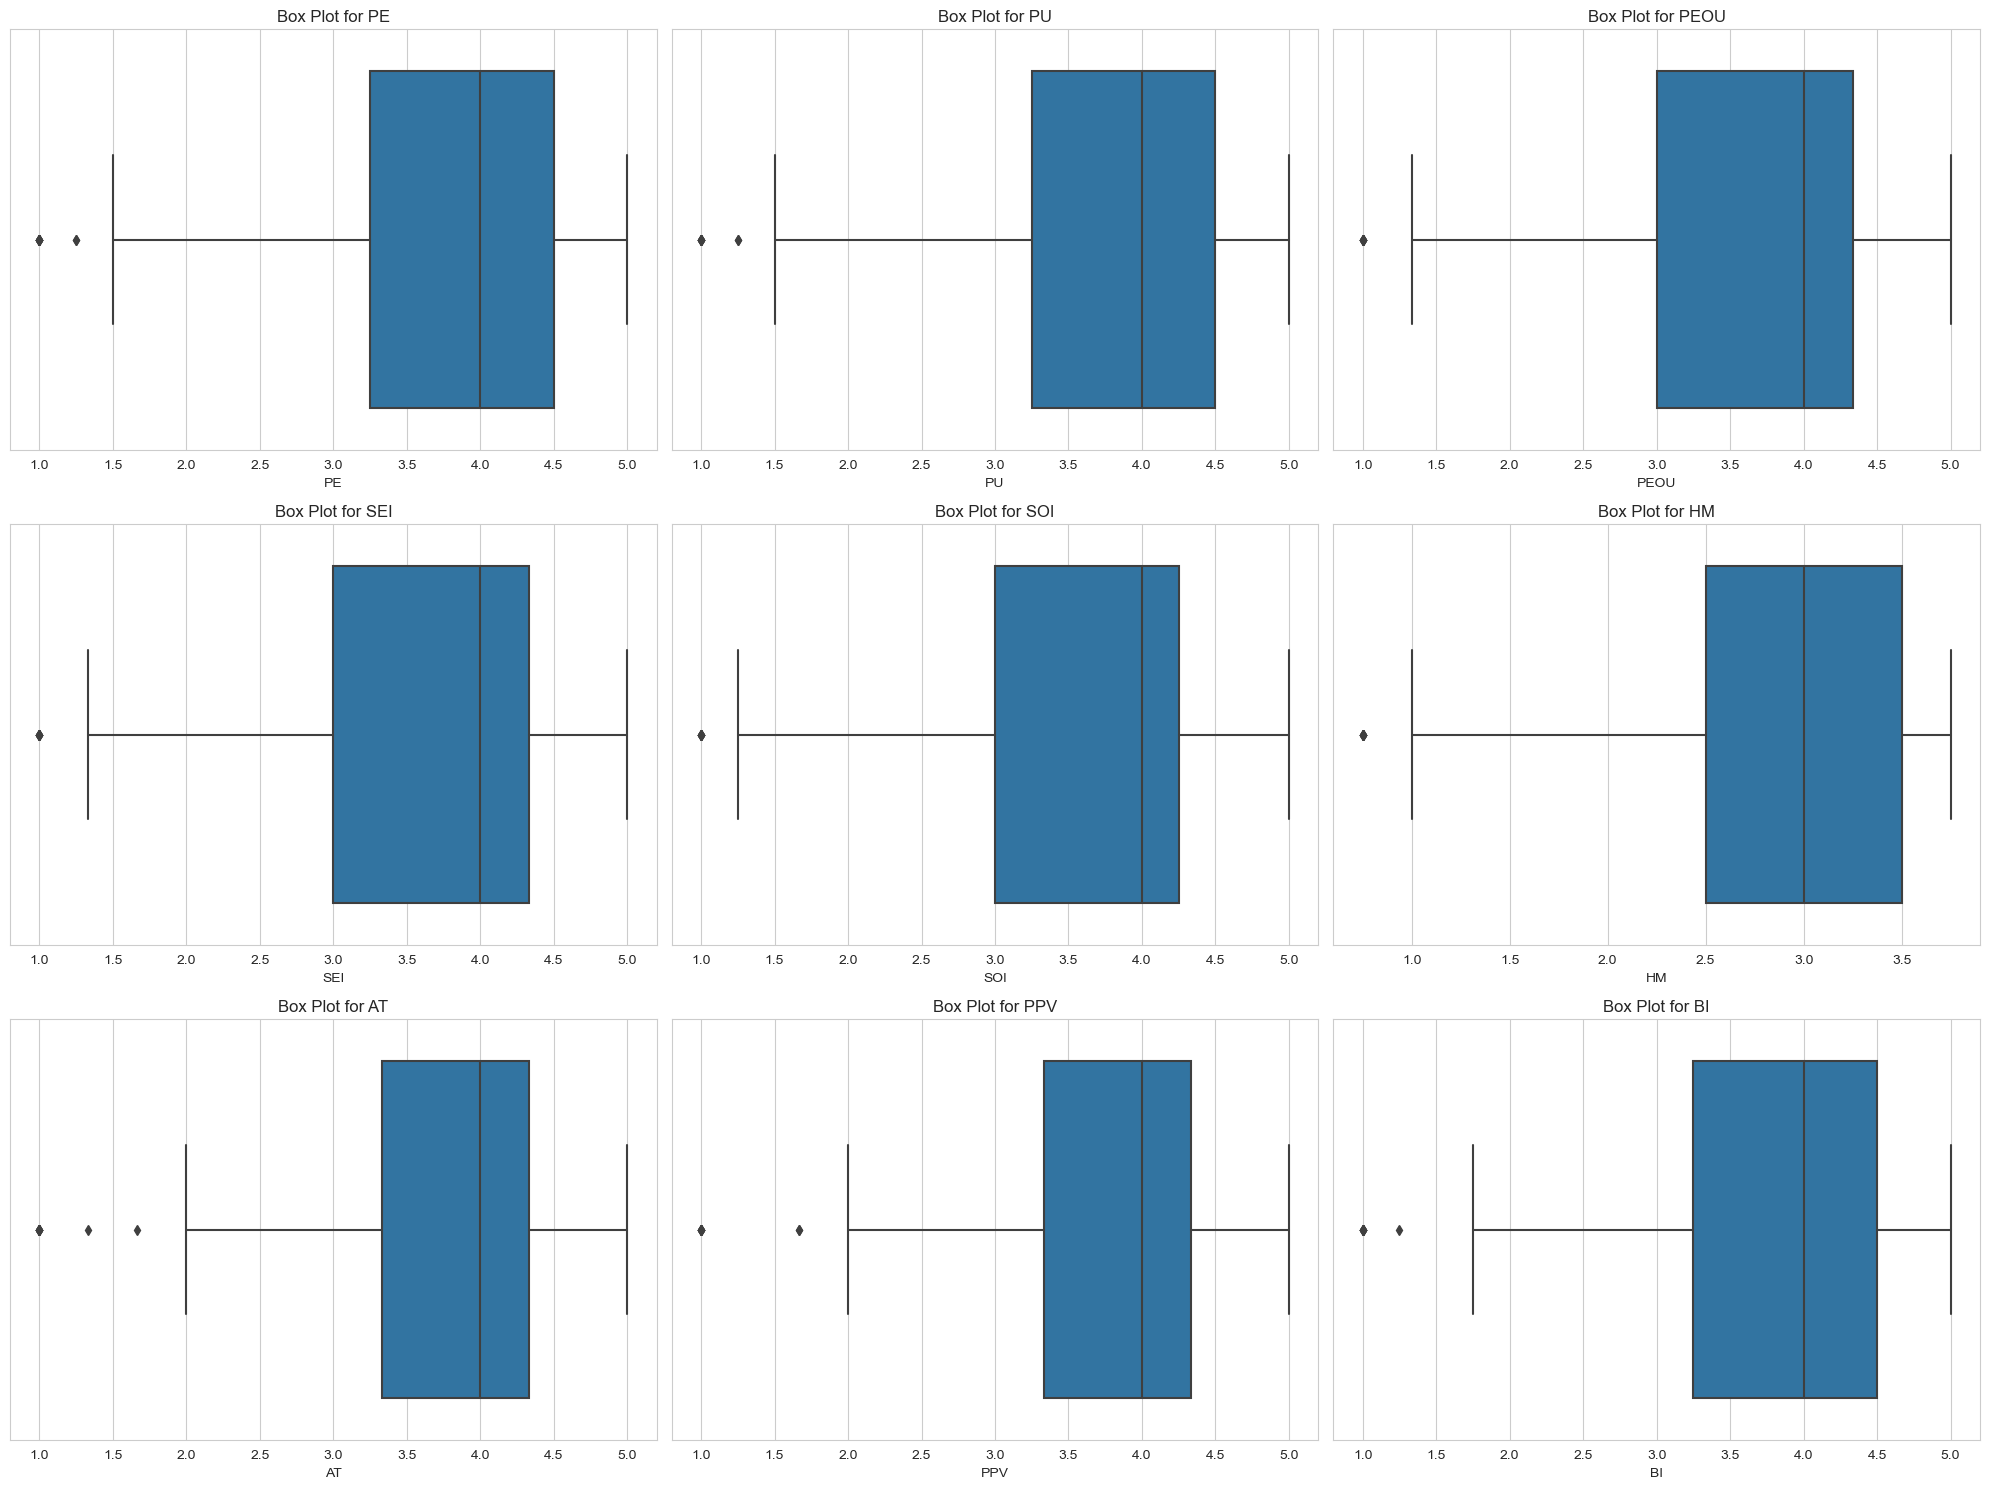

Outliers detected in PE using Z-score method at indices: []
Outliers detected in PU using Z-score method at indices: [  5  34  67 161 162 192 375 405]
Outliers detected in PEOU using Z-score method at indices: []
Outliers detected in SEI using Z-score method at indices: []
Outliers detected in SOI using Z-score method at indices: [ 27  34  52  67 161 192 375 405]
Outliers detected in HM using Z-score method at indices: [  5  34 161 192 358 375 394 405]
Outliers detected in AT using Z-score method at indices: [  5  34  67 161 192 358 375 394 405]
Outliers detected in PPV using Z-score method at indices: [  5  34  67 161 192 375 394 405]
Outliers detected in BI using Z-score method at indices: [  5  34 161 192 358 375 394 405]
Outliers detected in PE using IQR method at indices: [27, 34, 52, 65, 67, 127, 161, 162, 192, 358, 375, 405]
Outliers detected in PU using IQR method at indices: [5, 34, 67, 161, 162, 192, 316, 375, 391, 405]
Outliers detected in PEOU using IQR method at indices: [

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Assuming df_survey_cleaned is your DataFrame
df = df_survey_cleaned

variables = ['PE', 'PU', 'PEOU', 'SEI', 'SOI', 'HM', 'AT', 'PPV', 'BI']

# Visualization: Box Plots
plt.figure(figsize=(20, 15))  # Increased figure size
for i, var in enumerate(variables, 1):
    plt.subplot(3, 3, i)  # Changed to 3x3 grid
    sns.boxplot(x=df[var])
    plt.title(f'Box Plot for {var}')
plt.tight_layout()
plt.show()

# Initialize counters for outliers
z_outlier_count = 0
iqr_outlier_count = 0

# Statistical Method: Z-Score
outliers_zscore = {}
for var in variables:
    z_scores = np.abs(stats.zscore(df[var]))
    outliers = np.where(z_scores > 3)
    outliers_zscore[var] = outliers[0]
    z_outlier_count += len(outliers[0])
    print(f"Outliers detected in {var} using Z-score method at indices: {outliers[0]}")

# Statistical Method: IQR
outliers_iqr = {}
for var in variables:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[var] < (Q1 - 1.5 * IQR)) | (df[var] > (Q3 + 1.5 * IQR))].index
    outliers_iqr[var] = outliers
    iqr_outlier_count += len(outliers)
    print(f"Outliers detected in {var} using IQR method at indices: {outliers.tolist()}")

# Summary of Outliers
# Combine results from both methods
combined_outliers = {}
for var in variables:
    combined_outliers[var] = {
        'Z-score': outliers_zscore[var],
        'IQR': outliers_iqr[var].tolist()
    }

# Print combined results
for var, outliers in combined_outliers.items():
    print(f"\nOutliers for {var}:")
    print(f"Z-score method: {outliers['Z-score']}")
    print(f"IQR method: {outliers['IQR']}")

# Print total count of outliers detected
print(f"\nTotal number of outliers detected using Z-score method: {z_outlier_count}")
print(f"Total number of outliers detected using IQR method: {iqr_outlier_count}")

## check fo non-linear relationshiops between BI an independent variables


In [138]:
## mutual information
import pandas as pd
from sklearn.metrics import mutual_info_score

# Assuming you have a cleaned dataframe named 'df_survey_cleaned'
df = df_survey_cleaned

# Define the target variable and independent variables
target_var = 'BI'
feature_vars = ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender','GenderPEOU', 'GenderPPV', 'GenderPE','GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV','PEAT','AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']

# Calculate mutual information for each independent variable
mutual_info_scores = []
for feature in feature_vars:
    X = df[feature].values 
    y = df[target_var].values
    mutual_info = mutual_info_score(X, y)
    mutual_info_scores.append((feature, mutual_info))

# Sort the mutual information scores in descending order
mutual_info_scores.sort(key=lambda x: x[1], reverse=True)

# Print the mutual information scores
print("Mutual Information Scores:")
for feature, score in mutual_info_scores:
    print(f"{feature}: {score:.3f}")

Mutual Information Scores:
HMPU: 1.396
HMSOI: 1.352
HMPE: 1.330
PEAT: 1.320
HMPEOU: 1.272
HMSEI: 1.264
AGEHM: 0.904
AGESOI: 0.875
AGESEI: 0.866
AGEPPV: 0.865
AGEAT: 0.858
AGEPE: 0.856
HM: 0.854
PU: 0.842
AGEPEOU: 0.840
PPV: 0.799
AT: 0.765
PEOU: 0.743
SEI: 0.736
SOI: 0.731
PE: 0.689
GenderHM: 0.609
GenderAT: 0.576
GenderPPV: 0.565
GenderSOI: 0.557
GenderPE: 0.545
GenderSEI: 0.542
GenderPEOU: 0.539
use_type_cnts: 0.149
AGEGender: 0.103
AGE_num: 0.091
Gender_num: 0.035


          Feature  MI Score
29          HMSEI  0.873331
26           HMPU  0.814070
27         HMPEOU  0.803190
28          HMSOI  0.789733
30           HMPE  0.776876
3              HM  0.770527
21           PEAT  0.724405
0             PPV  0.693788
7              AT  0.647890
1              PU  0.646600
22          AGEHM  0.590657
6             SEI  0.571404
4            PEOU  0.560651
5             SOI  0.556348
24          AGEAT  0.522008
15       GenderHM  0.514618
2              PE  0.504664
19         AGESEI  0.501320
20         AGEPPV  0.481663
18         AGESOI  0.468213
25       GenderAT  0.459176
13      GenderPPV  0.450944
10        AGEPEOU  0.436487
17      GenderSEI  0.426583
23          AGEPE  0.417306
16      GenderSOI  0.397617
12     GenderPEOU  0.371454
14       GenderPE  0.365135
31  use_type_cnts  0.090785
8         AGE_num  0.063999
11      AGEGender  0.000000
9      Gender_num  0.000000


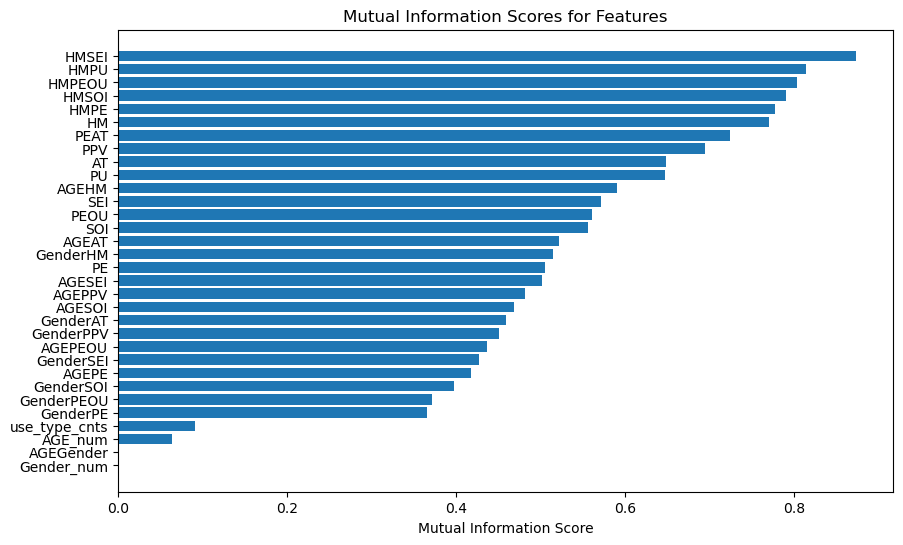

AttributeError: module 'pdpbox.pdp' has no attribute 'pdp_isolate'

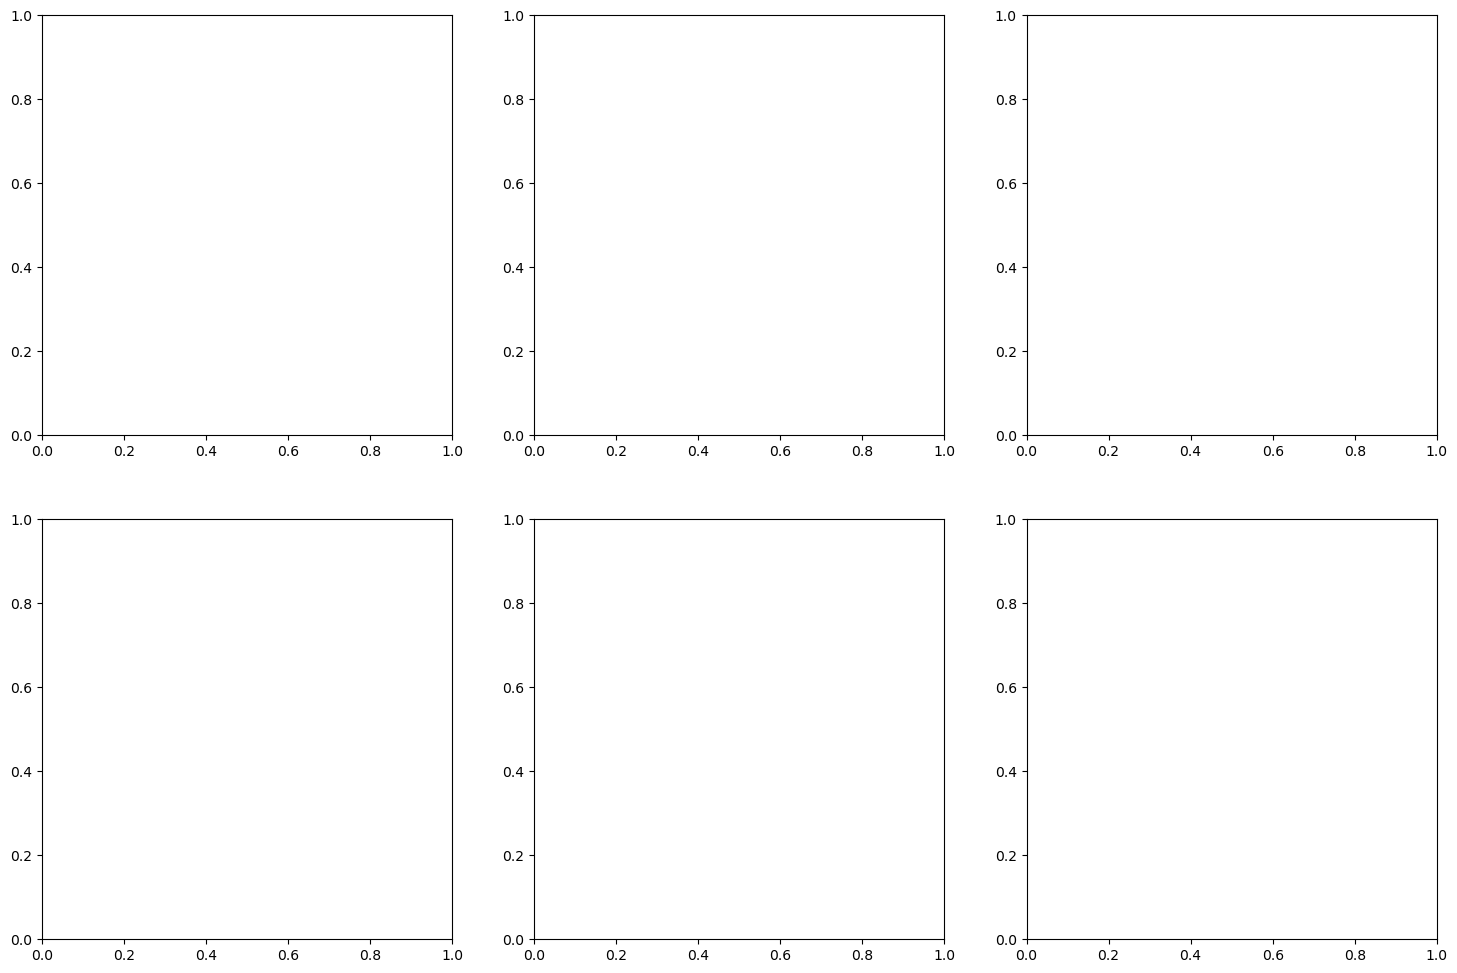

In [151]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from pdpbox import pdp, info_plots
import matplotlib.pyplot as plt

# Assuming df_survey_cleaned is your DataFrame
# For example:
# df_survey_cleaned = pd.read_csv('path_to_your_data.csv')

# Specify the target and independent variables
target_var = 'BI'
feature_vars = ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender','GenderPEOU', 'GenderPPV', 'GenderPE','GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV','PEAT','AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']


# Prepare the data
X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned[target_var]

# Calculate mutual information scores
mi_scores = mutual_info_regression(X, y)

# Fit a machine learning model (e.g., Random Forest)
model = RandomForestRegressor()
model.fit(X, y)

# Create a DataFrame for MI scores
mi_df = pd.DataFrame({'Feature': feature_vars, 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)

# Display MI scores
print(mi_df)

# Plot MI scores
plt.figure(figsize=(10, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'])
plt.xlabel('Mutual Information Score')
plt.title('Mutual Information Scores for Features')
plt.gca().invert_yaxis()
plt.show()

# Create PDPs for top features based on MI scores
top_features = mi_df['Feature'].values[:5]  # Get top 5 features based on MI scores

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
ax = ax.flatten()

for i, feature in enumerate(top_features):
    pdp_isolate_out = pdp.pdp_isolate(model=model, dataset=X, model_features=feature_vars, feature=feature)
    pdp.pdp_plot(pdp_isolate_out, feature_name=feature, center=True, ax=ax[i], plot_lines=True, plot_pts_dist=True)
    ax[i].set_title(f'PDP for {feature} (MI Score: {mi_df[mi_df["Feature"] == feature]["MI Score"].values[0]:.2f})')

# Hide any unused subplots
for i in range(len(top_features), len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.show()


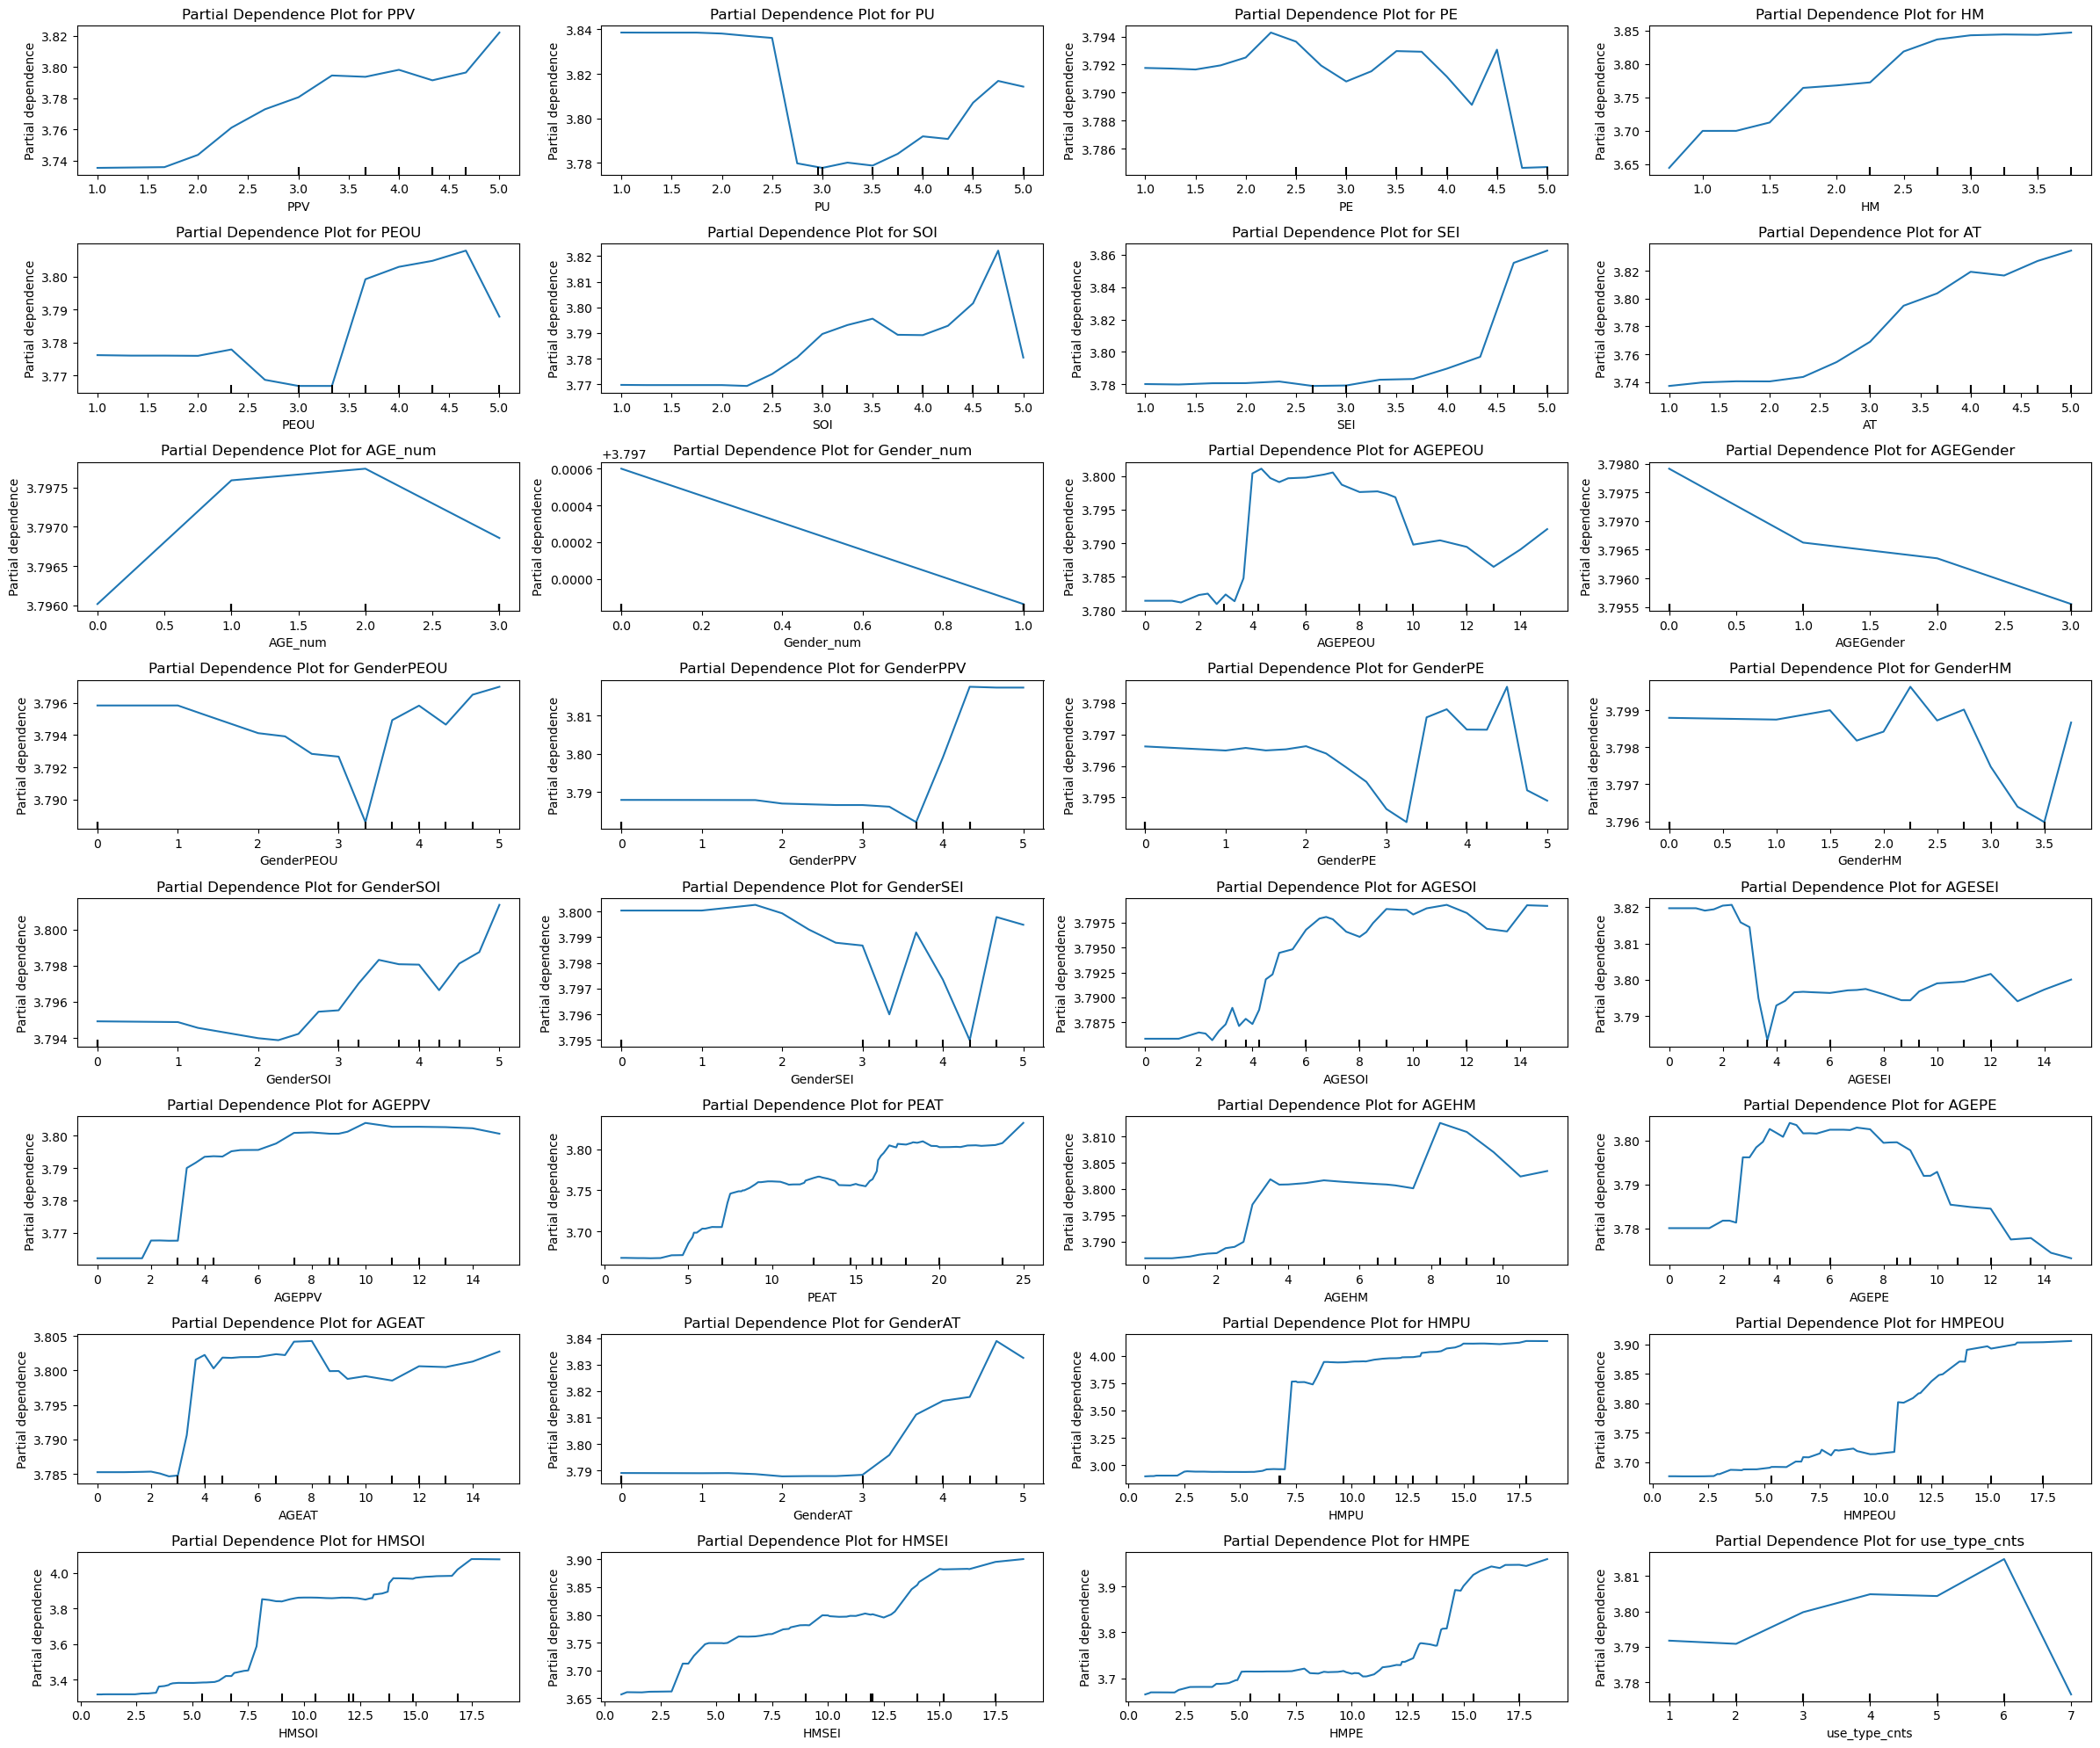

In [149]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

 

# Specify the target and independent variables
target_var = 'BI'
feature_vars =  ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender','GenderPEOU', 'GenderPPV', 'GenderPE','GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV','PEAT','AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']


# Prepare the data
X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned[target_var]

# Fit a machine learning model (e.g., Random Forest)
model = RandomForestRegressor()
model.fit(X, y)

# Create Partial Dependence Plots for each feature
fig, ax = plt.subplots(nrows=8, ncols=4, figsize=(24, 20))
ax = ax.flatten()

for i, feature in enumerate(feature_vars):
    PartialDependenceDisplay.from_estimator(model, X, [feature], ax=ax[i])
    ax[i].set_title(f'Partial Dependence Plot for {feature}')

# Hide any unused subplots
for i in range(len(feature_vars), len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.show()


### Test for quadratic and cubic terms 

#### linear Regression 

In [139]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


# Assuming you have a cleaned dataframe named 'df_survey_cleaned'
df = df_survey_cleaned

# Define the target variable and independent variables
target_var = 'BI'
feature_vars = ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender','GenderPEOU', 'GenderPPV', 'GenderPE','GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV','PEAT','AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']

# Create a copy of the dataframe to avoid modifying the original
df_model = df[feature_vars + [target_var]].copy()

# Add quadratic and cubic terms for each independent variable
for feature in feature_vars:
    df_model[f"{feature}_squared"] = df_model[feature] ** 2
    df_model[f"{feature}_cubed"] = df_model[feature] ** 3

# Prepare the data for regression
X = df_model.drop(target_var, axis=1)
y = df_model[target_var]

# Fit a linear regression model
model = sm.OLS(y, sm.add_constant(X)).fit()

# Print the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     BI   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     22.74
Date:                Wed, 12 Jun 2024   Prob (F-statistic):          1.18e-100
Time:                        23:05:45   Log-Likelihood:                -116.73
No. Observations:                 424   AIC:                             423.5
Df Residuals:                     329   BIC:                             808.2
Df Model:                          94                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.73

#### Random Forest

In [140]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
#from pdpbox import pdp, info_plots

# Assuming you have a cleaned dataframe named 'df_survey_cleaned'
df = df_survey_cleaned

# Create a copy of the dataframe to avoid modifying the original
df_model = df[feature_vars + [target_var]].copy()

# Define the target variable and independent variables
target_var = 'BI'
feature_vars = ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender','GenderPEOU', 'GenderPPV', 'GenderPE','GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV','PEAT','AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']

# Add quadratic and cubic terms for each independent variable
for feature in feature_vars:
    df_model[f"{feature}_squared"] = df_model[feature] ** 2
    df_model[f"{feature}_cubed"] = df_model[feature] ** 3


#df_model.info()
# Prepare the data for regression
X = df_model.drop(target_var, axis=1)
y = df_model[target_var]
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 424 entries, 0 to 522
Data columns (total 96 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PPV                    424 non-null    float64
 1   PU                     424 non-null    float64
 2   PE                     424 non-null    float64
 3   HM                     424 non-null    float64
 4   PEOU                   424 non-null    float64
 5   SOI                    424 non-null    float64
 6   SEI                    424 non-null    float64
 7   AT                     424 non-null    float64
 8   AGE_num                424 non-null    int64  
 9   Gender_num             424 non-null    int64  
 10  AGEPEOU                424 non-null    float64
 11  AGEGender              424 non-null    int64  
 12  GenderPEOU             424 non-null    float64
 13  GenderPPV              424 non-null    float64
 14  GenderPE               424 non-null    float64
 15  GenderHM   

In [141]:

# Split the data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the model on the test set
test_score = rf_model.score(X_test, y_test)
print(f"Test set R-squared: {test_score:.3f}")
 
# Get the feature importance scores
feature_importances = rf_model.feature_importances_

# Print the most important features
print("\nMost Important Features:")
for feature, importance in sorted(zip(feature_vars, feature_importances), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {importance:.3f}")


Test set R-squared: 0.826

Most Important Features:
HMPU: 0.178
HMSOI: 0.067
HMPE: 0.032
HMSEI: 0.017
PEAT: 0.010
HMPEOU: 0.009
HM: 0.006
PEOU: 0.006
PPV: 0.005
PU: 0.003
use_type_cnts: 0.003
PE: 0.003
SEI: 0.003
AT: 0.003
AGEPE: 0.002
SOI: 0.002
AGESEI: 0.002
AGEPEOU: 0.002
GenderAT: 0.002
AGESOI: 0.001
AGEHM: 0.001
GenderPPV: 0.001
AGEPPV: 0.001
AGEAT: 0.001
GenderPEOU: 0.001
GenderPE: 0.001
GenderSEI: 0.001
GenderSOI: 0.001
GenderHM: 0.001
AGEGender: 0.000
AGE_num: 0.000
Gender_num: 0.000


## TAM Analysis

In [138]:
## Initial 

In [139]:
df_survey_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 424 entries, 0 to 522
Data columns (total 95 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     424 non-null    object 
 1   AR_Knowledgeable              424 non-null    float64
 2   familiar_with_technology      424 non-null    float64
 3   use_AR_everyday               424 non-null    float64
 4   use_in_all_aspects            424 non-null    object 
 5   Virtual_shopping_environment  424 non-null    float64
 6   Virtual_tour                  424 non-null    float64
 7   Visualize_model               424 non-null    float64
 8   Emulation                     424 non-null    float64
 9   PE1                           424 non-null    float64
 10  PE2                           424 non-null    float64
 11  PE3                           424 non-null    float64
 12  PE4                           424 non-null    float64
 13  SOI1 

In [140]:
import pandas as pd
import semopy
from semopy import Model, Optimizer, calc_stats


# Define the SEM model
model_desc = """
PU ~ PEOU
PE ~ PEOU
BI ~ PU + PE + PEOU + HM + SOI + SEI +AT + PPV
"""

# Fit the CFA model
model = Model(model_desc)

# Load the dataset into the model
model.load_dataset(df_survey_cleaned)


# Now that the dataset is loaded, you can instantiate the optimizer and fit the model
res = model.fit()

# Print the results
print(model.inspect())

# Calculate and print the overall model fit indices
stats = semopy.calc_stats(model)
print(stats)


   lval  op  rval  Estimate  Std. Err    z-value   p-value
0    PU   ~  PEOU  0.805349  0.025011  32.199960  0.000000
1    PE   ~  PEOU  0.732775  0.035260  20.781755  0.000000
2    BI   ~    PU  0.067455  0.038357   1.758623  0.078642
3    BI   ~    PE  0.043265  0.027207   1.590209  0.111788
4    BI   ~  PEOU  0.053690  0.050200   1.069528  0.284832
5    BI   ~    HM  0.545168  0.056590   9.633722  0.000000
6    BI   ~   SOI  0.117880  0.041134   2.865771  0.004160
7    BI   ~   SEI  0.029954  0.042887   0.698429  0.484909
8    BI   ~    AT  0.140037  0.042575   3.289176  0.001005
9    BI   ~   PPV  0.113134  0.050458   2.242142  0.024952
10   PE  ~~    PE  0.448939  0.030833  14.560220  0.000000
11   PU  ~~    PU  0.225875  0.015513  14.560220  0.000000
12   BI  ~~    BI  0.140903  0.009677  14.560220  0.000000
       DoF  DoF Baseline        chi2  chi2 p-value  chi2 Baseline       CFI  \
Value   32            42  480.458294           0.0    4616.536639  0.901966   

            GFI

In [141]:

import statsmodels.api as sm


# Extract latent variables
latent_vars = model.predict(df_survey_cleaned)

# Perform linear regression
X = latent_vars[['PU', 'PE', 'PEOU', 'AT', 'PPV', 'HM', 'SOI','SEI']]
X = sm.add_constant(X)  # Add a constant term for the intercept
y = latent_vars['BI']
model_ols = sm.OLS(y, X).fit()

# Print R²
print(f"R²: {model_ols.rsquared}")

# Print the summary of the linear regression model
print(model_ols.summary())

R²: 0.8148609896728418
                            OLS Regression Results                            
Dep. Variable:                     BI   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     228.3
Date:                Sat, 08 Jun 2024   Prob (F-statistic):          8.43e-147
Time:                        08:57:28   Log-Likelihood:                -186.20
No. Observations:                 424   AIC:                             390.4
Df Residuals:                     415   BIC:                             426.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0808      0.

In [142]:
#### need to test assumptions for both SEM and LR

## Feature importance

Mean Squared Error (MSE): 0.122
Root Mean Squared Error (RMSE): 0.349
R^2 (coefficient of determination): 0.827
Most important features:
HM: 0.323
AT: 0.099
HMPE: 0.097
PPV: 0.076
PU: 0.056
SOI: 0.056
PEOU: 0.031
AGESEI: 0.000
AGESOI: 0.000
GenderSEI: 0.000
GenderSOI: 0.000
GenderHM: 0.000
GenderPE: 0.000
AGEGender: 0.000
GenderPPV: 0.000


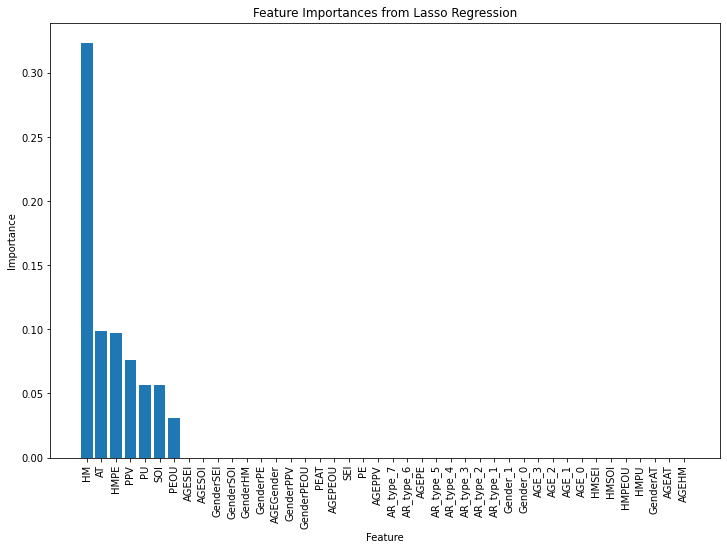

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


 
y = df_survey_cleaned['BI']
X = df_survey_cleaned[['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE',
                       'GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']]


# Create dummy variables for categorical features
X = pd.get_dummies(X, columns=['AGE_num', 'Gender_num','use_type_cnts'], prefix=['AGE', 'Gender','AR_type'])
 

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train the Lasso regression model
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lasso.predict(X_test)

# Calculate the evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R^2 (coefficient of determination): {r2:.3f}")

# Get the feature importances (absolute value of coefficients)
feature_importances = np.abs(lasso.coef_)

# Ensure the feature names list matches the number of features in X
feature_names =  ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGEPEOU',
       'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE', 'GenderHM',
       'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM',
       'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI',
       'HMPE', 'AGE_0', 'AGE_1', 'AGE_2', 'AGE_3', 'Gender_0', 'Gender_1',
       'AR_type_1', 'AR_type_2', 'AR_type_3', 'AR_type_4', 'AR_type_5',
       'AR_type_6', 'AR_type_7']
# Sort the feature importances in descending order
sorted_indices = np.argsort(feature_importances)[::-1]

# Print the most important features
print("Most important features:")
for idx in sorted_indices[:15]:
    feature_name = feature_names[idx]
    feature_importance = float(feature_importances[idx])
    print(f"{feature_name}: {feature_importance:.3f}")

# Plot the feature importances
plt.figure(figsize=(12, 8))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align='center')
plt.xticks(range(len(feature_importances)), [feature_names[i] for i in sorted_indices], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances from Lasso Regression')
plt.show()


In [144]:
# Load libraries
import numpy
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import semopy
from semopy import Model, Optimizer, calc_stats
from pdpbox import pdp, get_dataset, info_plots
from sklearn.metrics import mutual_info_score

In [145]:
y = df_survey_cleaned['BI']
 
X=df_survey_cleaned[['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI','AT','AGE_num','Gender_num','AGEPEOU','AGEGender','GenderPEOU','GenderPPV','GenderPE',
           'GenderHM','GenderSOI','GenderSEI','AGESOI','AGESEI','AGEPPV','PEAT','AGEHM','AGEPE','AGEAT','GenderAT','HMPU','HMPEOU','HMSOI','HMSEI','HMPE']]
 

In [146]:
 
y = df_survey_cleaned['BI']
X = df_survey_cleaned[['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE',
                       'GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']]

# Create dummy variables for categorical features
X = pd.get_dummies(X, columns=['AGE_num', 'Gender_num','use_type_cnts'], prefix=['AGE', 'Gender','AR_type'])

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [148]:
# Define the model
model = LinearRegression()

# Fit the model
model.fit(X_train, y_train)

LinearRegression()

In [149]:
y_pred = model.predict(X_test)

In [150]:
# Calculate performance metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the performance metrics
print(f"R^2: {r2}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")

R^2: 0.8375935422373475
Coefficients: [ 0.00910148  0.15990245  0.03134036  0.3144978   0.18012339  0.37669559
 -0.06371479  0.30362274 -0.0636073  -0.01490887  0.00219055  0.16801878
  0.15805015 -0.26556441  0.00654915 -0.21178115 -0.01045993  0.08266171
 -0.00344743 -0.08155195  0.07249893 -0.08697157  0.02031526  0.09060415
 -0.03871407  0.00772258 -0.09466615  0.02481003  0.15670197  0.01279578
 -0.04037338  0.01643221  0.01114539  0.01433632 -0.01433632  0.06449272
 -0.03547013  0.06167461  0.03610389 -0.00088918  0.10565124 -0.23156316]
Intercept: -0.27910469683006367
Mean Squared Error (MSE): 0.12943300352884596
Root Mean Squared Error (RMSE): 0.3597679856919539
Mean Absolute Error (MAE): 0.2617577910143835


In [151]:
importance = model.coef_

# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort the DataFrame by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Print sorted feature importances
print(feature_importances)

       Feature  Importance
5          SOI    0.376696
3           HM    0.314498
7           AT    0.303623
4         PEOU    0.180123
11   GenderPPV    0.168019
1           PU    0.159902
12    GenderPE    0.158050
28        HMPE    0.156702
40   AR_type_6    0.105651
23    GenderAT    0.090604
17      AGESEI    0.082662
20       AGEHM    0.072499
35   AR_type_1    0.064493
37   AR_type_3    0.061675
38   AR_type_4    0.036104
2           PE    0.031340
27       HMSEI    0.024810
22       AGEAT    0.020315
31       AGE_2    0.016432
33    Gender_0    0.014336
29       AGE_0    0.012796
32       AGE_3    0.011145
0          PPV    0.009101
25      HMPEOU    0.007723
14   GenderSOI    0.006549
10  GenderPEOU    0.002191
39   AR_type_5   -0.000889
18      AGEPPV   -0.003447
16      AGESOI   -0.010460
34    Gender_1   -0.014336
9    AGEGender   -0.014909
36   AR_type_2   -0.035470
24        HMPU   -0.038714
30       AGE_1   -0.040373
8      AGEPEOU   -0.063607
6          SEI   -0.063715
1

### MLP Feature Importance

In [152]:
from sklearn import metrics
import eli5
from eli5.sklearn import PermutationImportance

 
y = df_survey_cleaned['BI']
X = df_survey_cleaned[['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE',
                       'GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']]

# Create dummy variables for categorical features
X = pd.get_dummies(X, columns=['AGE_num', 'Gender_num','use_type_cnts'], prefix=['AGE', 'Gender','AR_type'])

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [154]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [155]:
model = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

MLPRegressor(max_iter=1000, random_state=42)

In [156]:
predicted_y = model.predict(X_test)
print("R^2 Score:", metrics.r2_score(y_test, predicted_y))
print("Mean Squared Log Error:", metrics.mean_squared_log_error(y_test, predicted_y))

R^2 Score: 0.7763418008951709
Mean Squared Log Error: 0.008141342978352395


In [157]:
perm = PermutationImportance(model, random_state=42).fit(X_test, y_test)
eli5.show_weights(perm, feature_names=X.columns.tolist())

Weight,Feature
0.5586 ± 0.1941,HM
0.4083 ± 0.0952,AGEGender
0.3706 ± 0.1254,Gender_0
0.3661 ± 0.0518,GenderHM
0.3084 ± 0.0513,GenderPEOU
0.2777 ± 0.1237,GenderAT
0.2657 ± 0.0852,GenderSOI
0.2329 ± 0.0658,GenderPE
0.2307 ± 0.0882,Gender_1
0.2124 ± 0.0379,GenderPPV


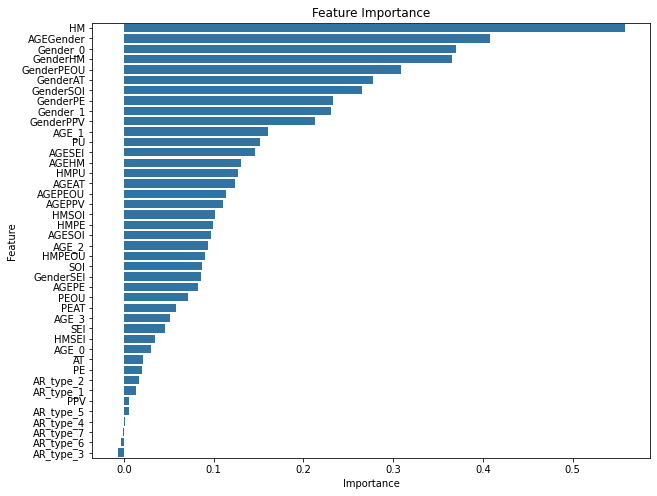

In [158]:
feature_importances = perm.feature_importances_
features = X.columns

# Create a DataFrame for plotting
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.show()

### Random Forest Feature Importance

In [159]:
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

In [160]:
 
y = df_survey_cleaned['BI']
X = df_survey_cleaned[['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE',
                       'GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']]

# Create dummy variables for categorical features
X = pd.get_dummies(X, columns=['AGE_num', 'Gender_num','use_type_cnts'], prefix=['AGE', 'Gender','AR_type'])

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [162]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [163]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [164]:
predicted_y = model.predict(X_test)
print("R^2 Score:", metrics.r2_score(y_test, predicted_y))
print("Mean Squared Error:", metrics.mean_squared_error(y_test, predicted_y))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(y_test, predicted_y)))

R^2 Score: 0.8066604916338758
Mean Squared Error: 0.14488588867187502
Root Mean Squared Error: 0.3806387902879514


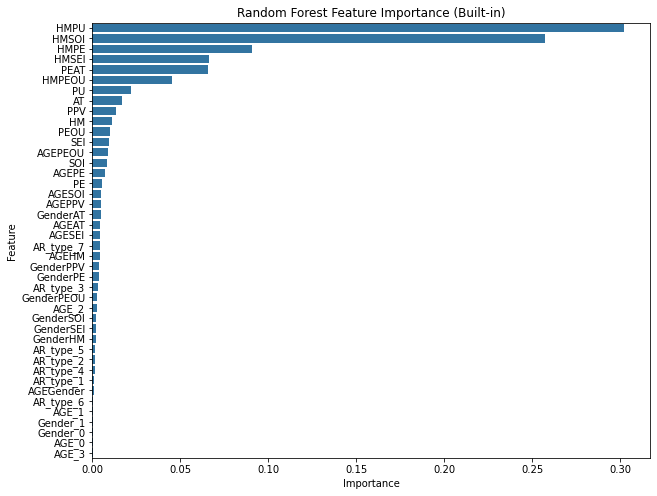

In [165]:
# Using built-in feature importance
feature_importances = model.feature_importances_
features = X.columns

# Create a DataFrame for plotting
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance (Built-in)')
plt.show()

In [166]:
importance_df

,Feature,Importance
24,HMPU,0.302218
26,HMSOI,0.257309
28,HMPE,0.090726
27,HMSEI,0.066400
19,PEAT,0.065540
25,HMPEOU,0.045389
1,PU,0.022189
7,AT,0.016572
0,PPV,0.013501
3,HM,0.011318


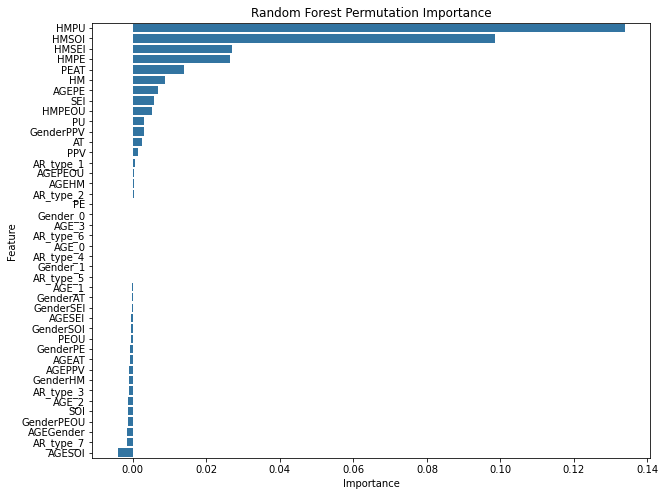

In [167]:
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame for plotting
perm_importance_df = pd.DataFrame({'Feature': features, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df)
plt.title('Random Forest Permutation Importance')
plt.show()

In [168]:
perm_importance_df

,Feature,Importance
24,HMPU,0.133913
26,HMSOI,0.098553
27,HMSEI,0.027019
28,HMPE,0.026502
19,PEAT,0.013941
3,HM,0.008795
21,AGEPE,0.006856
6,SEI,0.005865
25,HMPEOU,0.005261
1,PU,0.003147


### KNN Feature Importance

In [169]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

In [170]:

y = df_survey_cleaned['BI']
X = df_survey_cleaned[['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE',
                       'GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 
                       'PEAT', 'AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']]

# Create dummy variables for categorical features
X = pd.get_dummies(X, columns=['AGE_num', 'Gender_num','use_type_cnts'], prefix=['AGE', 'Gender','AR_type'])

In [171]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [172]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [173]:
model = KNeighborsRegressor(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [174]:
predicted_y = model.predict(X_test)
print("R^2 Score:", metrics.r2_score(y_test, predicted_y))
print("Mean Squared Error:", metrics.mean_squared_error(y_test, predicted_y))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(y_test, predicted_y)))

R^2 Score: 0.7073703226711417
Mean Squared Error: 0.2192925347222222
Root Mean Squared Error: 0.4682868081872713


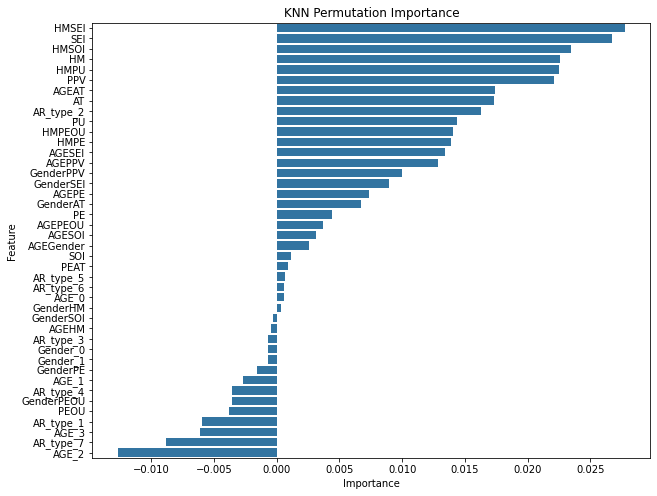

In [175]:
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame for plotting
perm_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df)
plt.title('KNN Permutation Importance')
plt.show()

In [176]:
perm_importance_df

,Feature,Importance
27,HMSEI,0.027764
6,SEI,0.026736
26,HMSOI,0.023442
3,HM,0.022602
24,HMPU,0.022479
0,PPV,0.022096
22,AGEAT,0.017426
7,AT,0.017332
36,AR_type_2,0.016246
1,PU,0.014349


### SVR Feature importance

In [177]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

In [178]:

y = df_survey_cleaned['BI']
X = df_survey_cleaned[['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE',
                       'GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']]

# Create dummy variables for categorical features
X = pd.get_dummies(X, columns=['AGE_num', 'Gender_num','use_type_cnts'], prefix=['AGE', 'Gender','AR_type'])

In [179]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [180]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

In [181]:
model = SVR(kernel='rbf')
model.fit(X_train, y_train)

SVR()

In [182]:
predicted_y = model.predict(X_test)
predicted_y = predicted_y.reshape(-1, 1)  # Reshape to 2D array
predicted_y = scaler_y.inverse_transform(predicted_y)

print("R^2 Score:", metrics.r2_score(y_test, predicted_y))
print("Mean Squared Error:", metrics.mean_squared_error(y_test, predicted_y))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(y_test, predicted_y)))

R^2 Score: -13.936185779477507
Mean Squared Error: 14.610671950201516
Root Mean Squared Error: 3.8223908683180894


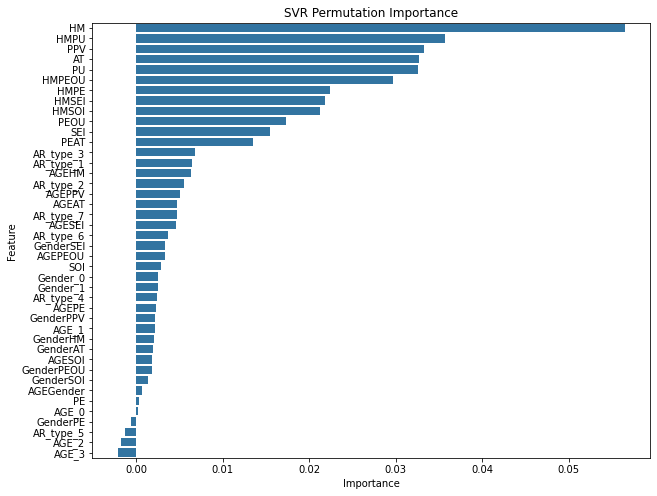

In [183]:
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame for plotting
perm_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df)
plt.title('SVR Permutation Importance')
plt.show()

In [184]:
perm_importance_df

,Feature,Importance
3,HM,0.056532
24,HMPU,0.035749
0,PPV,0.033306
7,AT,0.032712
1,PU,0.032538
25,HMPEOU,0.029727
28,HMPE,0.022403
27,HMSEI,0.021803
26,HMSOI,0.021243
4,PEOU,0.017343


## MLP 

In [186]:
X.columns


Index(['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGEPEOU',
       'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE', 'GenderHM',
       'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM',
       'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI',
       'HMPE', 'AGE_0', 'AGE_1', 'AGE_2', 'AGE_3', 'Gender_0', 'Gender_1',
       'AR_type_1', 'AR_type_2', 'AR_type_3', 'AR_type_4', 'AR_type_5',
       'AR_type_6', 'AR_type_7'],
      dtype='object')

In [ ]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
 
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Create and train the MLP regression model
mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# Make predictions on the test set
y_pred = mlp.predict(X_test)

# Calculate the evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R^2 (coefficient of determination): {r2:.3f}")

# Get the weights of the connections between the input layer and the first hidden layer
coefs = mlp.coefs_[0]

# Get the feature importances
feature_importances = np.abs(coefs).sum(axis=1)

# Get the feature names
#feature_names = ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE',
#                 'GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE', 'use_type_cnts']

feature_names = ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGEPEOU',
       'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE', 'GenderHM',
       'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT', 'AGEHM',
       'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI',
       'HMPE', 'AGE_0', 'AGE_1', 'AGE_2', 'AGE_3', 'Gender_0', 'Gender_1',
       'AR_type_1', 'AR_type_2','AR_type_3', 'AR_type_4', 'AR_type_5',
       'AR_type_6', 'AR_type_7']

# Sort the feature importances in descending order
sorted_indices = np.argsort(feature_importances)[::-1]

# Print the most important features
print("Most important features:")
for idx in sorted_indices[:10]:
    feature_name = feature_names[idx]
    feature_importance = float(feature_importances[idx])
    print(f"{feature_name}: {feature_importance:.3f}")

## Build Test Harness

In [188]:
Y = y 
X  

,PPV,PU,PE,HM,PEOU,SOI,SEI,AT,AGEPEOU,AGEGender,...,AGE_3,Gender_0,Gender_1,AR_type_1,AR_type_2,AR_type_3,AR_type_4,AR_type_5,AR_type_6,AR_type_7
0,4.000000,3.25,4.00,3.00,4.000000,3.00,3.000000,3.666667,12.000000,0,...,1,1,0,0,1,0,0,0,0,0
1,3.000000,3.00,3.00,2.25,3.000000,3.00,3.000000,3.000000,3.000000,1,...,0,0,1,1,0,0,0,0,0,0
2,4.000000,4.00,4.00,3.00,4.000000,4.00,4.000000,4.000000,12.000000,0,...,1,1,0,0,1,0,0,0,0,0
3,4.000000,4.00,4.50,3.75,4.000000,3.75,2.333333,4.000000,4.000000,0,...,0,1,0,0,1,0,0,0,0,0
4,4.000000,3.50,3.00,3.00,4.000000,3.25,3.000000,4.000000,4.000000,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,4.333333,4.75,4.50,3.75,4.333333,4.75,4.666667,5.000000,13.000000,3,...,1,0,1,0,0,0,0,0,0,1
420,4.333333,4.25,4.25,3.50,4.666667,4.75,5.000000,4.333333,14.000000,3,...,1,0,1,0,0,0,1,0,0,0
421,4.666667,4.50,4.00,3.50,3.666667,4.25,5.000000,4.333333,11.000000,3,...,1,0,1,0,1,0,0,0,0,0
422,4.666667,4.50,4.00,3.50,3.666667,4.25,5.000000,4.333333,11.000000,3,...,1,0,1,0,1,0,0,0,0,0


In [189]:
X

,PPV,PU,PE,HM,PEOU,SOI,SEI,AT,AGEPEOU,AGEGender,...,AGE_3,Gender_0,Gender_1,AR_type_1,AR_type_2,AR_type_3,AR_type_4,AR_type_5,AR_type_6,AR_type_7
0,4.000000,3.25,4.00,3.00,4.000000,3.00,3.000000,3.666667,12.000000,0,...,1,1,0,0,1,0,0,0,0,0
1,3.000000,3.00,3.00,2.25,3.000000,3.00,3.000000,3.000000,3.000000,1,...,0,0,1,1,0,0,0,0,0,0
2,4.000000,4.00,4.00,3.00,4.000000,4.00,4.000000,4.000000,12.000000,0,...,1,1,0,0,1,0,0,0,0,0
3,4.000000,4.00,4.50,3.75,4.000000,3.75,2.333333,4.000000,4.000000,0,...,0,1,0,0,1,0,0,0,0,0
4,4.000000,3.50,3.00,3.00,4.000000,3.25,3.000000,4.000000,4.000000,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,4.333333,4.75,4.50,3.75,4.333333,4.75,4.666667,5.000000,13.000000,3,...,1,0,1,0,0,0,0,0,0,1
420,4.333333,4.25,4.25,3.50,4.666667,4.75,5.000000,4.333333,14.000000,3,...,1,0,1,0,0,0,1,0,0,0
421,4.666667,4.50,4.00,3.50,3.666667,4.25,5.000000,4.333333,11.000000,3,...,1,0,1,0,1,0,0,0,0,0
422,4.666667,4.50,4.00,3.50,3.666667,4.25,5.000000,4.333333,11.000000,3,...,1,0,1,0,1,0,0,0,0,0


LR: 0.751550 (0.087674)
LASSO: 0.758122 (0.087839)
EN: 0.739080 (0.080808)
KNN: 0.744566 (0.076300)
CART: 0.623578 (0.121640)
RF: 0.791681 (0.077196)
SVR: 0.786051 (0.075943)
MLP: 0.721059 (0.120991)


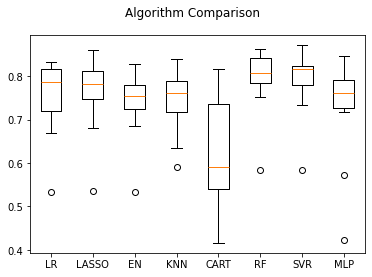

In [190]:
 # prepare models
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso(alpha=0.1)))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('RF',RandomForestRegressor()))
models.append(('SVR', SVR()))  # Remove gamma='auto' for SVR
models.append(('MLP', MLPRegressor(hidden_layer_sizes=(100), activation='relu', solver='adam',
                                   alpha=0.0001, batch_size='auto', learning_rate='constant',
                                   learning_rate_init=0.001, max_iter=1000, random_state=42)))

# evaluate each model in turn
results = []
names = []
scoring = 'r2'  # Change scoring metric to 'r2' for regression problems
for name, model in models:
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)  # Use lowercase 'y' for target variable
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# boxplot algorithm comparison
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)

pyplot.show()

In [191]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [192]:

# Train the MLP model
mlp = MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)


In [193]:
X_train

,PPV,PU,PE,HM,PEOU,SOI,SEI,AT,AGEPEOU,AGEGender,...,AGE_3,Gender_0,Gender_1,AR_type_1,AR_type_2,AR_type_3,AR_type_4,AR_type_5,AR_type_6,AR_type_7
131,4.333333,4.25,4.50,3.25,4.333333,4.75,4.666667,5.000000,4.333333,0,...,0,1,0,0,0,1,0,0,0,0
31,2.666667,3.75,4.00,3.50,4.000000,3.00,3.000000,2.333333,8.000000,0,...,0,1,0,0,0,0,0,0,1,0
84,3.666667,4.75,1.50,3.50,3.666667,3.50,4.000000,3.666667,0.000000,0,...,0,1,0,0,0,1,0,0,0,0
290,4.000000,3.25,4.00,2.75,4.000000,3.75,4.000000,3.666667,12.000000,3,...,1,0,1,1,0,0,0,0,0,0
375,1.000000,1.00,1.00,0.75,1.000000,1.00,1.000000,1.000000,3.000000,3,...,1,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,4.000000,4.00,4.00,3.00,4.000000,4.75,5.000000,4.000000,12.000000,0,...,1,1,0,0,0,0,1,0,0,0
106,3.000000,3.00,3.25,2.25,3.000000,3.50,4.000000,3.000000,3.000000,0,...,0,1,0,0,0,0,0,0,0,1
270,3.666667,4.25,4.75,3.50,4.333333,4.25,4.000000,4.666667,13.000000,3,...,1,0,1,0,1,0,0,0,0,0
348,4.000000,4.00,4.00,3.00,4.000000,4.00,4.000000,4.000000,12.000000,3,...,1,0,1,0,0,0,0,0,1,0


In [194]:
mlp.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

## Cluster Analysis

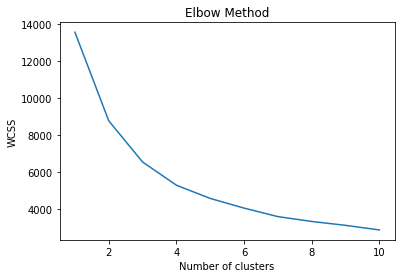

In [195]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
 
# Select the features
#features = ['BI', 'PEOU', 'PE', 'PU', 'SOI', 'SEI', 'HM', 'PE', 'AGE_num', 'Gender_num', 'AT','use_type_cnts']
features = ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 'GenderPEOU', 'GenderPPV', 'GenderPE',
                       'GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 'PEAT',
            'AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']


X = df_survey_cleaned[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters (optional)

from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
     kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
     kmeans.fit(X_scaled)
     wcss.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [196]:


# Set the number of clusters
n_clusters = 3  # Change this value based on your analysis or requirements

# Initialize and fit the K-Means model
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
kmeans.fit(X_scaled)

# Get the cluster labels
labels = kmeans.labels_

# Add the cluster labels to the original dataset
df_survey_cleaned['cluster'] = labels

# Print the first few rows of the dataset with cluster labels
df_survey_cleaned.head(1)

# Add cluster labels to the dataframe
df_survey_cleaned['Cluster'] = labels


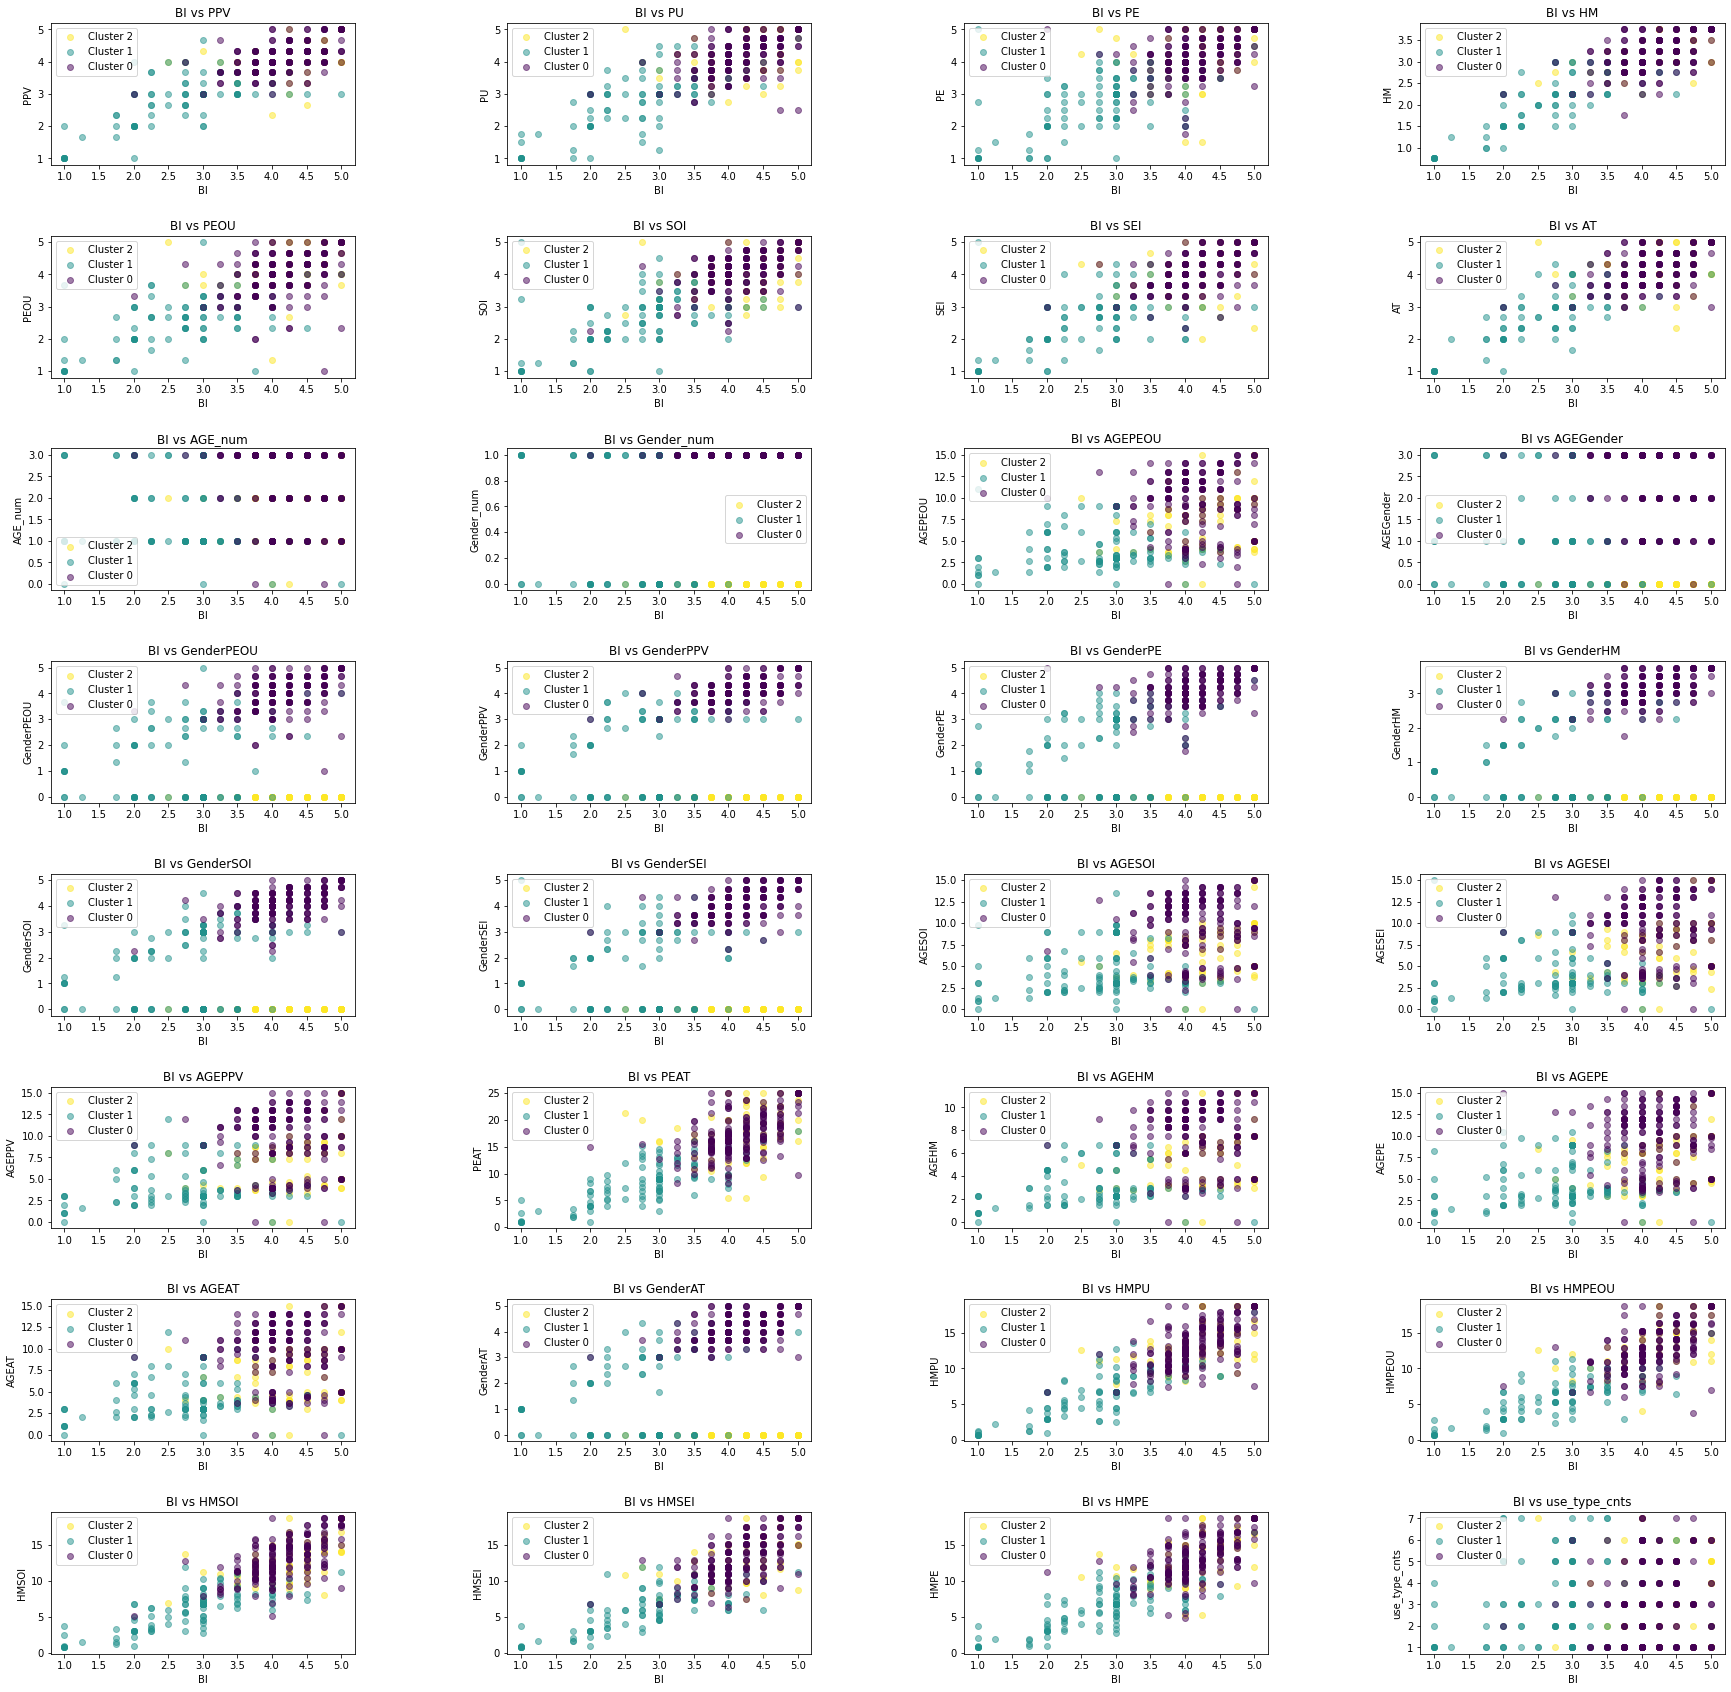

In [197]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba

# Assuming df_survey_cleaned is already defined and loaded with data

# List of features to plot against 'BI'
features = ['PPV', 'PU', 'PE', 'HM', 'PEOU', 'SOI', 'SEI', 'AT', 'AGE_num', 'Gender_num', 'AGEPEOU', 'AGEGender', 
            'GenderPEOU', 'GenderPPV', 'GenderPE','GenderHM', 'GenderSOI', 'GenderSEI', 'AGESOI', 'AGESEI', 'AGEPPV', 
            'PEAT','AGEHM', 'AGEPE', 'AGEAT', 'GenderAT', 'HMPU', 'HMPEOU', 'HMSOI', 'HMSEI', 'HMPE','use_type_cnts']

# Define colors for clusters
num_clusters = df_survey_cleaned['Cluster'].nunique()
cmap = plt.cm.viridis  # Corrected line

# Create a figure with subplots
nrows = 8  # Number of rows
ncols = 4  # Number of columns
fig, axs = plt.subplots(nrows, ncols, figsize=(30, 30))
axs = axs.ravel()  # Flatten the subplot array

# Plot 'BI' against each feature
for i, feature in enumerate(features):
    ax = axs[i]
    for cluster in df_survey_cleaned['Cluster'].unique():
        cluster_data = df_survey_cleaned[df_survey_cleaned['Cluster'] == cluster]
        color = to_rgba(cmap(cluster / (num_clusters - 1)))
        ax.scatter(cluster_data['BI'], cluster_data[feature], color=color, label=f'Cluster {cluster}', alpha=0.5)
    ax.set_title(f'BI vs {feature}')
    ax.set_xlabel('BI')
    ax.set_ylabel(feature)
    ax.legend()

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.5, wspace=0.5)

# Display the plot
plt.show()

In [198]:
df_survey_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 424 entries, 0 to 522
Data columns (total 97 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     424 non-null    object 
 1   AR_Knowledgeable              424 non-null    float64
 2   familiar_with_technology      424 non-null    float64
 3   use_AR_everyday               424 non-null    float64
 4   use_in_all_aspects            424 non-null    object 
 5   Virtual_shopping_environment  424 non-null    float64
 6   Virtual_tour                  424 non-null    float64
 7   Visualize_model               424 non-null    float64
 8   Emulation                     424 non-null    float64
 9   PE1                           424 non-null    float64
 10  PE2                           424 non-null    float64
 11  PE3                           424 non-null    float64
 12  PE4                           424 non-null    float64
 13  SOI1 

In [199]:
df_survey_cleaned['AGE_num'] = df_survey_cleaned['AGE_num'].astype('int64')

In [200]:
df_survey_cleaned[['PEOU', 'PE', 'PU', 'SOI', 'SEI', 'HM', 'PE', 'AGE_num', 'Gender_num', 'AT', 'use_type_cnts', 'cluster']]

,PEOU,PE,PU,SOI,SEI,HM,PE,AGE_num,Gender_num,AT,use_type_cnts,cluster
0,4.000000,4.00,3.25,3.00,3.000000,3.00,4.00,3,0,3.666667,2,2
1,3.000000,3.00,3.00,3.00,3.000000,2.25,3.00,1,1,3.000000,1,1
2,4.000000,4.00,4.00,4.00,4.000000,3.00,4.00,3,0,4.000000,2,2
3,4.000000,4.50,4.00,3.75,2.333333,3.75,4.50,1,0,4.000000,2,2
4,4.000000,3.00,3.50,3.25,3.000000,3.00,3.00,1,0,4.000000,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...
419,4.333333,4.50,4.75,4.75,4.666667,3.75,4.50,3,1,5.000000,7,0
420,4.666667,4.25,4.25,4.75,5.000000,3.50,4.25,3,1,4.333333,4,0
421,3.666667,4.00,4.50,4.25,5.000000,3.50,4.00,3,1,4.333333,2,0
422,3.666667,4.00,4.50,4.25,5.000000,3.50,4.00,3,1,4.333333,2,0


In [201]:
df_survey_cleaned[['PEOU', 'PE', 'PU', 'SOI', 'SEI', 'HM', 'PE', 'AGE_num', 'Gender_num', 'AT', 'use_type_cnts','cluster']]

,PEOU,PE,PU,SOI,SEI,HM,PE,AGE_num,Gender_num,AT,use_type_cnts,cluster
0,4.000000,4.00,3.25,3.00,3.000000,3.00,4.00,3,0,3.666667,2,2
1,3.000000,3.00,3.00,3.00,3.000000,2.25,3.00,1,1,3.000000,1,1
2,4.000000,4.00,4.00,4.00,4.000000,3.00,4.00,3,0,4.000000,2,2
3,4.000000,4.50,4.00,3.75,2.333333,3.75,4.50,1,0,4.000000,2,2
4,4.000000,3.00,3.50,3.25,3.000000,3.00,3.00,1,0,4.000000,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...
419,4.333333,4.50,4.75,4.75,4.666667,3.75,4.50,3,1,5.000000,7,0
420,4.666667,4.25,4.25,4.75,5.000000,3.50,4.25,3,1,4.333333,4,0
421,3.666667,4.00,4.50,4.25,5.000000,3.50,4.00,3,1,4.333333,2,0
422,3.666667,4.00,4.50,4.25,5.000000,3.50,4.00,3,1,4.333333,2,0


In [202]:
df_survey_cluster0 = df_survey_cleaned[df_survey_cleaned['cluster'] == 0]

In [203]:
df_survey_cluster1 = df_survey_cleaned[df_survey_cleaned['cluster'] == 1]

In [204]:
df_survey_cluster2 = df_survey_cleaned[df_survey_cleaned['cluster'] == 2]

In [205]:
df_survey_cluster3 = df_survey_cleaned[df_survey_cleaned['cluster'] == 3]

In [206]:
df_survey_cluster0[['BI','PEOU', 'PE', 'PU', 'SOI', 'SEI', 'HM', 'PE', 'AGE_num', 'Gender_num', 'AT', 'use_type_cnts','cluster']].describe()

,BI,PEOU,PE,PU,SOI,SEI,HM,PE,AGE_num,Gender_num,AT,use_type_cnts,cluster
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.0,215.000000,215.000000,215.0
mean,4.161628,4.044961,4.172093,4.180233,4.127907,4.116279,3.180233,4.172093,2.460465,1.0,4.159690,2.944186,0.0
std,0.467749,0.633558,0.577044,0.530951,0.528874,0.542502,0.393899,0.577044,0.789576,0.0,0.517430,1.851156,0.0
min,2.000000,1.000000,1.750000,2.500000,2.250000,2.333333,1.750000,1.750000,0.000000,1.0,3.000000,1.000000,0.0
25%,4.000000,3.666667,4.000000,4.000000,4.000000,3.666667,3.000000,4.000000,2.000000,1.0,3.666667,1.000000,0.0
50%,4.000000,4.000000,4.250000,4.250000,4.250000,4.000000,3.250000,4.250000,3.000000,1.0,4.000000,3.000000,0.0
75%,4.500000,4.333333,4.500000,4.500000,4.500000,4.666667,3.500000,4.500000,3.000000,1.0,4.666667,4.000000,0.0
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.750000,5.000000,3.000000,1.0,5.000000,7.000000,0.0


In [207]:
df_survey_cluster1[['BI','PEOU', 'PE', 'PU', 'SOI', 'SEI', 'HM', 'PE', 'AGE_num', 'Gender_num', 'AT', 'use_type_cnts','cluster']].describe()

,BI,PEOU,PE,PU,SOI,SEI,HM,PE,AGE_num,Gender_num,AT,use_type_cnts,cluster
count,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.0
mean,2.822581,2.717742,2.790323,2.877016,2.721774,2.733871,2.163306,2.790323,1.637097,0.645161,2.911290,3.306452,1.0
std,0.801278,0.746015,0.845473,0.816805,0.767221,0.789474,0.622286,0.845473,0.922481,0.480405,0.835211,2.000721,0.0
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.750000,1.000000,0.000000,0.000000,1.000000,1.000000,1.0
25%,2.250000,2.333333,2.250000,2.687500,2.250000,2.333333,2.000000,2.250000,1.000000,0.000000,2.583333,1.000000,1.0
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.250000,3.000000,1.000000,1.000000,3.000000,3.000000,1.0
75%,3.000000,3.000000,3.250000,3.250000,3.000000,3.000000,2.500000,3.250000,3.000000,1.000000,3.333333,5.000000,1.0
max,5.000000,5.000000,5.000000,4.750000,5.000000,5.000000,3.750000,5.000000,3.000000,1.000000,5.000000,7.000000,1.0


In [208]:
Based on the summary statistics provided, this cluster represents a group of respondents with the following characteristics:

## Behavioral Intention (BI), Perceived Ease of Use (PEOU), and Perceived Usefulness (PU)
- Very low mean scores for BI (1.917), PEOU (1.929), and PU (1.909), indicating a strongly negative perception of the technology's usefulness and ease of use, leading to low behavioral intention to use it.[1][2]

## Social Influence (SOI) and Self-Efficacy (SEI)  
- Low mean scores for SOI (1.848) and SEI (1.848), suggesting that social influence and self-efficacy had a minimal positive impact on the respondents' intentions.

## Hedonic Motivation (HM)
- Extremely low mean HM score of 1.424, indicating a lack of enjoyment or hedonic motivation derived from using the technology.

## Age and Gender
- Mean age of 1.727 (on a scale of 0-3), suggesting a relatively younger age group.
- Mean gender score of 0.485 (on a scale of 0-1), indicating a higher proportion of male respondents.

## Attitude Toward Technology (AT)
- Low mean AT score of 1.949, reflecting a generally negative attitude towards technology among the respondents.

In summary, this cluster represents a group of relatively young, predominantly male users who have a positive perception of the system's usefulness, ease of use, and social influence, and are likely to have a high intention to use the system for various tasks..[1][2]


SyntaxError: invalid syntax (3768069048.py, line 1)

In [ ]:
df_survey_cluster2[['BI','PEOU', 'PE', 'PU', 'SOI', 'SEI', 'HM', 'PE', 'AGE_num', 'Gender_num', 'AT','use_type_cnts', 'cluster']].describe()

In [212]:
Based on the summary statistics provided, this cluster represents a group of respondents with the following characteristics:

## Behavioral Intention (BI)
- Mean BI score of 3.362, indicating a moderately positive behavioral intention towards the technology or system being evaluated.

## Perceived Ease of Use (PEOU) and Perceived Usefulness (PU)
- Mean PEOU score of 3.135 and mean PU score of 3.342, suggesting that the respondents generally found the technology moderately easy to use and moderately useful.

## Social Influence (SOI) and Self-Efficacy (SEI)
- Mean SOI score of 3.170 and mean SEI score of 3.178, implying that social influence and self-efficacy had a moderate positive impact on the respondents' intentions.

## Hedonic Motivation (HM)
- Mean HM score of 2.605, indicating a relatively lower level of hedonic motivation or enjoyment derived from using the technology.

## Age and Gender
- Mean age of 1.855 (on a scale of 0-3), suggesting a relatively younger age group.
- Mean gender score of 0.659 (on a scale of 0-1), indicating a slightly higher proportion of male respondents.

## Attitude Toward Technology (AT)
- Mean AT score of 3.413, reflecting a moderately positive attitude towards technology among the respondents.

Overall, this cluster represents a group of respondents who have a moderately positive attitude towards the technology being evaluated, finding it reasonably easy to use and useful, with moderate social influence and self-efficacy playing a role in their intentions. However, they seem to derive relatively lower hedonic motivation or enjoyment from using the technology. The cluster appears to consist of a slightly younger age group with a slightly higher proportion of male respondents.[1]


    

SyntaxError: invalid syntax (784526673.py, line 1)

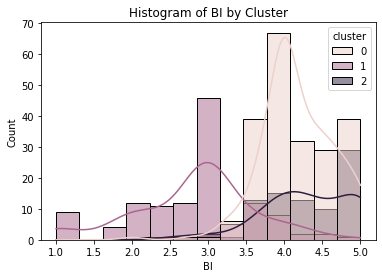

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called 'df'
sns.histplot(data=df_survey_cleaned, x='BI', hue='cluster', kde=True)
plt.title('Histogram of BI by Cluster')
plt.xlabel('BI')
plt.ylabel('Count')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you have already defined df_survey_cluster0, df_survey_cluster1, df_survey_cluster2

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Plot histogram for cluster 0
sns.histplot(df_survey_cluster0['BI'], ax=axes[0], kde=True)
axes[0].set_title('Cluster 0')

# Plot histogram for cluster 1 
sns.histplot(df_survey_cluster1['BI'], ax=axes[1], kde=True)  
axes[1].set_title('Cluster 1')

# Plot histogram for cluster 2
sns.histplot(df_survey_cluster2['BI'], ax=axes[2], kde=True)
axes[2].set_title('Cluster 2')

# Adjust layout
fig.subplots_adjust(wspace=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features
features = ['AR_Knowledgeable','familiar_with_technology', 'use_AR_everyday','use_in_all_aspects',
            'Virtual_shopping_environment', 
            'Virtual_tour', 'Visualize_model', 'Emulation']

# Create a figure with a 4x3 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))

# Flatten the axes array
axes = axes.flatten()

# Create a bar plot for each feature
for i, feature in enumerate(features):
    sns.countplot(data=df_survey, x=feature, ax=axes[i])
    axes[i].set_title(feature, fontsize=14)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Adjust spacing between subplots
plt.subplots_adjust(hspace= .5, wspace= .5)

# Display the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features
features = ['AR_Knowledgeable','familiar_with_technology', 'use_AR_everyday','use_in_all_aspects',
            'Virtual_shopping_environment', 
            'Virtual_tour', 'Visualize_model', 'Emulation']

# Create a figure with a 4x3 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))

# Flatten the axes array
axes = axes.flatten()

# Create a bar plot for each feature
for i, feature in enumerate(features):
    sns.countplot(data=df_survey, x=feature, ax=axes[i])
    axes[i].set_title(feature, fontsize=14)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Adjust spacing between subplots
plt.subplots_adjust(hspace= .5, wspace= .5)

# Display the plot
plt.show()

### Chi ^2 Analysis

In [ ]:
contingency_table

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df_survey_cleaned['AGE'], df_survey_cleaned['Gender'])

# Perform the Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results
print("Chi-square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies Table:")
print(expected)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

# Load your dataset
# df = pd.read_csv('your_dataset.csv')

# Assuming 'target' is the column name for the target variable
X = df.drop(columns=['target'])
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'MLR': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'RF': RandomForestRegressor(),
    'SVR': SVR(),
    'MLP': MLPRegressor(max_iter=1000),
    'DecisionTree': DecisionTreeRegressor()
}

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'{name} Mean Squared Error: {mse}')

# Feature importance from Random Forest
rf = models['RF']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# Decision Tree visualization
dt = models['DecisionTree']
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.show()

# Polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Residual plot for Linear Regression
mlr = models['MLR']
y_train_pred = mlr.predict(X_train)
y_test_pred = mlr.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_train_pred, y_train_pred - y_train, c='blue', marker='o', label='Training data')
plt.scatter(y_test_pred, y_test_pred - y_test, c='lightgreen', marker='s', label='Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=min(y_train_pred), xmax=max(y_train_pred), color='red')
plt.title("Residual Plot")
plt.show()

## Model training, ealuation and hyperprameter tuning

Best KNN parameters: {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Mean Squared Error: 0.13015337297218446
R-squared Score: 0.8145387432440336


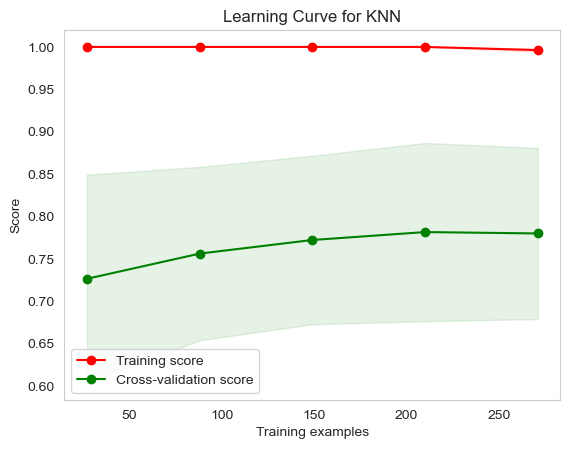

Best RF parameters: {'max_depth': 25, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 215}
Mean Squared Error: 0.1218912051887493
R-squared Score: 0.8263118689468306


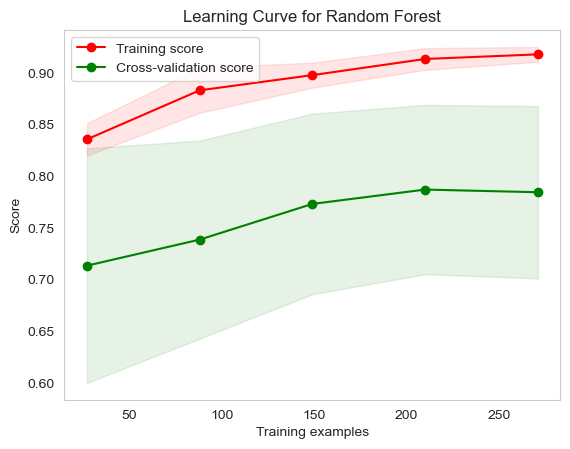

Best MLP parameters: {'activation': 'tanh', 'alpha': 0.03864165025399162, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant'}
Mean Squared Error: 0.10306227123636637
R-squared Score: 0.8531420437970076


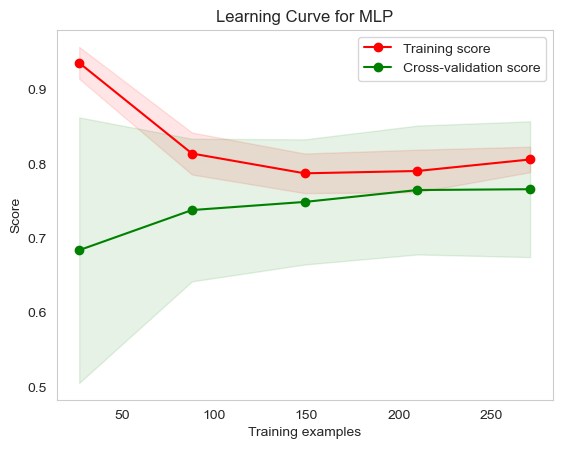

Best SVR parameters: {'C': 29.9751452913768, 'epsilon': 0.17122128725400443, 'kernel': 'linear'}
Mean Squared Error: 0.10983446664976224
R-squared Score: 0.8434920451555294


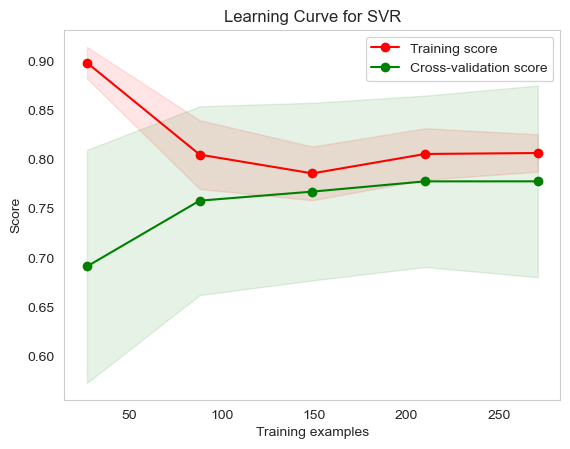

Mean Squared Error: 0.10914629895951503
R-squared Score: 0.8444726455178373


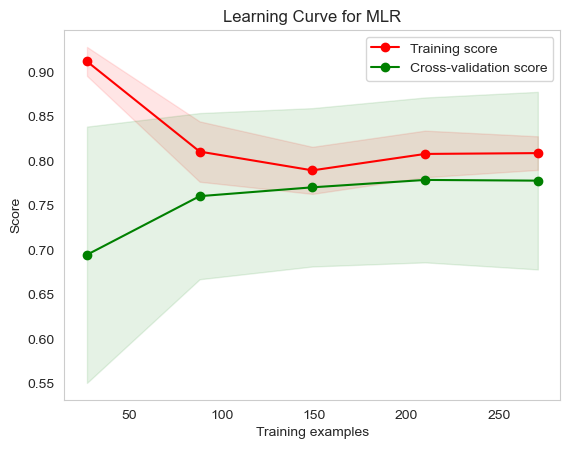

           Model  Mean MSE   Std MSE
0            KNN  0.163465  0.056930
1  Random Forest  0.163166  0.052499
2            MLP  0.174313  0.059122
3            SVR  0.167310  0.062176
4            MLR  0.167326  0.062969


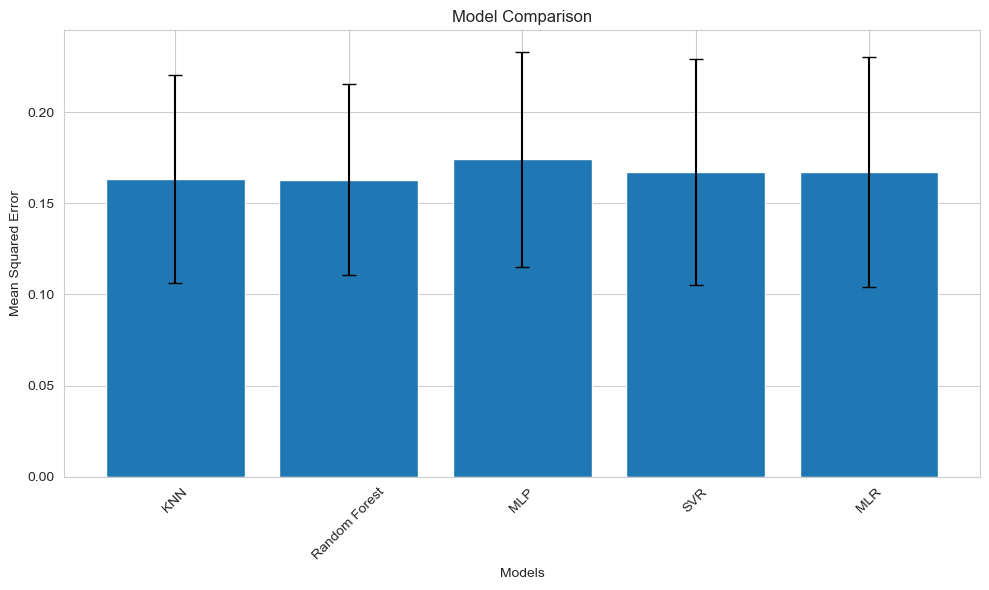

In [199]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint

# Assuming you have your data in a DataFrame called 'df'
# with features in X and target variable in y
variables = ['PE', 'PU', 'PEOU', 'SEI', 'SOI', 'HM', 'AT', 'PPV', 'BI']
X = df[['PE', 'PU', 'PEOU','SEI', 'SOI', 'HM', 'AT', 'PPV']]
y = df['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to plot learning curves
def plot_learning_curve(estimator, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_train_scaled, y_train, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5))
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

# Function to evaluate and print model performance
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Squared Error: {mse}")
    print(f"R-squared Score: {r2}")

# KNN
knn_params = {'n_neighbors': randint(1, 20), 'weights': ['uniform', 'distance'],'p': [1, 2]}

knn = RandomizedSearchCV(KNeighborsRegressor(), knn_params, n_iter=100, cv=5, random_state=42)
knn.fit(X_train_scaled, y_train)
print("Best KNN parameters:", knn.best_params_)
evaluate_model(knn.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test)
plot_learning_curve(knn.best_estimator_, "Learning Curve for KNN")

# Random Forest
rf_params = {'n_estimators': randint(100, 500), 'max_depth': randint(5, 30), 'min_samples_split': randint(2, 20),'min_samples_leaf': randint(1, 10)
}
rf = RandomizedSearchCV(RandomForestRegressor(), rf_params, n_iter=100, cv=5, random_state=42)
rf.fit(X_train_scaled, y_train)
print("Best RF parameters:", rf.best_params_)
evaluate_model(rf.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test)
plot_learning_curve(rf.best_estimator_, "Learning Curve for Random Forest")

# MLP
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': uniform(0.0001, 0.1),
    'learning_rate': ['constant', 'adaptive']
}
mlp = RandomizedSearchCV(MLPRegressor(max_iter=1000), mlp_params, n_iter=100, cv=5, random_state=42)
mlp.fit(X_train_scaled, y_train)
print("Best MLP parameters:", mlp.best_params_)
evaluate_model(mlp.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test)
plot_learning_curve(mlp.best_estimator_, "Learning Curve for MLP")

# SVR
svr_params = {'C': uniform(1, 100),'epsilon': uniform(0.01, 1),'kernel': ['rbf', 'linear']}

svr = RandomizedSearchCV(SVR(), svr_params, n_iter=100, cv=5, random_state=42)
svr.fit(X_train_scaled, y_train)
print("Best SVR parameters:", svr.best_params_)
evaluate_model(svr.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test)
plot_learning_curve(svr.best_estimator_, "Learning Curve for SVR")

# MLR (Linear Regression)
mlr = LinearRegression()
evaluate_model(mlr, X_train_scaled, X_test_scaled, y_train, y_test)
plot_learning_curve(mlr, "Learning Curve for MLR")

# Compare models
models = {
    'KNN': knn.best_estimator_,
    'Random Forest': rf.best_estimator_,
    'MLP': mlp.best_estimator_,
    'SVR': svr.best_estimator_,
    'MLR': mlr
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    mse_scores = -cv_scores
    results.append({
        'Model': name,
        'Mean MSE': np.mean(mse_scores),
        'Std MSE': np.std(mse_scores)
    })

results_df = pd.DataFrame(results)
print(results_df)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['Mean MSE'], yerr=results_df['Std MSE'], capsize=5)
plt.title('Model Comparison')
plt.xlabel('Models')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Model evaluation

C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\cemcd\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


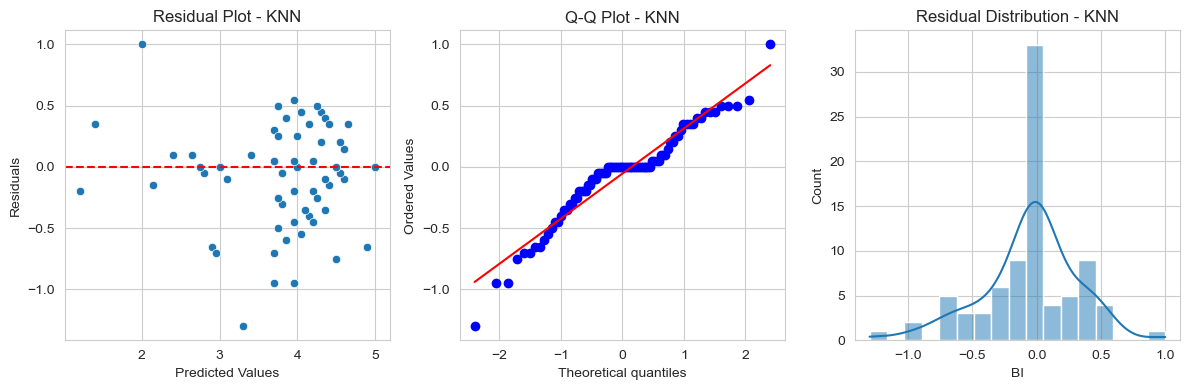

C:\Users\cemcd\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


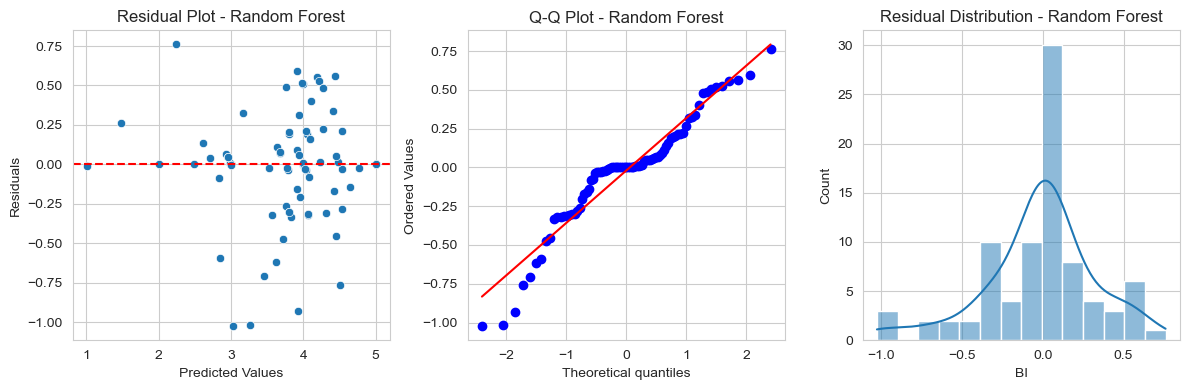

C:\Users\cemcd\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


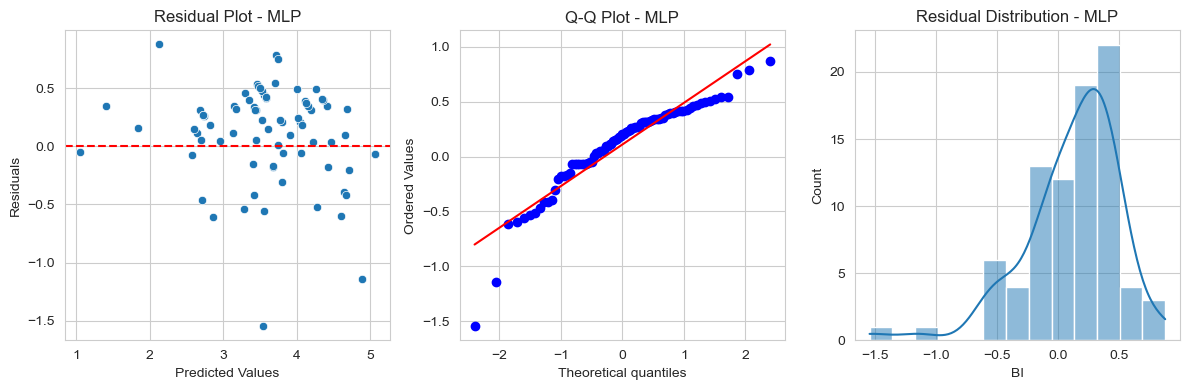

C:\Users\cemcd\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


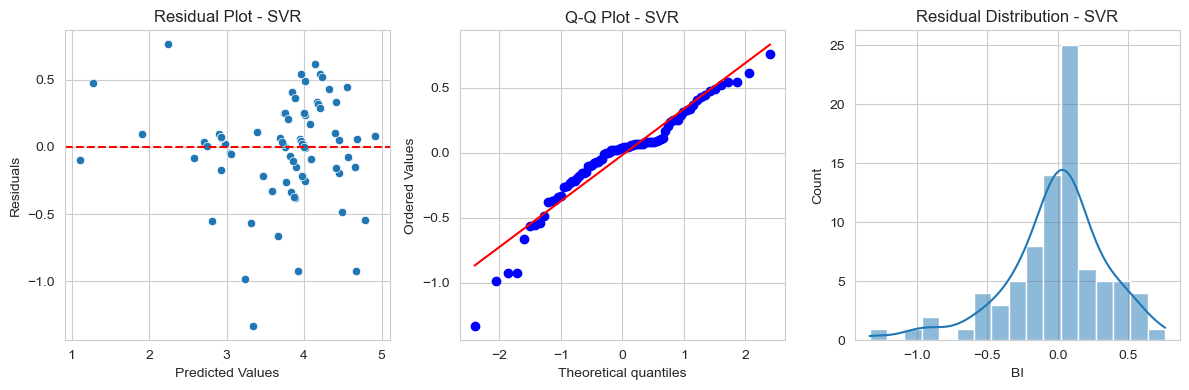

C:\Users\cemcd\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


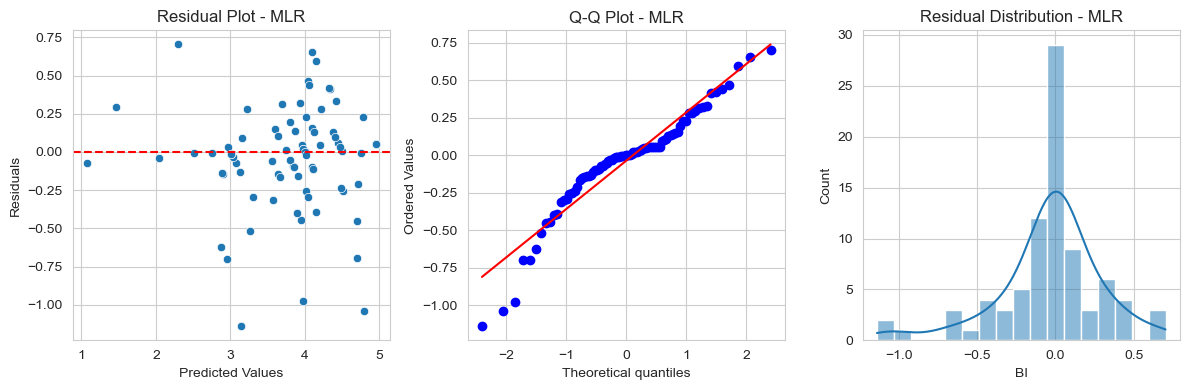

In [201]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression

# Assuming you have your data in X and y
# X = df.drop('target_column', axis=1)
# y = df['target_column']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
knn_model = KNeighborsRegressor().fit(X_train_scaled, y_train)
rf_model = RandomForestRegressor(random_state=42).fit(X_train_scaled, y_train)
mlp_model = MLPRegressor(random_state=42).fit(X_train_scaled, y_train)
svr_model = SVR().fit(X_train_scaled, y_train)
mlr_model = LinearRegression().fit(X_train_scaled, y_train)

def plot_residuals(model, X, y, title):
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    plt.figure(figsize=(12, 4))
    
    # Residual plot
    plt.subplot(131)
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residual Plot - {title}')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    
    # Q-Q plot
    plt.subplot(132)
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot - {title}')
    
    # Residual histogram
    plt.subplot(133)
    sns.histplot(residuals, kde=True)
    plt.title(f'Residual Distribution - {title}')
    
    plt.tight_layout()
    plt.show()

# Now we can use this function for each model
plot_residuals(knn_model, X_test_scaled, y_test, "KNN")
plot_residuals(rf_model, X_test_scaled, y_test, "Random Forest")
plot_residuals(mlp_model, X_test_scaled, y_test, "MLP")
plot_residuals(svr_model, X_test_scaled, y_test, "SVR")
plot_residuals(mlr_model, X_test_scaled, y_test, "MLR")

C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

Descriptive Statistics:
                           count      mean       std       min       25%  \
Metric              Model                                                  
mean_absolute_error KNN      5.0  0.286756  0.040981  0.247647  0.262353   
                    MLP      5.0  0.322071  0.041999  0.266080  0.287715   
                    MLR      5.0  0.275804  0.044516  0.213821  0.268227   
                    RF       5.0  0.268421  0.041147  0.211259  0.245000   
                    SVR      5.0  0.296073  0.038795  0.257905  0.265406   
mean_squared_error  KNN      5.0  0.183666  0.051744  0.116941  0.149971   
                    MLP      5.0  0.191457  0.055522  0.128314  0.137455   
                    MLR      5.0  0.159976  0.042654  0.125314  0.126256   
                    RF       5.0  0.160381  0.041697  0.126732  0.127318   
                    SVR      5.0  0.188373  0.059091  0.121797  0.145316   
r2                  KNN      5.0  0.732199  0.063228  0.625778  

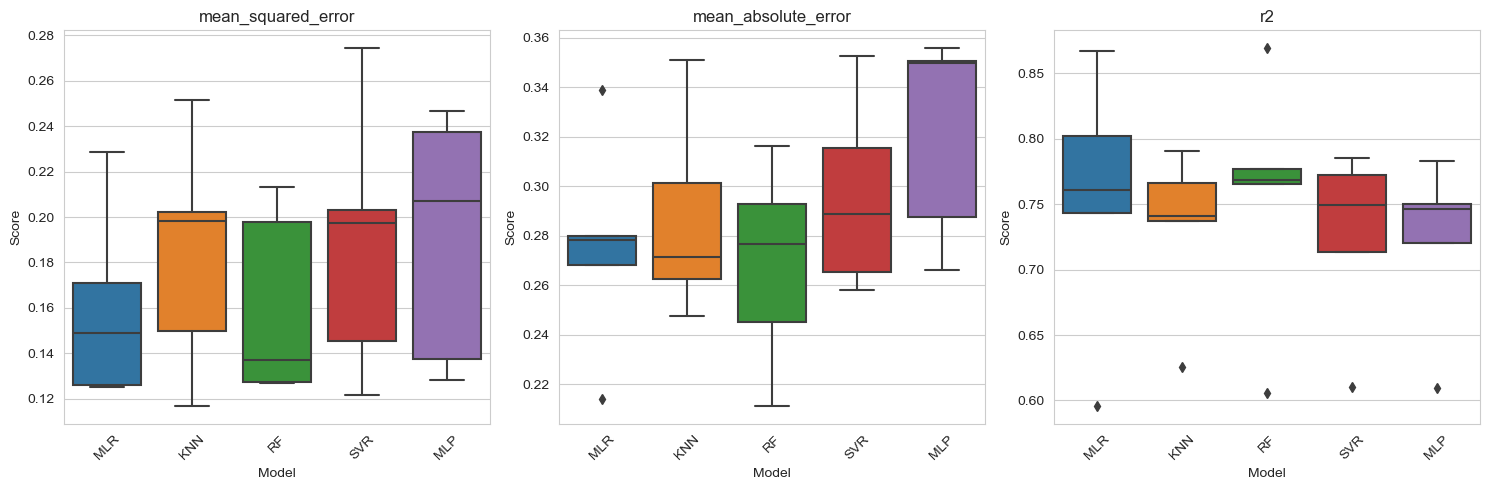


Correlation between metrics:
Metric               mean_absolute_error  mean_squared_error        r2
Metric                                                                
mean_absolute_error             1.000000            0.864200 -0.890572
mean_squared_error              0.864200            1.000000 -0.995863
r2                             -0.890572           -0.995863  1.000000

Sensitivity Analysis for Random Forest:
    n_estimators  max_depth  mean_score  std_score
0             10        NaN    0.731138   0.104128
1             10       10.0    0.737584   0.086999
2             10       20.0    0.740182   0.105253
3             10       30.0    0.711306   0.109300
4             50        NaN    0.754896   0.080406
5             50       10.0    0.758677   0.083306
6             50       20.0    0.761510   0.083765
7             50       30.0    0.754280   0.088139
8            100        NaN    0.758995   0.085918
9            100       10.0    0.761436   0.085263
10           

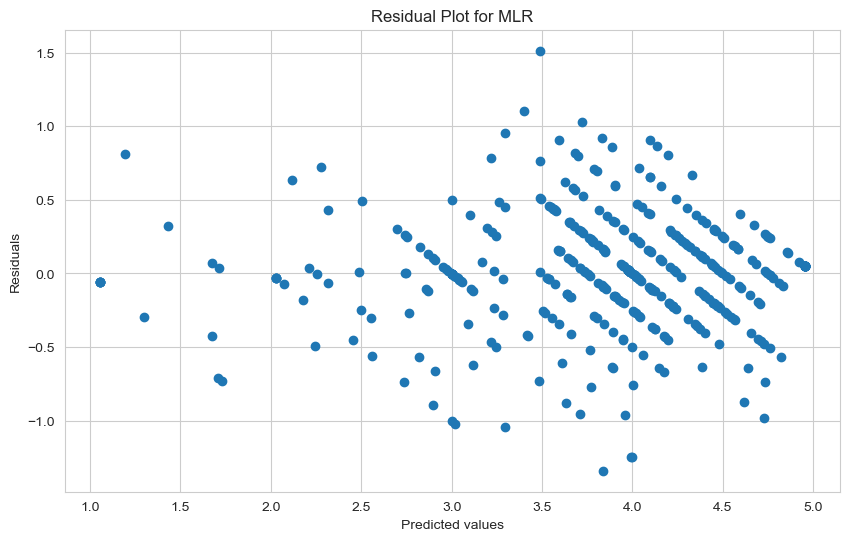

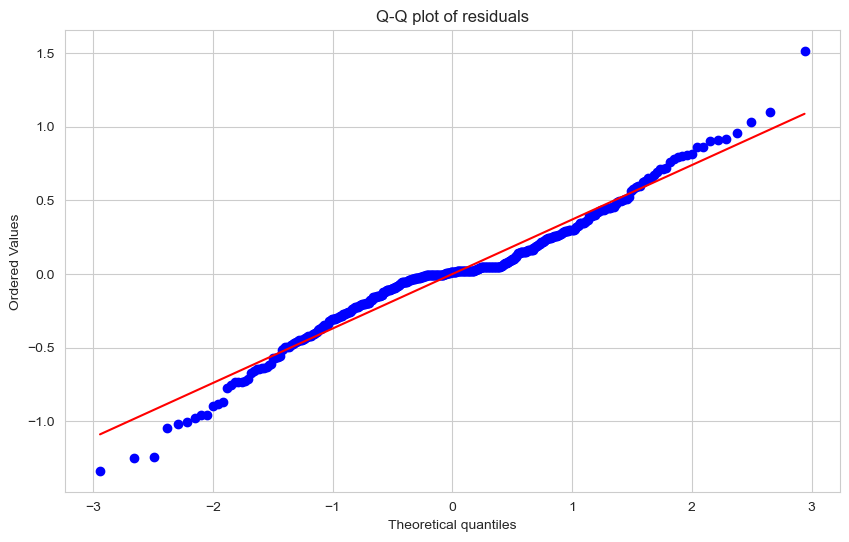

In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from scipy import stats

X = df[['PE', 'PU', 'PEOU','SEI', 'SOI', 'HM', 'AT', 'PPV']]
y = df['BI']


# Initialize models
models = {
    'MLR': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'RF': RandomForestRegressor(),
    'SVR': SVR(),
    'MLP': MLPRegressor()
}

# Perform cross-validation and collect results
results = []
for name, model in models.items():
    for metric in ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']:
        scores = cross_val_score(model, X, y, scoring=metric, cv=5)
        for score in scores:
            results.append({
                'Model': name,
                'Metric': metric.replace('neg_', ''),
                'Score': -score if 'neg_' in metric else score
            })

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Descriptive statistics
print("Descriptive Statistics:")
print(df_results.groupby(['Metric', 'Model'])['Score'].describe())

# Visualization
plt.figure(figsize=(15, 5))
for i, metric in enumerate(df_results['Metric'].unique()):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Model', y='Score', data=df_results[df_results['Metric'] == metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation analysis
pivot_results = df_results.pivot_table(values='Score', index='Model', columns='Metric')
correlation = pivot_results.corr()
print("\nCorrelation between metrics:")
print(correlation)

# Sensitivity analysis (example for RandomForest)
rf_model = RandomForestRegressor()
n_estimators = [10, 50, 100, 200]
max_depths = [None, 10, 20, 30]

sensitivity_results = []
for n in n_estimators:
    for d in max_depths:
        rf_model.set_params(n_estimators=n, max_depth=d)
        scores = cross_val_score(rf_model, X, y, cv=5)
        sensitivity_results.append({
            'n_estimators': n,
            'max_depth': d,
            'mean_score': np.mean(scores),
            'std_score': np.std(scores)
        })

df_sensitivity = pd.DataFrame(sensitivity_results)
print("\nSensitivity Analysis for Random Forest:")
print(df_sensitivity)

# Residual analysis (for MLR)
mlr = LinearRegression().fit(X, y)
y_pred = mlr.predict(X)
residuals = y - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot for MLR")
plt.show()

# Q-Q plot
fig, ax = plt.subplots(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot of residuals")
plt.show()

In [236]:
df_survey_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 424 entries, 0 to 522
Data columns (total 100 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     424 non-null    object 
 1   AR_Knowledgeable              424 non-null    float64
 2   familiar_with_technology      424 non-null    float64
 3   use_AR_everyday               424 non-null    float64
 4   use_in_all_aspects            424 non-null    object 
 5   Virtual_shopping_environment  424 non-null    float64
 6   Virtual_tour                  424 non-null    float64
 7   Visualize_model               424 non-null    float64
 8   Emulation                     424 non-null    float64
 9   PE1                           424 non-null    float64
 10  PE2                           424 non-null    float64
 11  PE3                           424 non-null    float64
 12  PE4                           424 non-null    float64
 13  SOI1     

In [298]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def prepare_data():

    # Define features for TAM and ML models
    tam_features = ['PU', 'PEOU','AT','HM','PE']
    ml_features = tam_features +  ['AGE_num', 'Gender_num', 'SOI', 'SEI']
    #ml_features = tam_features + ['additional_feature1', 'additional_feature2', ...]

    
    # Separate features and target
    X = df_survey_cleaned[ml_features]
    y = df_survey_cleaned['BI']  

    
    # Convert object columns to numeric where possible
    for col in X.columns:
        if X[col].dtype == 'object':
            X[col] = pd.to_numeric(X[col], errors='coerce')

    # Handle missing values (if any)
    X = X.fillna(X.mean())
    
    
    # Normalize numerical features
    scaler = StandardScaler()
    X[['AGE_num'] + tam_features + ml_features] = scaler.fit_transform(X[['AGE_num'] + tam_features + ml_features])

    print(X)
      # Encode categorical variables
   # X = pd.get_dummies(X, columns=['Gender_num', 'SOI', 'SEI'])
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    return X_train, X_test, y_train, y_test, tam_features, ml_features

 

In [299]:
def segment_users(data):
    segments = {
        'age_group': data['Age_num'],
        'gender': data['Gender_num'],
        'SOI': data['SEI'],
        'SEI': data['SEI']
    }
    return pd.DataFrame(segments)

In [300]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# TAM model (simplified linear regression)
tam_model = LinearRegression()

# Machine learning models
ml_models = {
    'MLR': LinearRegression(),
    'RF': RandomForestRegressor(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'MLP': MLPRegressor()
}

In [301]:
from sklearn.model_selection import cross_val_score

def evaluate_model(model, X, y, segments):
    overall_score = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    segment_scores = {}
    
    for column in segments.columns:
        for segment in segments[column].unique():
            mask = segments[column] == segment
            segment_score = cross_val_score(model, X[mask], y[mask], cv=5, scoring='r2').mean()
            segment_scores[f"{column}_{segment}"] = segment_score
    
    return overall_score, segment_scores

In [302]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 424 entries, 0 to 522
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PU                             424 non-null    float64
 1   PEOU                           424 non-null    float64
 2   AT                             424 non-null    float64
 3   HM                             424 non-null    float64
 4   PE                             424 non-null    float64
 5   AGE_num_-2.2677313665081105    424 non-null    bool   
 6   AGE_num_-1.1663360636450648    424 non-null    bool   
 7   AGE_num_-0.06494076078201932   424 non-null    bool   
 8   AGE_num_1.0364545420810263     424 non-null    bool   
 9   Gender_num_-1.512224092331013  424 non-null    bool   
 10  Gender_num_0.6612776539345785  424 non-null    bool   
 11  SOI_-3.0185644420812365        424 non-null    bool   
 12  SOI_-2.740512883653593         424 non-null    bool   


In [303]:
X_train, X_test, y_train, y_test, tam_feaatures, ml_features = prepare_data()  # Function to prepare your dataset
segments = segment_users(X)

tam_overall, tam_segments = evaluate_model(tam_model, X[tam_features], y, segments)

ml_results = {}
for name, model in ml_models.items():
    ml_overall, ml_segments = evaluate_model(model, X, y, segments)
    ml_results[name] = (ml_overall, ml_segments)

C:\Users\cemcd\AppData\Local\Temp\ipykernel_4948\3595828288.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = pd.to_numeric(X[col], errors='coerce')


           PU      PEOU        AT        HM        PE   AGE_num  Gender_num  \
0   -0.644268  0.329687 -0.189687  0.145711  0.215534  1.036455   -1.512224   
1   -0.927638 -0.753935 -0.948433 -0.970823 -0.834885 -1.166336    0.661278   
2    0.205845  0.329687  0.189687  0.145711  0.215534  1.036455   -1.512224   
3    0.205845  0.329687  0.189687  1.262245  0.740744 -1.166336   -1.512224   
4   -0.360897  0.329687  0.189687  0.145711 -0.834885 -1.166336   -1.512224   
..        ...       ...       ...       ...       ...       ...         ...   
419  1.055957  0.690894  1.327806  1.262245  0.740744  1.036455    0.661278   
420  0.489216  1.052101  0.569060  0.890067  0.478139  1.036455    0.661278   
421  0.772586 -0.031520  0.569060  0.890067  0.215534  1.036455    0.661278   
422  0.772586 -0.031520  0.569060  0.890067  0.215534  1.036455    0.661278   
522  0.489216 -0.031520  0.569060 -0.226467  0.478139 -1.166336   -1.512224   

          SOI       SEI  
0   -0.794152 -0.790840  

KeyError: 'Age_num'

In [282]:
import scipy.stats as stats

def compare_consistency(tam_scores, ml_scores):
    tam_variance = np.var(list(tam_scores.values()))
    ml_variance = np.var(list(ml_scores.values()))
    
    f_statistic = tam_variance / ml_variance
    p_value = stats.f.cdf(f_statistic, len(tam_scores) - 1, len(ml_scores) - 1)
    
    return f_statistic, p_value

In [6]:
To test the hypothesis comparing the predictive power of machine learning models versus TAM across different user groups, you would need to design an experiment in Python that incorporates demographic factors like age, gender, social identity, and self-identity. Here's an approach to set up and conduct such a test:

1. Data preparation:
   
   Ensure your dataset includes the following:
   - Features used in the TAM (e.g., perceived usefulness, perceived ease of use)
   - Additional features for machine learning models
   - Demographic information (age, gender, social identity, self-identity)
   - Target variable (e.g., technology acceptance or usage)

2. Define user segments:
   Create functions to segment users based on demographic factors. For example:

   ```python
   def segment_users(data):
       segments = {
           'age_group': pd.cut(data['age'], bins=[0, 25, 40, 60, 100], labels=['18-25', '26-40', '41-60', '60+']),
           'gender': data['gender'],
           'social_identity': data['social_identity'],
           'self_identity': data['self_identity']
       }
       return pd.DataFrame(segments)
   ```

3. Implement models:
   Set up both TAM and machine learning models:

   ```python
   from sklearn.linear_model import LinearRegression
   from sklearn.ensemble import RandomForestRegressor
   from sklearn.svm import SVR
   from sklearn.neighbors import KNeighborsRegressor
   from sklearn.neural_network import MLPRegressor

   # TAM model (simplified linear regression)
   tam_model = LinearRegression()

   # Machine learning models
   ml_models = {
       'MLR': LinearRegression(),
       'RF': RandomForestRegressor(),
       'SVR': SVR(),
       'KNN': KNeighborsRegressor(),
       'MLP': MLPRegressor()
   }
   ```

4. Evaluation function:
   Create a function to evaluate model performance across segments:

   ```python
   from sklearn.model_selection import cross_val_score

   def evaluate_model(model, X, y, segments):
       overall_score = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
       segment_scores = {}
       
       for column in segments.columns:
           for segment in segments[column].unique():
               mask = segments[column] == segment
               segment_score = cross_val_score(model, X[mask], y[mask], cv=5, scoring='r2').mean()
               segment_scores[f"{column}_{segment}"] = segment_score
       
       return overall_score, segment_scores
   ```

5. Conduct experiment:
   Run the evaluation for TAM and ML models:

   ```python
   X, y = prepare_data()  # Function to prepare your dataset
   segments = segment_users(X)

   tam_overall, tam_segments = evaluate_model(tam_model, X[tam_features], y, segments)

   ml_results = {}
   for name, model in ml_models.items():
       ml_overall, ml_segments = evaluate_model(model, X, y, segments)
       ml_results[name] = (ml_overall, ml_segments)
   ```

6. Statistical analysis:
   Compare the consistency of performance across segments:

   ```python
   import scipy.stats as stats

   def compare_consistency(tam_scores, ml_scores):
       tam_variance = np.var(list(tam_scores.values()))
       ml_variance = np.var(list(ml_scores.values()))
       
       f_statistic = tam_variance / ml_variance
       p_value = stats.f.cdf(f_statistic, len(tam_scores) - 1, len(ml_scores) - 1)
       
       return f_statistic, p_value
   ```

7. Interpret results:
   Analyze the overall performance and consistency across segments for each model. Lower variance in segment scores indicates more consistent performance.

   ```python
   for name, (ml_overall, ml_segments) in ml_results.items():
       f_stat, p_val = compare_consistency(tam_segments, ml_segments)
       print(f"{name} vs TAM consistency comparison:")
       print(f"F-statistic: {f_stat}, p-value: {p_val}")
   ```

This approach allows you to:
1. Compare overall performance of TAM vs ML models
2. Assess how each model performs across different demographic segments
3. Statistically compare the consistency of performance across segments

If the machine learning models show lower variance in performance across segments (lower F-statistic) and the p-value is significant, you would reject the null hypothesis, supporting the alternative hypothesis that ML models show more consistent predictive performance across diverse user segments compared to TAM[1][2][3].

Remember to ensure your data is properly preprocessed, handle any multicollinearity issues, and consider feature importance analysis to understand which demographic factors most influence prediction consistency[4][5].

Citations:
[1] https://365datascience.com/tutorials/python-tutorials/predictive-model-python/
[2] https://machinelearningmastery.com/metrics-evaluate-machine-learning-algorithms-python/
[3] https://www.nature.com/articles/s41599-024-02807-x
[4] https://www.activestate.com/blog/how-to-predict-nfl-winners-with-python/
[5] https://stackoverflow.com/questions/73511404/python-machine-learning-how-to-get-the-prediction-speed-of-a-model

SyntaxError: unterminated string literal (detected at line 1) (1809706918.py, line 1)

This approach allows you to:
Compare overall performance of TAM vs ML models
Assess how each model performs across different demographic segments
Statistically compare the consistency of performance across segments
If the machine learning models show lower variance in performance across segments (lower F-statistic) and the p-value is significant, you would reject the null hypothesis, supporting the alternative hypothesis that ML models show more consistent predictive performance across diverse user segments compared to TAM.
Remember to ensure your data is properly preprocessed, handle any multicollinearity issues, and consider feature importance analysis to understand which demographic factors most influence prediction consistency